## Berry–Childs Qubitization for Graph-Based Credit Risk Propagation
### (Oracle Construction, Sparse Hamiltonian Simulation, and Effective Quantum Walk Validation)

In [1]:
"""
Notebook goal:
--------------

Construct and rigorously validate the complete Berry–Childs
qubitization framework for the structured sparse linear
systems arising from the graph-based credit-risk propagation
models developed in this project.

The notebook considers the financial linear systems

    A x = b,

where A is one of the sparse Hermitian matrices derived
from the contagion models investigated throughout this
project, namely

    Model 1:
        A = (1-α)I + αL

or

    Model 2:
        A = I − αP_sym,

where

    L       is the graph Laplacian,

    P_sym   is the symmetric normalized
              adjacency matrix.

Rather than treating arbitrary sparse matrices, the
construction exploits the specific structure of these
financial models. Their known sparsity pattern, graph
interpretation, bounded matrix entries, and structured
right-hand-side vectors allow specialized sparse-access
oracles and state-preparation procedures to be developed
and validated throughout the notebook.

After scaling A so that

    ||A|| ≤ α_A,

the notebook constructs the Berry–Childs isometry

    T,

the corresponding reflection

    R = 2TT† − I,

the swap operator

    S,

and the Berry–Childs quantum walk

    W = SR.

Rather than constructing exponentially large unitary
operators explicitly, the notebook follows the scalable
algorithmic architecture employed by Berry–Childs sparse
Hamiltonian simulation:

    • structured sparse-access oracle construction,

    • Berry–Childs state preparation,

    • compiler-generated local unitary synthesis,

    • sliced unitary execution,

    • algorithmic reflection construction,

    • algorithmic quantum walk implementation.

The notebook develops and validates the following workflow:

1. Construction of the structured financial graph
2. Assembly and normalization of the sparse linear system
3. Construction of sparse-access row and value oracles
4. Preparation of the Berry–Childs state vectors
5. Construction of the Berry–Childs isometry T
6. Compiler synthesis of local unitary extensions
7. Algorithmic realization of the sliced unitary U_T
8. Construction and verification of

       R = U_T R0 U_T†

9. Construction and verification of

       W = SR

10. Construction of the genuine effective walk operator
11. Verification against the independent mathematical
    Berry–Childs construction
12. Spectral validation of the effective walk on the
    invariant subspace.

Throughout the notebook, every major mathematical identity
is independently verified using explicit statevector
evolution. These include

    • isometry properties,

    • compiler-generated unitary extensions,

    • reflection identities,

    • invariant-subspace preservation,

    • Berry–Childs walk identities,

    • effective-walk construction,

    • spectral equivalence.

The emphasis is on algorithmic correctness rather than
fault-tolerant gate optimization. Large unitary matrices
are never constructed except when independently verifying
small benchmark instances. Instead, the notebook develops
the oracle-based execution model that underlies scalable
Berry–Childs sparse Hamiltonian simulation.

The final product of this notebook is the genuine
Berry–Childs effective quantum walk operator obtained
directly from compiler-generated state evolution. This
validated effective walk serves as the input to Notebook B,
which implements quantum phase estimation, eigenvalue
transformations, and the complete HHL linear-system solver.

Consequently, successful completion of this notebook
provides strong evidence that the specialized oracle
architecture developed for these financial graph models
extends naturally to scalable Berry–Childs sparse
Hamiltonian simulation without requiring explicit
construction of exponentially large walk operators.
"""

# ============================================================
# Cell 1 : Imports and Initializations
# ============================================================

# -----------------------
# Qiskit
# -----------------------
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator

# -----------------------
# Numerical libraries
# -----------------------
import numpy as np
import scipy.linalg as la
import scipy.sparse as sp
import scipy.sparse.linalg as spla


# -----------------------
# Plotting
# -----------------------
import matplotlib.pyplot as plt

# -----------------------
# Miscellaneous
# -----------------------
import math as m
import warnings

warnings.filterwarnings('ignore')

# -----------------------
# Custom utility functions
# -----------------------
import Our_Qiskit_Functions as oq

# ============================================================
# Simulators
# ============================================================

state_sim = AerSimulator(method='statevector')
qasm_sim = AerSimulator()

# ============================================================
# Global NumPy settings
# ============================================================

np.set_printoptions(
    precision=4,
    suppress=True,
    linewidth=150
)

# ============================================================
# Random seed
# ============================================================

SEED = 42
rng = np.random.default_rng(SEED)

print("Imports successful.")
print(f"Random seed = {SEED}")

Imports successful.
Random seed = 42


In [2]:
# ============================================================
# Cell 2 : Master Configuration
# ============================================================

# -----------------------
# Problem size
# -----------------------

# Total number of nodes INCLUDING dummy nodes.
# Must be a power of 2.
N = 32

# Number of system qubits
n = int(np.log2(N))

assert 2**n == N, "N must be a power of 2."

# -----------------------
# Shock vector sparsity
# -----------------------

# gamma = 2^{ floor(log2( SHOCK_SPARSITY_FACTOR * log2(N) )) }

SHOCK_SPARSITY_FACTOR = 2

assert SHOCK_SPARSITY_FACTOR > 0, \
    "SHOCK_SPARSITY_FACTOR must be positive."

gamma = 2 ** int(
    np.floor(
        np.log2(
            SHOCK_SPARSITY_FACTOR * np.log2(N)
        )
    )
)

# gamma/2 dummy nodes are required
assert gamma % 2 == 0, "gamma must be even."

N_dummy = gamma // 2
N_real = N - N_dummy

assert N_real > 0, \
    "Number of real nodes must be positive."

# -----------------------
# Sparsity specification
# -----------------------

# Sparsity of J
#
# Every real node has exactly s_J neighbours.
#
# Since A = (1-alpha)I + alpha L,
# the diagonal contributes one additional nonzero,
# so
#
#     s = s_J + 1
#
s_J = 3

assert s_J >= 2, \
    "s_J must be at least 2."

# Sparsity of A
s = s_J + 1

# -----------------------
# Edge-weight specification
# -----------------------

# Minimum positive edge weight
J_min = 0.5

assert J_min > 0, \
    "J_min must be strictly positive."

# Ensure 1/J_min is an integer
assert np.isclose(
    1 / J_min,
    round(1 / J_min)
), "1/J_min must be an integer."

# All positive edge weights will be integer multiples of J_min:
#
#     J_ij = k_ij * J_min
#
# where
#
#     k_ij = 1, 2, 3, ...
#

# -----------------------
# Diffusion parameter
# -----------------------

alpha = 0.5

assert 0 < alpha < 1, \
    "alpha must lie strictly between 0 and 1."



# ============================================================
# Precision-design thresholds
# ============================================================

#
# These thresholds define the smallest meaningful
# values that the oracle value register must be
# capable of resolving.
#
# They are NOT the actual values used in the
# particular instance.
#
# Instead, they define the class of matrices
# that this notebook is designed to handle.
#

#ALPHA_THRESHOLD = 1e-2
#J_MIN_THRESHOLD = 1e-2

ALPHA_THRESHOLD = 5e-2
J_MIN_THRESHOLD = 25e-2


# -----------------------
# Model choice
# -----------------------

# 1 :
# A = (1-alpha)I + alpha(D - J)
#
# 2 :
# A = (1-alpha)I + alpha(I - D^{-1/2} J D^{-1/2})
#

#model = 1
model = 2

assert model in [1, 2], \
    "model must be either 1 or 2."

# -----------------------
# Real-network graph type
# -----------------------

# Allowed values:
#
# "nearest"
# "random_regular"
# "irregular"
#

#graph_type = "nearest"
#graph_type = "random_regular"
graph_type = "irregular"

assert graph_type in [
    "nearest",
    "random_regular",
    "irregular"
], "Invalid graph type."

# ============================================================
# Configuration summary
# ============================================================

print("=" * 65)
print("Master Configuration")
print("=" * 65)

print(f"Total nodes N                           : {N}")
print(f"System qubits n = log2(N)               : {n}")

print()

print(f"Shock sparsity factor                   : {SHOCK_SPARSITY_FACTOR}")
print(f"Shock sparsity gamma                    : {gamma}")
print(f"Dummy nodes (gamma/2)                   : {N_dummy}")
print(f"Real nodes                              : {N_real}")

print()

print(f"Sparsity of J (s_J)                     : {s_J}")
print(f"Sparsity of A (s = s_J + 1)             : {s}")

print()

print(f"Minimum edge weight J_min               : {J_min}")
print(f"1 / J_min                               : {int(round(1/J_min))}")

print("Positive edge weights are multiples of J_min")

print()

print(f"Diffusion parameter alpha               : {alpha}")
print(f"Model                                   : {model}")
print(f"Graph type                              : {graph_type}")

print("=" * 65)

Master Configuration
Total nodes N                           : 32
System qubits n = log2(N)               : 5

Shock sparsity factor                   : 2
Shock sparsity gamma                    : 8
Dummy nodes (gamma/2)                   : 4
Real nodes                              : 28

Sparsity of J (s_J)                     : 3
Sparsity of A (s = s_J + 1)             : 4

Minimum edge weight J_min               : 0.5
1 / J_min                               : 2
Positive edge weights are multiples of J_min

Diffusion parameter alpha               : 0.5
Model                                   : 2
Graph type                              : irregular


In [3]:
# ============================================================
# Cell 3 : Node Partitions and Index Sets
# ============================================================

# ------------------------------------------------------------
# Real bank nodes
# ------------------------------------------------------------

real_nodes = np.arange(N_real)

# ------------------------------------------------------------
# Dummy nodes
# ------------------------------------------------------------

dummy_nodes = np.arange(N_real, N)

# ------------------------------------------------------------
# Useful sets (for O(1) membership tests)
# ------------------------------------------------------------

real_node_set = set(real_nodes)
dummy_node_set = set(dummy_nodes)

# ------------------------------------------------------------
# Consistency checks
# ------------------------------------------------------------

assert len(real_nodes) == N_real
assert len(dummy_nodes) == N_dummy

assert real_node_set.isdisjoint(dummy_node_set)

assert len(real_node_set.union(dummy_node_set)) == N

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("=" * 65)
print("Node Partition Summary")
print("=" * 65)

print(f"Total nodes (N)              : {N}")
print(f"Real nodes                   : {N_real}")
print(f"Dummy nodes                  : {N_dummy}")

print()

print(f"Real node indices            : "
      f"{real_nodes[0]} ... {real_nodes[-1]}")

if N_dummy > 0:
    print(f"Dummy node indices           : "
          f"{dummy_nodes[0]} ... {dummy_nodes[-1]}")
else:
    print("Dummy node indices           : None")

print()

print(f"Real node set size           : {len(real_node_set)}")
print(f"Dummy node set size          : {len(dummy_node_set)}")

print("=" * 65)

Node Partition Summary
Total nodes (N)              : 32
Real nodes                   : 28
Dummy nodes                  : 4

Real node indices            : 0 ... 27
Dummy node indices           : 28 ... 31

Real node set size           : 28
Dummy node set size          : 4


J_real Construction Summary
Graph type                          : irregular
Number of real nodes                : 28

Specified s_J                       : 3
Specified sparsity of A (s)         : 4

Minimum actual row sparsity         : 1
Maximum actual row sparsity         : 3

Minimum weighted degree d_min       : 0.5000
Maximum weighted degree d_max       : 3.0000

Number of undirected edges          : 26
Number of non-zero entries          : 52

Minimum positive J_ij               : 0.5000
Maximum positive J_ij               : 1.0000

First few rows of J_real:

Row 0:
    J[0,12] = 1.0
    J[0,21] = 1.0

Row 1:
    J[1,13] = 1.0
    J[1,25] = 0.5

Row 2:
    J[2,4] = 1.0
    J[2,26] = 0.5

Row 3:
    J[3,9] = 0.5
    J[3,20] = 0.5

Row 4:
    J[4,2] = 1.0

Row 5:
    J[5,10] = 0.5
    J[5,24] = 1.0

Row 6:
    J[6,20] = 0.5

Row 7:
    J[7,16] = 0.5

Row 8:
    J[8,13] = 0.5
    J[8,25] = 0.5

Row 9:
    J[9,3] = 0.5
    J[9,20] = 0.5


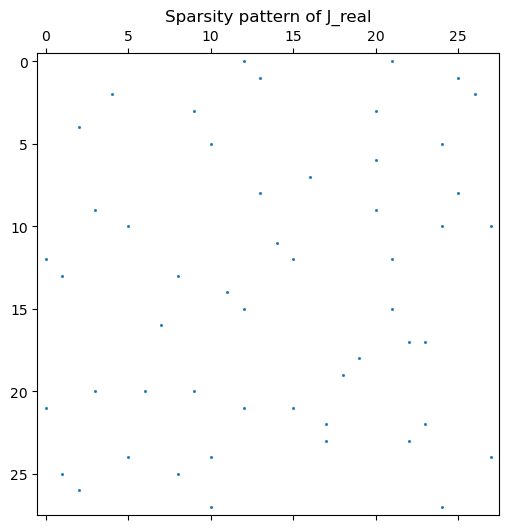

In [4]:
# ============================================================
# Cell 4 : Construct J_real
# ============================================================

# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------

def generate_weight(J_min, rng):
    """
    Generate a positive edge weight that is an integer
    multiple of J_min and at most 1.

    Returns a value in

        {J_min, 2 J_min, ..., 1}
    """

    max_multiple = int(round(1 / J_min))

    multiplier = rng.integers(1, max_multiple + 1)

    return multiplier * J_min


# ------------------------------------------------------------
# Nearest-neighbour graph
# ------------------------------------------------------------

def generate_nearest_J(N_nodes,
                       J_min):
    """
    Construct a single cycle:

        0 -> 1 -> 2 -> ... -> N-1 -> 0

    All edge weights are J_min.

    Intended primarily for debugging and the case s_J = 2.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    for i in range(N_nodes):

        j = (i + 1) % N_nodes

        J[i, j] = J_min
        J[j, i] = J_min

    return J.tocsr()


# ------------------------------------------------------------
# Random "almost regular" graph
# ------------------------------------------------------------

def generate_random_regular_J(N_nodes,
                              s_J,
                              J_min,
                              rng):
    """
    Randomly partition the nodes.

    Groups of size (s_J + 1):
        Construct complete graphs K_{s_J+1}
        with edge weights J_min.

    Remainder group:
        Construct a simple cycle.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    nodes = rng.permutation(N_nodes)

    group_size = s_J + 1

    n_full_groups = N_nodes // group_size

    remainder = N_nodes % group_size

    # --------------------------------------------------------
    # Full groups
    # --------------------------------------------------------

    start = 0

    for _ in range(n_full_groups):

        group = nodes[start:start + group_size]

        start += group_size

        # Complete graph
        for i in range(len(group)):

            for j in range(i + 1,
                           len(group)):

                u = group[i]
                v = group[j]

                J[u, v] = J_min
                J[v, u] = J_min

    # --------------------------------------------------------
    # Remainder group
    # --------------------------------------------------------

    if remainder >= 2:

        group = nodes[start:]

        for i in range(len(group)):

            u = group[i]

            v = group[(i + 1) % len(group)]

            J[u, v] = J_min
            J[v, u] = J_min

    elif remainder == 1:

        print(
            "Warning: One node in the remainder "
            "group has no real-network connections."
        )

    return J.tocsr()


# ------------------------------------------------------------
# Irregular graph
# ------------------------------------------------------------

def generate_irregular_J(N_nodes,
                         s_J,
                         J_min,
                         rng):
    """
    Construct a general irregular graph.

    Procedure:
    1. Partition the nodes into groups whose sizes
       are random integers between 2 and s_J + 1.
    2. Within each group, consider all pairings.
    3. Assign each pairing a weight chosen from

            {0, J_min, 2J_min, ..., 1}

    4. Repair isolated nodes by assigning one
       incident edge weight J_min.

    Guarantees:
        - symmetric,
        - zero diagonal,
        - J_ij >= J_min whenever J_ij > 0,
        - d_i >= J_min for every node.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    nodes = list(rng.permutation(N_nodes))

    groups = []

    # --------------------------------------------------------
    # Create random groups
    # --------------------------------------------------------

    while len(nodes) > 0:

        remaining = len(nodes)

        if remaining <= s_J + 1:

            group_size = remaining

        else:

            group_size = rng.integers(
                2,
                s_J + 2
            )

        group = nodes[:group_size]

        groups.append(group)

        nodes = nodes[group_size:]

    # --------------------------------------------------------
    # Populate each group
    # --------------------------------------------------------

    max_multiple = int(round(1 / J_min))

    for group in groups:

        m = len(group)

        if m == 1:
            continue

        # --------------------------------------------
        # Random pairings
        # --------------------------------------------

        for i in range(m):

            for j in range(i + 1,
                           m):

                u = group[i]
                v = group[j]

                multiplier = rng.integers(
                    0,
                    max_multiple + 1
                )

                weight = multiplier * J_min

                if weight > 0:

                    J[u, v] = weight
                    J[v, u] = weight

        # --------------------------------------------
        # Repair isolated nodes
        # --------------------------------------------

        for u in group:

            degree = J[u, :].sum()

            if degree == 0:

                candidates = [
                    v for v in group
                    if v != u
                ]

                if len(candidates) > 0:

                    v = rng.choice(candidates)

                    J[u, v] = J_min
                    J[v, u] = J_min

    return J.tocsr()


# ============================================================
# Construct J_real
# ============================================================

if graph_type == "nearest":

    J_real = generate_nearest_J(
        N_real,
        J_min
    )

elif graph_type == "random_regular":

    J_real = generate_random_regular_J(
        N_real,
        s_J,
        J_min,
        rng
    )

elif graph_type == "irregular":

    J_real = generate_irregular_J(
        N_real,
        s_J,
        J_min,
        rng
    )

else:

    raise ValueError(
        f"Unknown graph type: {graph_type}"
    )


# ============================================================
# Diagnostics
# ============================================================

row_sparsities = np.diff(J_real.indptr)

weighted_degrees = np.array(
    J_real.sum(axis=1)
).flatten()

positive_entries = J_real.data


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (J_real != J_real.T).nnz == 0, \
    "J_real is not symmetric."

assert np.allclose(
    J_real.diagonal(),
    0
), "J_real has non-zero diagonal entries."

assert np.all(
    weighted_degrees > 0
), "Some nodes have zero weighted degree."

assert np.all(
    positive_entries >= J_min
), "Some positive entries are smaller than J_min."

assert np.allclose(
    positive_entries / J_min,
    np.round(
        positive_entries / J_min
    )
), "Entries are not multiples of J_min."

assert np.all(
    row_sparsities <= s_J
), (
    "Actual sparsity exceeds specified s_J."
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("J_real Construction Summary")
print("=" * 70)

print(f"Graph type                          : "
      f"{graph_type}")

print(f"Number of real nodes                : "
      f"{N_real}")

print()

print(f"Specified s_J                       : "
      f"{s_J}")

print(f"Specified sparsity of A (s)         : "
      f"{s}")

print()

print(f"Minimum actual row sparsity         : "
      f"{row_sparsities.min()}")

print(f"Maximum actual row sparsity         : "
      f"{row_sparsities.max()}")

print()

print(f"Minimum weighted degree d_min       : "
      f"{weighted_degrees.min():.4f}")

print(f"Maximum weighted degree d_max       : "
      f"{weighted_degrees.max():.4f}")

print()

print(f"Number of undirected edges          : "
      f"{J_real.nnz // 2}")

print(f"Number of non-zero entries          : "
      f"{J_real.nnz}")

print()

print(f"Minimum positive J_ij               : "
      f"{positive_entries.min():.4f}")

print(f"Maximum positive J_ij               : "
      f"{positive_entries.max():.4f}")

print("=" * 70)

# ============================================================
# First few rows of J_real
# ============================================================

n_rows_to_show = 10

print("\nFirst few rows of J_real:")

for i in range(n_rows_to_show):

    row = J_real.getrow(i)

    print(f"\nRow {i}:")

    for j, val in zip(row.indices, row.data):

        print(f"    J[{i},{j}] = {val}")


plt.figure(figsize=(6,6))
plt.spy(J_real, markersize=1)
plt.title("Sparsity pattern of J_real")
plt.show()

J_dummy Construction Summary
Number of dummy nodes              : 4

Dummy node indices                 : [28 29 30 31]

Number of undirected dummy edges   : 4
Number of non-zero dummy entries   : 8

Dummy row sparsity                 : 2
Dummy weighted degree              : 1.0000

Dummy edge weight                  : 0.5

First few rows of dummy_subgraph in J_dummy:

Global node 28:
    J[28,29] = 0.5
    J[28,31] = 0.5

Global node 29:
    J[29,28] = 0.5
    J[29,30] = 0.5

Global node 30:
    J[30,29] = 0.5
    J[30,31] = 0.5

Global node 31:
    J[31,28] = 0.5
    J[31,30] = 0.5


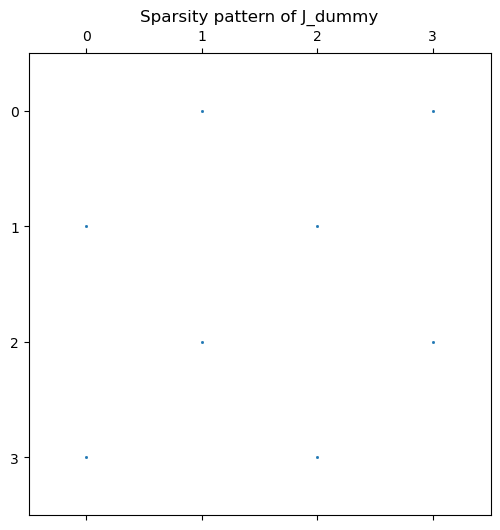

In [5]:
# ============================================================
# Cell 5 : Construct J_dummy
# ============================================================

J_dummy = sp.lil_matrix((N, N), dtype=float)

# ------------------------------------------------------------
# Construct the dummy cycle
# ------------------------------------------------------------

if N_dummy >= 2:

    for idx in range(N_dummy):

        u = dummy_nodes[idx]

        v = dummy_nodes[(idx + 1) % N_dummy]

        J_dummy[u, v] = J_min
        J_dummy[v, u] = J_min

elif N_dummy == 1:

    print(
        "Warning: Only one dummy node exists. "
        "No dummy edges created."
    )

else:

    print(
        "No dummy nodes specified."
    )

J_dummy = J_dummy.tocsr()


# ============================================================
# Diagnostics
# ============================================================

dummy_subgraph = J_dummy[dummy_nodes, :][:, dummy_nodes]

row_sparsities = np.diff(dummy_subgraph.indptr)

weighted_degrees = np.array(
    dummy_subgraph.sum(axis=1)
).flatten()

positive_entries = dummy_subgraph.data


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (J_dummy != J_dummy.T).nnz == 0, \
    "J_dummy is not symmetric."

assert np.allclose(
    J_dummy.diagonal(),
    0
), "J_dummy has non-zero diagonal entries."

# Ensure there are no real-dummy connections
assert J_dummy[real_nodes, :][:, dummy_nodes].nnz == 0, \
    "Real-to-dummy connections found."

assert J_dummy[dummy_nodes, :][:, real_nodes].nnz == 0, \
    "Dummy-to-real connections found."

if N_dummy >= 3:

    assert np.all(
        row_sparsities == 2
    ), "Dummy cycle does not have sparsity 2."

    assert np.allclose(
        weighted_degrees,
        2 * J_min
    ), (
        "Dummy weighted degrees are not equal "
        "to 2*J_min."
    )

if positive_entries.size > 0:

    assert np.allclose(
        positive_entries,
        J_min
    ), "Dummy edge weights are not equal to J_min."


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("J_dummy Construction Summary")
print("=" * 70)

print(f"Number of dummy nodes              : "
      f"{N_dummy}")

print()

print(f"Dummy node indices                 : "
      f"{dummy_nodes}")

print()

print(f"Number of undirected dummy edges   : "
      f"{dummy_subgraph.nnz // 2}")

print(f"Number of non-zero dummy entries   : "
      f"{dummy_subgraph.nnz}")

print()

if N_dummy >= 3:

    print(f"Dummy row sparsity                 : "
          f"{row_sparsities[0]}")

    print(f"Dummy weighted degree              : "
          f"{weighted_degrees[0]:.4f}")

print()

print(f"Dummy edge weight                  : "
      f"{J_min}")

print("=" * 70)

# ============================================================
# First few rows of J_dummy
# ============================================================

n_rows_to_show = min(dummy_subgraph.shape[0], 10)

print("\nFirst few rows of dummy_subgraph in J_dummy:")

for local_i in range(n_rows_to_show):

    global_i = dummy_nodes[local_i]

    row = dummy_subgraph.getrow(local_i)

    print(f"\nGlobal node {global_i}:")

    for local_j, val in zip(row.indices, row.data):

        global_j = dummy_nodes[local_j]

        print(
            f"    J[{global_i},{global_j}] = {val}"
        )


plt.figure(figsize=(6,6))
plt.spy(dummy_subgraph, markersize=1)
plt.title("Sparsity pattern of J_dummy")
plt.show()

Full Adjacency Matrix J Summary
Shape of J                          : (32, 32)

Number of real nodes                : 28
Number of dummy nodes               : 4

Specified s_J                       : 3
Maximum actual row sparsity         : 3

d_min                               : 0.5000
d_max                               : 3.0000

Specified J_min                     : 0.5000
Actual minimum positive J_ij        : 0.5000
Actual maximum positive J_ij        : 1.0000

Number of undirected edges          : 30
Number of non-zero entries          : 60

Number of connected components      : 10
Smallest component size             : 2
Largest component size              : 4

First few rows of J:

Row 0:
    J[0,12] = 1.0
    J[0,21] = 1.0

Row 1:
    J[1,13] = 1.0
    J[1,25] = 0.5

Row 2:
    J[2,4] = 1.0
    J[2,26] = 0.5

Row 3:
    J[3,9] = 0.5
    J[3,20] = 0.5

Row 4:
    J[4,2] = 1.0

Row 5:
    J[5,10] = 0.5
    J[5,24] = 1.0

Row 6:
    J[6,20] = 0.5

Row 7:
    J[7,16] = 0.5

Row 8:
 

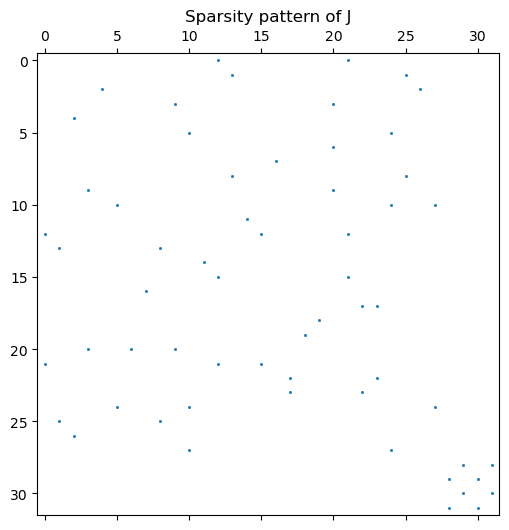

In [6]:
# ============================================================
# Cell 6 : Construct the full adjacency matrix J
# ============================================================

# ------------------------------------------------------------
# Embed J_real into an N x N matrix
# ------------------------------------------------------------

J_real_full = sp.lil_matrix((N, N), dtype=float)

J_real_full[:N_real, :N_real] = J_real

J_real_full = J_real_full.tocsr()

# ------------------------------------------------------------
# Assemble the full J matrix
# ------------------------------------------------------------

J = J_real_full + J_dummy

J = J.tocsr()

# ============================================================
# Diagnostics
# ============================================================

# ------------------------------------------------------------
# Basic structural properties
# ------------------------------------------------------------

assert J.shape == (N, N), \
    "J does not have shape (N, N)."

assert (J != J.T).nnz == 0, \
    "J is not symmetric."

assert np.allclose(
    J.diagonal(),
    0
), "J has non-zero diagonal entries."

# ------------------------------------------------------------
# Verify that real and dummy sectors are disconnected
# ------------------------------------------------------------

assert J[real_nodes, :][:, dummy_nodes].nnz == 0, \
    "Real-to-dummy connections detected."

assert J[dummy_nodes, :][:, real_nodes].nnz == 0, \
    "Dummy-to-real connections detected."

# ------------------------------------------------------------
# Sparsity diagnostics
# ------------------------------------------------------------

row_sparsities = np.diff(J.indptr)

max_row_sparsity = row_sparsities.max()

# ------------------------------------------------------------
# Weighted degree diagnostics
# ------------------------------------------------------------

weighted_degrees = np.array(
    J.sum(axis=1)
).flatten()

d_min = weighted_degrees.min()

d_max = weighted_degrees.max()

assert np.all(
    weighted_degrees > 0
), "Some nodes have zero weighted degree."

assert d_min >= J_min - 1e-12, \
    "d_min is smaller than J_min."

# ------------------------------------------------------------
# Edge-weight diagnostics
# ------------------------------------------------------------

positive_entries = J.data

assert np.all(
    positive_entries >= J_min
), "Some positive entries are smaller than J_min."

assert np.allclose(
    positive_entries / J_min,
    np.round(
        positive_entries / J_min
    )
), "Some edge weights are not multiples of J_min."

J_ij_min_actual = positive_entries.min()

J_ij_max_actual = positive_entries.max()

# ------------------------------------------------------------
# Connected component diagnostics
# ------------------------------------------------------------

n_components, component_labels = sp.csgraph.connected_components(
    J,
    directed=False
)

component_sizes = np.bincount(component_labels)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Full Adjacency Matrix J Summary")
print("=" * 70)

print(f"Shape of J                          : "
      f"{J.shape}")

print()

print(f"Number of real nodes                : "
      f"{N_real}")

print(f"Number of dummy nodes               : "
      f"{N_dummy}")

print()

print(f"Specified s_J                       : "
      f"{s_J}")

print(f"Maximum actual row sparsity         : "
      f"{max_row_sparsity}")

print()

print(f"d_min                               : "
      f"{d_min:.4f}")

print(f"d_max                               : "
      f"{d_max:.4f}")

print()

print(f"Specified J_min                     : "
      f"{J_min:.4f}")

print(f"Actual minimum positive J_ij        : "
      f"{J_ij_min_actual:.4f}")

print(f"Actual maximum positive J_ij        : "
      f"{J_ij_max_actual:.4f}")

print()

print(f"Number of undirected edges          : "
      f"{J.nnz // 2}")

print(f"Number of non-zero entries          : "
      f"{J.nnz}")

print()

print(f"Number of connected components      : "
      f"{n_components}")

print(f"Smallest component size             : "
      f"{component_sizes.min()}")

print(f"Largest component size              : "
      f"{component_sizes.max()}")

print("=" * 70)

# ============================================================
# First few rows of J
# ============================================================

n_rows_to_show = 10

print("\nFirst few rows of J:")

for i in range(n_rows_to_show):

    row = J.getrow(i)

    print(f"\nRow {i}:")

    for j, val in zip(row.indices, row.data):

        print(f"    J[{i},{j}] = {val}")


plt.figure(figsize=(6,6))
plt.spy(J, markersize=1)
plt.title("Sparsity pattern of J")
plt.show()

In [7]:
# ============================================================
# Cell 7 : Construct D, L, and A
# ============================================================

# ------------------------------------------------------------
# Degree vector and degree matrix
# ------------------------------------------------------------

degree_vector = np.array(
    J.sum(axis=1)
).flatten()

D = sp.diags(
    degree_vector,
    offsets=0,
    shape=(N, N),
    format='csr'
)

# ============================================================
# Construct the Laplacian
# ============================================================

if model == 1:

    # --------------------------------------------------------
    # Model 1:
    #
    #     L = D - J
    #
    # --------------------------------------------------------

    L = D - J

elif model == 2:

    # --------------------------------------------------------
    # Model 2:
    #
    #     L = I - D^{-1/2} J D^{-1/2}
    #
    # --------------------------------------------------------

    D_inv_sqrt = sp.diags(
        1 / np.sqrt(degree_vector),
        offsets=0,
        shape=(N, N),
        format='csr'
    )

    L = (
        sp.eye(N, format='csr')
        - D_inv_sqrt @ J @ D_inv_sqrt
    )

else:

    raise ValueError(
        f"Unknown model: {model}"
    )

# ============================================================
# Construct A
# ============================================================

A = (
    (1 - alpha) * sp.eye(N, format='csr')
    + alpha * L
)

A_DENSE = A.toarray()

A = A.tocsr()

# ============================================================
# Diagnostics
# ============================================================

A_row_sparsities = np.diff(A.indptr)

A_diagonal = A.diagonal()

off_diagonal = A - sp.diags(
    A_diagonal,
    format='csr'
)

positive_off_diagonal_entries = (
    off_diagonal.data[
        off_diagonal.data > 1e-12
    ]
)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (A != A.T).nnz == 0, \
    "A is not symmetric."

assert np.all(
    A_diagonal > 0
), "A does not have positive diagonal entries."

assert len(
    positive_off_diagonal_entries
) == 0, (
    "A has positive off-diagonal entries "
    "and is therefore not a Z-matrix."
)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Matrix Construction Summary")
print("=" * 70)

print(f"Model used                          : "
      f"{model}")

print()

print(f"Diffusion parameter alpha           : "
      f"{alpha:.4f}")

print()

print(f"Minimum degree d_min                : "
      f"{degree_vector.min():.4f}")

print(f"Maximum degree d_max                : "
      f"{degree_vector.max():.4f}")

print()

print(f"Maximum row sparsity of A           : "
      f"{A_row_sparsities.max()}")

print()

print(f"Minimum diagonal entry of A         : "
      f"{A_diagonal.min():.4f}")

print(f"Maximum diagonal entry of A         : "
      f"{A_diagonal.max():.4f}")

print()

print(f"Number of non-zero entries in A     : "
      f"{A.nnz}")

print()

print(f"A is symmetric                      : True")

print(f"A is a Z-matrix                     : True")

print("=" * 70)

Matrix Construction Summary
Model used                          : 2

Diffusion parameter alpha           : 0.5000

Minimum degree d_min                : 0.5000
Maximum degree d_max                : 3.0000

Maximum row sparsity of A           : 4

Minimum diagonal entry of A         : 1.0000
Maximum diagonal entry of A         : 1.0000

Number of non-zero entries in A     : 92

A is symmetric                      : True
A is a Z-matrix                     : True


In [8]:
# ============================================================
# Cell 8 : Spectral Diagnostics for A
# ============================================================

BLOCK_ENCODING_MARGIN = 1e-10

BOUND_VALIDATION_TOL = 1e-12
# (Used only when comparing exact theoretical bounds with numerically computed eigenvalues.)


# ------------------------------------------------------------
# Compute extremal eigenvalues
# ------------------------------------------------------------

print("Computing extremal eigenvalues of A...")

lambda_min = spla.eigsh(
    A,
    k=1,
    which='SA',
    return_eigenvectors=False
)[0]

lambda_max = spla.eigsh(
    A,
    k=1,
    which='LA',
    return_eigenvectors=False
)[0]

# ------------------------------------------------------------
# Exact condition number
# ------------------------------------------------------------

kappa_exact = lambda_max / lambda_min


# ============================================================
# Model-specific theoretical bounds
# ============================================================

if model == 1:

    #
    # A = (1-alpha)I + alpha(D - J)
    #
    # lambda_min >= 1 - alpha
    #
    # lambda_max <= (1-alpha) + 2 alpha d_max
    #

    lambda_min_bound = 1 - alpha

    lambda_max_bound = (
        (1 - alpha)
        + 2 * alpha * d_max
    )

    row_sum_bound = 2*(s - 1)

elif model == 2:

    #
    # A = (1-alpha)I
    #   + alpha(I - D^{-1/2} J D^{-1/2})
    #
    # spectrum(A) subseteq [1-alpha, 1+alpha]
    #

    lambda_min_bound = 1 - alpha

    lambda_max_bound = 1 + alpha

    row_sum_bound = s

else:

    raise ValueError(
        f"Unknown model: {model}"
    )


# ------------------------------------------------------------
# Theoretical condition number bound
# ------------------------------------------------------------

kappa_bound = (
    lambda_max_bound
    / lambda_min_bound
)


# ============================================================
# Positive definiteness diagnostics
# ============================================================

is_positive_definite = (
    lambda_min > 0
)

assert is_positive_definite, \
    (
        "A is not positive definite.\n"
        f"lambda_min = {lambda_min:.12f}"
    )


# ============================================================
# Validate theoretical bounds
# ============================================================

lower_bound_valid = (
    lambda_min >=
    lambda_min_bound - BOUND_VALIDATION_TOL
)

upper_bound_valid = (
    lambda_max <=
    lambda_max_bound + BOUND_VALIDATION_TOL
)

assert lower_bound_valid, \
    (
        "Theoretical lower bound violated.\n"
        f"lambda_min = {lambda_min:.12f}\n"
        f"lambda_min_bound = "
        f"{lambda_min_bound:.12f}"
    )

assert upper_bound_valid, \
    (
        "Theoretical upper bound violated.\n"
        f"lambda_max = {lambda_max:.12f}\n"
        f"lambda_max_bound = "
        f"{lambda_max_bound:.12f}"
    )


# ============================================================
# Block-encoding scaling factor
# ============================================================

# Note that alpha_A must ensure two things.
#
# 1. ||A / alpha_A||_2 <= 1,
#    so that the matrix is block-encodable.
#
# 2. For every row i,
#
#       sum_j |A_ij| / alpha_A <= 1,
#
#    so that the PREPARE amplitudes
#
#       sqrt(|A_ij| / alpha_A)
#
#    form a valid subnormalized state.
#    The remaining probability mass is assigned
#    to the |fail> state.

alpha_A = (
    max(
        lambda_max_bound,
        row_sum_bound
    )
    /
    (1 - BLOCK_ENCODING_MARGIN)
)

# ============================================================
# Encodability diagnostics
# ============================================================

scaled_lambda_min = (
    lambda_min / alpha_A
)

scaled_lambda_max = (
    lambda_max / alpha_A
)

all_eigenvalues_encodable = (
    scaled_lambda_max <= 1
)

assert all_eigenvalues_encodable, \
    (
        "Eigenvalues are not block-encodable.\n"
        f"lambda_max / alpha_A = "
        f"{scaled_lambda_max:.12f}"
    )

assert scaled_lambda_min > 0, \
    (
        "Scaled eigenvalues are not positive.\n"
        f"lambda_min / alpha_A = "
        f"{scaled_lambda_min:.12f}"
    )


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Spectral Diagnostics")
print("=" * 70)

print(f"Exact lambda_min                   : "
      f"{lambda_min:.8f}")

print(f"Exact lambda_max                   : "
      f"{lambda_max:.8f}")

print()

print(f"Exact condition number             : "
      f"{kappa_exact:.8f}")

print()

print(f"Theoretical lambda_min bound       : "
      f"{lambda_min_bound:.8f}")

print(f"Theoretical lambda_max bound       : "
      f"{lambda_max_bound:.8f}")

print()

print(f"Theoretical condition number bound : "
      f"{kappa_bound:.8f}")

print()

print(f"Row-sum bound                      : "
      f"{row_sum_bound:.8f}")

print()

print(f"Block-encoding margin              : "
      f"{BLOCK_ENCODING_MARGIN:.2e}")

print(f"Block-encoding scaling alpha_A     : "
      f"{alpha_A:.8f}")

print()

print(f"lambda_min / alpha_A               : "
      f"{scaled_lambda_min:.8f}")

print(f"lambda_max / alpha_A               : "
      f"{scaled_lambda_max:.8f}")

print(f"alpha_A / lambda_max               : "
      f"{alpha_A / lambda_max:.8f}")

print()

print(f"A is positive definite             : "
      f"{is_positive_definite}")

print(f"Lower bound validated              : "
      f"{lower_bound_valid}")

print(f"Upper bound validated              : "
      f"{upper_bound_valid}")

print(f"All eigenvalues encodable          : "
      f"{all_eigenvalues_encodable}")

print("=" * 70)

Computing extremal eigenvalues of A...

Spectral Diagnostics
Exact lambda_min                   : 0.50000000
Exact lambda_max                   : 1.50000000

Exact condition number             : 3.00000000

Theoretical lambda_min bound       : 0.50000000
Theoretical lambda_max bound       : 1.50000000

Theoretical condition number bound : 3.00000000

Row-sum bound                      : 4.00000000

Block-encoding margin              : 1.00e-10
Block-encoding scaling alpha_A     : 4.00000000

lambda_min / alpha_A               : 0.12500000
lambda_max / alpha_A               : 0.37500000
alpha_A / lambda_max               : 2.66666667

A is positive definite             : True
Lower bound validated              : True
Upper bound validated              : True
All eigenvalues encodable          : True


In [9]:
# ==================================================================
# Cell 9A : Construct the Augmented Graph G_tilde
# ==================================================================

#
# Berry–Childs requires every vertex of the
# off-diagonal sparsity graph to have identical
# degree.
#
# We therefore augment the original graph by
# adding symmetric zero-weight edges until every
# vertex has degree
#
#     s - 1.
#
# The diagonal entries are excluded from this
# graph and will later receive the dedicated
# color
#
#     ell = 0.
#

# ============================================================
# Build adjacency lists
# ============================================================

ADJ = [
    set()
    for _ in range(N)
]

#
# Weight matrix for the augmented graph.
#

AUGMENTED_WEIGHTS = np.zeros(
    (N, N),
    dtype=float
)

for j in range(N):

    for row in range(j + 1, N):

        value = A_DENSE[row, j]

        if value != 0:

            ADJ[j].add(row)
            ADJ[row].add(j)

            AUGMENTED_WEIGHTS[j, row] = value
            AUGMENTED_WEIGHTS[row, j] = value


# ============================================================
# Original graph statistics
# ============================================================

degrees = np.array(

    [len(neighbors) for neighbors in ADJ]

)

Delta = int(np.max(degrees))

assert Delta <= (s - 1), (
    "Observed off-diagonal degree exceeds "
    "specified sparsity."
)

# ============================================================
# Regularize the graph
# ============================================================

#
# deficiency(v)
#
# equals the number of additional
# zero-weight edges still required.
#

deficiency = (

    (s - 1)

    - degrees

).astype(int)

while np.any(deficiency > 0):

    #
    # Smallest deficient vertex.
    #

    u = int(

        np.where(
            deficiency > 0
        )[0][0]

    )

    connected = False

    #
    # Scan vertices deterministically.
    #

    for v in range(u + 1, N):

        if deficiency[v] == 0:

            continue

        if v in ADJ[u]:

            continue

        #
        # Add zero-weight edge.
        #

        ADJ[u].add(v)
        ADJ[v].add(u)

        AUGMENTED_WEIGHTS[u, v] = 0.0
        AUGMENTED_WEIGHTS[v, u] = 0.0

        deficiency[u] -= 1
        deficiency[v] -= 1

        connected = True

        #
        # If u is now saturated,
        # move to the next deficient
        # vertex.
        #

        if deficiency[u] == 0:

            break

    if not connected:

        raise RuntimeError(
            "Unable to regularize the graph.\n"
            "No legal augmentation edge exists."
        )


# ============================================================
# Final statistics
# ============================================================

degrees_tilde = np.array(

    [len(neighbors) for neighbors in ADJ]

)

regular = np.all(
    degrees_tilde == (s - 1)
)

assert regular

original_edges = int(

    np.sum(degrees)

    // 2

)

augmented_edges = int(

    np.sum(degrees_tilde)

    // 2

)

padding_edges = (

    augmented_edges

    - original_edges

)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Graph Regularization")
print("=" * 70)

print(f"Number of vertices               : {N}")

print()

print(f"Original graph edges, |E(G)|        : {original_edges}")

print(f"Zero-weight padding added           : {padding_edges}")

print(f"Augmented graph edges, |E(G_tilde)| : {augmented_edges}")

print()

print(f"Maximum original degree          : {Delta}")

print(f"Target degree                    : {s-1}")

print()

print(f"Regularization successful        : {regular}")

print()

print("First few vertex degrees:")

for j in range(min(10, N)):

    print(
        f"    Vertex {j:2d} : "
        f"{degrees_tilde[j]}"
    )

print()

print("=" * 70)

Berry–Childs Graph Regularization
Number of vertices               : 32

Original graph edges, |E(G)|        : 30
Zero-weight padding added           : 18
Augmented graph edges, |E(G_tilde)| : 48

Maximum original degree          : 3
Target degree                    : 3

Regularization successful        : True

First few vertex degrees:
    Vertex  0 : 3
    Vertex  1 : 3
    Vertex  2 : 3
    Vertex  3 : 3
    Vertex  4 : 3
    Vertex  5 : 3
    Vertex  6 : 3
    Vertex  7 : 3
    Vertex  8 : 3
    Vertex  9 : 3



In [10]:
# ==================================================================
# Cell 9B : Edge Coloring of the Augmented Graph
# ==================================================================

#
# We compute a proper edge coloring of
#
#     G_tilde.
#
# Each color corresponds to one Berry–Childs
# sparsity index
#
#     ell = 1, ..., chi_prime.
#
# The diagonal entries are reserved for
#
#     ell = 0.
#

# ============================================================
# List the edges
# ============================================================

EDGE_LIST = []

for u in range(N):

    for v in sorted(ADJ[u]):

        if u < v:

            EDGE_LIST.append((u, v))

NUM_EDGES = len(EDGE_LIST)

# ============================================================
# Edge-coloring by backtracking
# ============================================================

EDGE_COLOR = {}

#
# Maximum possible colors by Vizing.
#

MAX_COLORS = Delta + 1

#
# Try Delta colors first.
#

def edge_coloring_backtracking(num_colors):

    EDGE_COLOR.clear()

    def recursive(edge_index):

        if edge_index == NUM_EDGES:

            return True

        u, v = EDGE_LIST[edge_index]

        #
        # Colors already used at u or v.
        #

        forbidden = set()

        for (a, b), c in EDGE_COLOR.items():

            if (

                a == u or b == u
                or
                a == v or b == v

            ):

                forbidden.add(c)

        #
        # Try available colors.
        #

        for color in range(1, num_colors + 1):

            if color in forbidden:

                continue

            EDGE_COLOR[(u, v)] = color

            if recursive(edge_index + 1):

                return True

            del EDGE_COLOR[(u, v)]

        return False

    return recursive(0)


#
# First attempt:
#
#     chi' = Delta.
#

FOUND = edge_coloring_backtracking(Delta)

if FOUND:

    chi_prime = Delta

else:

    FOUND = edge_coloring_backtracking(Delta + 1)

    assert FOUND

    chi_prime = Delta + 1

# ============================================================
# Verify proper coloring
# ============================================================

proper_coloring = True

for (u1, v1), c1 in EDGE_COLOR.items():

    for (u2, v2), c2 in EDGE_COLOR.items():

        if (u1, v1) == (u2, v2):

            continue

        if c1 != c2:

            continue

        #
        # Same color cannot touch.
        #

        if len({u1, v1, u2, v2}) < 4:

            proper_coloring = False

assert proper_coloring

# ============================================================
# Prepare-register size
# ============================================================

#
# Reserve
#
#     ell = 0
#
# for the diagonal.
#

s_prepare = chi_prime + 1

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Edge Coloring")
print("=" * 70)

print(f"Maximum degree Delta             : {Delta}")

print(f"Edge chromatic number            : {chi_prime}")

print()

print(f"Berry–Childs colors              : {chi_prime}")

print(f"Diagonal color                   : 0")

print(f"Prepare basis states             : {s_prepare}")

print()

print(f"Proper coloring                  : {proper_coloring}")

print()

print("First few colored edges:")

for edge in EDGE_LIST[:20]:

    print(

        f"    {edge}  -->  "

        f"ell = {EDGE_COLOR[edge]}"

    )

print()

print("=" * 70)

Berry–Childs Edge Coloring
Maximum degree Delta             : 3
Edge chromatic number            : 3

Berry–Childs colors              : 3
Diagonal color                   : 0
Prepare basis states             : 4

Proper coloring                  : True

First few colored edges:
    (0, 1)  -->  ell = 1
    (0, 12)  -->  ell = 2
    (0, 21)  -->  ell = 3
    (1, 13)  -->  ell = 2
    (1, 25)  -->  ell = 3
    (2, 3)  -->  ell = 1
    (2, 4)  -->  ell = 3
    (2, 26)  -->  ell = 2
    (3, 9)  -->  ell = 3
    (3, 20)  -->  ell = 2
    (4, 5)  -->  ell = 1
    (4, 6)  -->  ell = 2
    (5, 10)  -->  ell = 2
    (5, 24)  -->  ell = 3
    (6, 7)  -->  ell = 1
    (6, 20)  -->  ell = 3
    (7, 8)  -->  ell = 2
    (7, 16)  -->  ell = 3
    (8, 13)  -->  ell = 3
    (8, 25)  -->  ell = 1



In [11]:
# ==================================================================
# Cell 9C : Construct Berry–Childs Sparse Oracle Tables
# ==================================================================

#
# We now construct the sparse oracle tables
#
#     O_F(j, ell)
#
# and
#
#     O_A(j, ell)
#
# directly from the edge-colored augmented
# graph.
#
# Convention:
#
#     ell = 0
#
# is reserved for the diagonal.
#
# Edge colors
#
#     1,...,chi_prime
#
# correspond to the off-diagonal colors
# obtained in Cell 9B.
#

# ============================================================
# Allocate oracle tables
# ============================================================

A_positions_padded = np.zeros(
    (N, s_prepare),
    dtype=int
)

A_values_padded = np.zeros(
    (N, s_prepare),
    dtype=float
)

# ============================================================
# Diagonal entries
# ============================================================

for j in range(N):

    A_positions_padded[j, 0] = j

    A_values_padded[j, 0] = A_DENSE[j, j]

# ============================================================
# Off-diagonal entries
# ============================================================

for (u, v), color in EDGE_COLOR.items():

    #
    # Column u
    #

    A_positions_padded[u, color] = v

    A_values_padded[u, color] = AUGMENTED_WEIGHTS[v, u]

    #
    # Column v
    #

    A_positions_padded[v, color] = u

    A_values_padded[v, color] = AUGMENTED_WEIGHTS[u, v]

# ============================================================
# Verify symmetry of oracle tables
# ============================================================

oracle_symmetry = True

for (u, v), color in EDGE_COLOR.items():

    if A_positions_padded[u, color] != v:

        oracle_symmetry = False

    if A_positions_padded[v, color] != u:

        oracle_symmetry = False

assert oracle_symmetry

# ============================================================
# Verify consistency with A
# ============================================================

for j in range(N):

    #
    # Diagonal
    #

    assert np.isclose(

        A_values_padded[j, 0],

        A_DENSE[j, j]

    )

    #
    # Off-diagonal
    #

    for ell in range(1, s_prepare):

        row = A_positions_padded[j, ell]

        value = A_values_padded[j, ell]

        actual = A_DENSE[row, j]

        assert np.isclose(

            value,

            actual

        )

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Sparse Oracle Tables")
print("=" * 70)

print()

print(f"Table shape                     : {A_positions_padded.shape}")

print(f"Diagonal color                  : 0")

print(f"Edge colors                     : 1 ... {chi_prime}")

print()

print(f"Oracle symmetry verified        : {oracle_symmetry}")

print()

print("First few columns:")

for j in range(min(5, N)):

    print()

    print(f"Column {j}:")

    for ell in range(s_prepare):

        row = A_positions_padded[j, ell]

        value = A_values_padded[j, ell]

        print(

            f"    ell = {ell}: "

            f"row = {row:2d}, "

            f"value = {value:+.6f}"

        )

print()

print("=" * 70)

Berry–Childs Sparse Oracle Tables

Table shape                     : (32, 4)
Diagonal color                  : 0
Edge colors                     : 1 ... 3

Oracle symmetry verified        : True

First few columns:

Column 0:
    ell = 0: row =  0, value = +1.000000
    ell = 1: row =  1, value = +0.000000
    ell = 2: row = 12, value = -0.223607
    ell = 3: row = 21, value = -0.223607

Column 1:
    ell = 0: row =  1, value = +1.000000
    ell = 1: row =  0, value = +0.000000
    ell = 2: row = 13, value = -0.333333
    ell = 3: row = 25, value = -0.204124

Column 2:
    ell = 0: row =  2, value = +1.000000
    ell = 1: row =  3, value = +0.000000
    ell = 2: row = 26, value = -0.288675
    ell = 3: row =  4, value = -0.408248

Column 3:
    ell = 0: row =  3, value = +1.000000
    ell = 1: row =  2, value = +0.000000
    ell = 2: row = 20, value = -0.204124
    ell = 3: row =  9, value = -0.250000

Column 4:
    ell = 0: row =  4, value = +1.000000
    ell = 1: row =  5, value = +0

In [12]:
"""
#Optional Debugging

count = 0

for j in range(N):

    for ell in range(s_prepare):

        r = A_positions_padded[j, ell]

        if r == j:
            continue

        ell_back = np.where(
            A_positions_padded[r] == j
        )[0]

        if len(ell_back) != 1:

            print(j, r)

        else:

            if ell_back[0] != ell:

                print(
                    "Mismatch",
                    j,
                    r,
                    ell,
                    ell_back[0]
                )

                count += 1

print(count)
"""
;

''

In [13]:
# ============================================================
# Cell 10 : Classical Sparse Oracles O_F and O_A
# ============================================================

# ------------------------------------------------------------
# Position oracle:
#
#     O_F(j, ell) = f(j, ell)
#
# Given
#
#     system index j
#
# and
#
#     sparsity index ell,
#
# returns the row index
#
#    f(j, ell),
#
# where
#
#    ell = 0
#
# corresponds to the diagonal entry
#
#    A_{j,j},
#
# and
#
#    ell = 1,...,chi_prime
#
# correspond to the globally edge-colored
# off-diagonal entries of the augmented
# Berry–Childs graph.
# ------------------------------------------------------------

def O_F(j, ell):

    assert 0 <= j < N, \
        f"Column index j = {j} is out of range."

    assert 0 <= ell < s_prepare, \
        f"Sparsity index ell = {ell} is out of range."

    return int(
        A_positions_padded[j, ell]
    )


# ------------------------------------------------------------
# Value oracle:
#
#     O_A(j, ell)
#
# Returns
#
#     A_{f(j, ell), j}.
#
# where zero-valued padding edges in the
# augmented graph naturally return 0.
# ------------------------------------------------------------

def O_A(j, ell):

    assert 0 <= j < N, \
        f"Column index j = {j} is out of range."

    assert 0 <= ell < s_prepare, \
        f"Sparsity index ell = {ell} is out of range."

    return float(
        A_values_padded[j, ell]
    )


# ============================================================
# Exhaustive verification
# ============================================================

for j in range(N):

    for ell in range(s_prepare):

        row = O_F(j, ell)

        oracle_value = O_A(j, ell)

        actual_value = A_DENSE[row, j]

        assert np.isclose(
            oracle_value,
            actual_value
        ), (
            f"Oracle mismatch.\n"
            f"Column = {j}\n"
            f"ell = {ell}\n"
            f"O_F(j, ell) = {row}\n"
            f"O_A(j, ell) = {oracle_value}\n"
            f"A[row, j] = {actual_value}"
        )

# ------------------------------------------------------------
# Berry–Childs symmetry check
# ------------------------------------------------------------

for (u, v), color in EDGE_COLOR.items():

    assert O_F(u, color) == v
    assert O_F(v, color) == u


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("Classical Sparse Oracle Verification")
print("=" * 70)

print(
    "Position oracle O_F verified "
    f"for all {N*s_prepare} entries."
)

print(
    "Value oracle O_A verified "
    f"for all {N*s_prepare} entries."
)

print()

print("Example queries:")

n_columns_to_show = min(5, N)

for j in range(n_columns_to_show):

    print(f"\nColumn {j}:")

    for ell in range(s_prepare):

        row = O_F(j, ell)

        val = O_A(j, ell)

        label = (
            "diag (ell = 0)"
            if ell == 0
            else f"color (ell) = {ell}"
        )
        
        print(
            f"    {label:8s}: "
            f"row = {row:2d}, "
            f"value = {val:+.6f}"
        )

print()

print("=" * 70)

Classical Sparse Oracle Verification
Position oracle O_F verified for all 128 entries.
Value oracle O_A verified for all 128 entries.

Example queries:

Column 0:
    diag (ell = 0): row =  0, value = +1.000000
    color (ell) = 1: row =  1, value = +0.000000
    color (ell) = 2: row = 12, value = -0.223607
    color (ell) = 3: row = 21, value = -0.223607

Column 1:
    diag (ell = 0): row =  1, value = +1.000000
    color (ell) = 1: row =  0, value = +0.000000
    color (ell) = 2: row = 13, value = -0.333333
    color (ell) = 3: row = 25, value = -0.204124

Column 2:
    diag (ell = 0): row =  2, value = +1.000000
    color (ell) = 1: row =  3, value = +0.000000
    color (ell) = 2: row = 26, value = -0.288675
    color (ell) = 3: row =  4, value = -0.408248

Column 3:
    diag (ell = 0): row =  3, value = +1.000000
    color (ell) = 1: row =  2, value = +0.000000
    color (ell) = 2: row = 20, value = -0.204124
    color (ell) = 3: row =  9, value = -0.250000

Column 4:
    diag (ell

In [14]:
# ============================================================
# Cell 11 : Berry–Childs Oracle Register Specifications
# ============================================================

#
# Notebook register convention
# (Berry–Childs specialization):
#
#     |prepare>|row>|system>
#
# prepare
#
#     stores the sparsity index
#
#         ell.
#
#     where
# 
#         ell = 0
#
#     labels the diagonal entries and
# 
#         ell = 1,...,chi_prime
# 
#     label the globally edge-colored
#     off-diagonal entries of the augmented
#     graph.
#
# row
#
#     stores
#
#         f(j, ell),
#
#     the row index of the ell-th stored
#     nonzero entry of column j.
#
# system
#
#     stores the column index
#
#         j.
#
# The sparse oracles are defined with
# respect to the augmented edge-colored
# graph G_tilde:
#
#     O_F(j, ell)
#
# returning
#
#     f(j, ell),
#
# and
#
#     O_A(j, ell)
#
# returning
#
#     A_{f(j, ell), j}.
#
# The precision analysis below determines
# the logical register sizes required to
# implement O_F and O_A using a
# future QROM implementation.
#

# ------------------------------------------------------------
# Upper bound on d_max
# ------------------------------------------------------------

#
# Since
#
#     J_ij <= 1,
#
# and each node has at most s_J neighbors,
#
# we have
#
#     d_max <= s_J.
#
# This bound depends only on the problem
# specification and NOT on the realized graph.
#

d_max_possible = s_J

#
# Actual Berry–Childs parameters.
#

Delta_actual = Delta
chi_prime_actual = chi_prime


# ============================================================
# Model-1 precision requirements
# ============================================================

#
# For Model 1:
#
#     |A_ij| = alpha J_ij
#
# Therefore,
#
#     |A_ij|
#
#     >= ALPHA_THRESHOLD J_MIN_THRESHOLD.
#

A_min_possible_model_1 = (
    ALPHA_THRESHOLD
    * J_MIN_THRESHOLD
)

#
# Since
#
#     A_ii
#
#     = 1 - alpha + alpha d_i
#
# and
#
#     d_i <= d_max_possible,
#
# we obtain
#
#     A_ii <= 1 + d_max_possible.
#

A_max_possible_model_1 = (
    1
    + d_max_possible
)


# ============================================================
# Model-2 precision requirements
# ============================================================

#
# For Model 2:
#
#     |A_ij|
#
#     = alpha J_ij
#
#       / sqrt(d_i d_j)
#
# Since
#
#     sqrt(d_i d_j)
#
#     <= d_max_possible,
#
# we obtain
#
#     |A_ij|
#
#     >=
#
#     ALPHA_THRESHOLD
#
#     * J_MIN_THRESHOLD
#
#     / d_max_possible.
#

A_min_possible_model_2 = (
    ALPHA_THRESHOLD
    * J_MIN_THRESHOLD
    / d_max_possible
)

#
# Diagonal entries are exactly 1.
#

A_max_possible_model_2 = 1.0


# ============================================================
# Model-agnostic precision requirements
# ============================================================

#
# We construct ONE oracle architecture that
# works for BOTH models.
#
# Therefore, we first determine the largest
# possible matrix entry magnitude among all
# models under consideration.
#

A_max_possible = max(
    A_max_possible_model_1,
    A_max_possible_model_2
)


#
# Require
#
#     A_max_possible / 2^b
#
# to be strictly smaller than the smallest
# representable nonzero entry in each model.
#

ratio_model_1 = (
    A_max_possible
    / A_min_possible_model_1
)

ratio_model_2 = (
    A_max_possible
    / A_min_possible_model_2
)


#
# Add one extra bit to guarantee the strict
# inequality.
#

VALUE_PRECISION_BITS_MODEL_1 = int(
    np.ceil(
        np.log2(ratio_model_1)
    )
) + 1

VALUE_PRECISION_BITS_MODEL_2 = int(
    np.ceil(
        np.log2(ratio_model_2)
    )
) + 1


#
# Model-agnostic value precision.
#

VALUE_PRECISION_BITS = max(
    VALUE_PRECISION_BITS_MODEL_1,
    VALUE_PRECISION_BITS_MODEL_2
)


VALUE_RESOLUTION = (
    A_max_possible
    /
    (2 ** VALUE_PRECISION_BITS)
)


# ------------------------------------------------------------
# Verify that the chosen precision is sufficient
# ------------------------------------------------------------

assert VALUE_RESOLUTION < A_min_possible_model_1, \
    (
        "Value register precision is insufficient "
        "for Model 1.\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}\n"
        f"A_min_possible_model_1 = "
        f"{A_min_possible_model_1:.12e}"
    )

assert VALUE_RESOLUTION < A_min_possible_model_2, \
    (
        "Value register precision is insufficient "
        "for Model 2.\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}\n"
        f"A_min_possible_model_2 = "
        f"{A_min_possible_model_2:.12e}"
    )


# ============================================================
# Determine actual realized A diagnostics
# ============================================================

A_nonzero_values = A_DENSE[
    np.nonzero(A_DENSE)
]

A_nonzero_magnitudes = np.abs(
    A_nonzero_values[
        np.abs(A_nonzero_values) > 0
    ]
)

A_min_actual = (
    A_nonzero_magnitudes.min()
)

A_max_actual = (
    A_nonzero_magnitudes.max()
)

actual_entries_resolvable = (
    A_min_actual
    > VALUE_RESOLUTION
)

assert actual_entries_resolvable, \
    (
        "The realized matrix A contains "
        "entries below the chosen value "
        "resolution.\n"
        f"A_min_actual = "
        f"{A_min_actual:.12e}\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}"
    )


# ============================================================
# Register sizes
# ============================================================

#
# Internally, the sparse oracles use the
# following logical registers:
#
#     index     <-> system
#     sparsity  <-> prepare
#     position  <-> row
#

#
# Index register
#

n_index = n


#
# Sparsity register
#

n_sparsity = int(
    np.ceil(
        np.log2(s_prepare)
    )
)


#
# Position register
#

n_position = n


#
# Sign qubit
#

n_sign = 1


#
# Value register
#

n_value = (
    VALUE_PRECISION_BITS
    + n_sign
)


# ============================================================
# Oracle logical qubit counts
# ============================================================

n_qubits_O_F = (
    n_index
    + n_sparsity
    + n_position
)

n_qubits_O_A = (
    n_index
    + n_sparsity
    + n_value
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Oracle Register Specifications")
print("=" * 70)

print(f"ALPHA_THRESHOLD                   : "
      f"{ALPHA_THRESHOLD:.2e}")

print(f"J_MIN_THRESHOLD                   : "
      f"{J_MIN_THRESHOLD:.2e}")

print()

print(f"d_max_possible                    : "
      f"{d_max_possible}")

print()

print(f"Model-1 A_min_possible            : "
      f"{A_min_possible_model_1:.12e}")

print(f"Model-1 A_max_possible            : "
      f"{A_max_possible_model_1:.12e}")

print(f"Model-1 precision bits            : "
      f"{VALUE_PRECISION_BITS_MODEL_1}")

print()

print(f"Model-2 A_min_possible            : "
      f"{A_min_possible_model_2:.12e}")

print(f"Model-2 A_max_possible            : "
      f"{A_max_possible_model_2:.12e}")

print(f"Model-2 precision bits            : "
      f"{VALUE_PRECISION_BITS_MODEL_2}")

print()

print(f"Model-agnostic A_max_possible     : "
      f"{A_max_possible:.12e}")

print(f"Model-agnostic precision bits     : "
      f"{VALUE_PRECISION_BITS}")

print(f"Model-agnostic resolution         : "
      f"{VALUE_RESOLUTION:.12e}")

print()

print(f"Actual A_min                      : "
      f"{A_min_actual:.12e}")

print(f"Actual A_max                      : "
      f"{A_max_actual:.12e}")

print()

print(f"Actual entries resolvable         : "
      f"{actual_entries_resolvable}")

print()

print(f"Index register qubits             : "
      f"{n_index}")

print(f"Sparsity register qubits          : "
      f"{n_sparsity}")

print(f"Position register qubits          : "
      f"{n_position}")

print(f"Value register qubits             : "
      f"{n_value}")

print()

print(f"O_F logical qubits                : "
      f"{n_qubits_O_F}")

print(f"O_A logical qubits                : "
      f"{n_qubits_O_A}")

print()

print("Ancilla qubits required for")
print("QROM implementation are not")
print("included in these counts.")

print()

print(f"Actual maximum degree             : "
      f"{Delta_actual}")

print(f"Actual edge chromatic number      : "
      f"{chi_prime_actual}")

print(f"Prepare basis states              : "
      f"{s_prepare}")

print()

print("=" * 70)

Oracle Register Specifications
ALPHA_THRESHOLD                   : 5.00e-02
J_MIN_THRESHOLD                   : 2.50e-01

d_max_possible                    : 3

Model-1 A_min_possible            : 1.250000000000e-02
Model-1 A_max_possible            : 4.000000000000e+00
Model-1 precision bits            : 10

Model-2 A_min_possible            : 4.166666666667e-03
Model-2 A_max_possible            : 1.000000000000e+00
Model-2 precision bits            : 11

Model-agnostic A_max_possible     : 4.000000000000e+00
Model-agnostic precision bits     : 11
Model-agnostic resolution         : 1.953125000000e-03

Actual A_min                      : 1.000000000000e-01
Actual A_max                      : 1.000000000000e+00

Actual entries resolvable         : True

Index register qubits             : 5
Sparsity register qubits          : 2
Position register qubits          : 5
Value register qubits             : 12

O_F logical qubits                : 12
O_A logical qubits                : 19

Anc

In [15]:
# ============================================================
# Cell 12 : QROM Data Preparation
# ============================================================

#
# These tables are classical data structures.
#
# They are not quantum circuits.
#
# A future QROM implementation of O_F
# and O_A will read from these tables
# coherently.
#

# ------------------------------------------------------------
# Flatten O_F lookup table
# ------------------------------------------------------------

#
# Address convention:
#
#     address = j * s_prepare + ell
#
# where
#
#     j    = system (column) index,
#     ell  = (sparsity index / Berry–Childs color index / prepare-register index).
#
# The address uniquely specifies
#
#     (j, ell)
#
# corresponding to the matrix entry
#
#     A_{f(j, ell), j}.
#

num_addresses = N * s_prepare

O_F_table = np.zeros(
    num_addresses,
    dtype=int
)

for j in range(N):

    for ell in range(s_prepare):

        address = j * s_prepare + ell

        O_F_table[address] = (
            A_positions_padded[j, ell]
        )


# ------------------------------------------------------------
# Flatten O_A lookup table
# ------------------------------------------------------------

#
# We encode values using
#
#     sign bit
#
# together with a fixed-point magnitude.
#

O_A_sign_table = np.zeros(
    num_addresses,
    dtype=int
)

O_A_magnitude_table = np.zeros(
    num_addresses,
    dtype=int
)

for j in range(N):

    for ell in range(s_prepare):

        address = j * s_prepare + ell

        value = (
            A_values_padded[j, ell]
        )

        #
        # Sign bit
        #
        #     0 -> positive
        #     1 -> negative
        #

        if value < 0:

            O_A_sign_table[address] = 1

        else:

            O_A_sign_table[address] = 0

        #
        # Fixed-point magnitude
        #

        magnitude = abs(value)

        encoded_magnitude = int(
            np.round(
                magnitude
                / VALUE_RESOLUTION
            )
        )

        O_A_magnitude_table[address] = (
            encoded_magnitude
        )


# ============================================================
# Verify fixed-point encoding
# ============================================================

maximum_encoding_error = 0.0

for j in range(N):

    for ell in range(s_prepare):

        address = j * s_prepare + ell

        original_value = (
            A_values_padded[j, ell]
        )

        sign = (
            -1
            if O_A_sign_table[address] == 1
            else 1
        )

        decoded_value = (
            sign
            * O_A_magnitude_table[address]
            * VALUE_RESOLUTION
        )

        encoding_error = abs(
            original_value
            - decoded_value
        )

        maximum_encoding_error = max(
            maximum_encoding_error,
            encoding_error
        )

        assert (
            encoding_error
            <= VALUE_RESOLUTION
        ), (
            f"Fixed-point encoding error too large.\n"
            f"Address = {address}\n"
            f"Original value = {original_value}\n"
            f"Decoded value = {decoded_value}\n"
            f"Error = {encoding_error}"
        )


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("QROM Data Preparation")
print("=" * 70)

print(f"Number of addresses               : "
      f"{num_addresses}")

print()

print(f"O_F table size                    : "
      f"{len(O_F_table)}")

print(f"O_A sign table size               : "
      f"{len(O_A_sign_table)}")

print(f"O_A magnitude table size          : "
      f"{len(O_A_magnitude_table)}")

print()

print(f"Maximum encoding error            : "
      f"{maximum_encoding_error:.12e}")

print(f"Value resolution                  : "
      f"{VALUE_RESOLUTION:.12e}")

print()

print("Example entries:")

n_examples = min(10, num_addresses)

for address in range(n_examples):

    j = address // s_prepare

    ell = address % s_prepare

    print(
        f"\nAddress {address}: "
        f"(j={j}, ell={ell})"
    )

    print(
        f"    Position      : "
        f"{O_F_table[address]}"
    )

    original_value = (
        A_values_padded[j, ell]
    )
    
    sign = (
        -1
        if O_A_sign_table[address] == 1
        else 1
    )
    
    decoded_value = (
        sign
        * O_A_magnitude_table[address]
        * VALUE_RESOLUTION
    )
    
    encoding_error = abs(
        original_value
        - decoded_value
    )
    
    print(
        f"    Original value : "
        f"{original_value:.12f}"
    )
    
    print(
        f"    Sign bit       : "
        f"{O_A_sign_table[address]}"
    )
    
    print(
        f"    Magnitude int  : "
        f"{O_A_magnitude_table[address]}"
    )
    
    print(
        f"    Decoded value  : "
        f"{decoded_value:.12f}"
    )
    
    print(
        f"    Encoding error : "
        f"{encoding_error:.12e}"
    )

print("\n" + "=" * 70)


QROM_VALIDATION_THRESHOLD = (
    maximum_encoding_error
    + VALUE_RESOLUTION
) / 2

all_entries_verified = True

for j in range(N):

    for ell in range(s_prepare):

        address = j * s_prepare + ell

        original_value = (
            A_values_padded[j, ell]
        )

        sign = (
            -1
            if O_A_sign_table[address] == 1
            else 1
        )

        decoded_value = (
            sign
            * O_A_magnitude_table[address]
            * VALUE_RESOLUTION
        )

        encoding_error = abs(
            original_value
            - decoded_value
        )

        if (
            encoding_error
            > QROM_VALIDATION_THRESHOLD
        ):

            all_entries_verified = False

            print(
                "\nValidation failure:"
            )

            print(
                f"Address = {address}"
            )

            print(
                f"Original value = "
                f"{original_value:.12f}"
            )

            print(
                f"Decoded value = "
                f"{decoded_value:.12f}"
            )

            print(
                f"Encoding error = "
                f"{encoding_error:.12e}"
            )

assert all_entries_verified, \
    (
        "QROM validation failed."
    )

print()

print(
    f"QROM validation threshold         : "
    f"{QROM_VALIDATION_THRESHOLD:.12e}"
)

print(
    f"All entries validated             : "
    f"{all_entries_verified}"
)

QROM Data Preparation
Number of addresses               : 128

O_F table size                    : 128
O_A sign table size               : 128
O_A magnitude table size          : 128

Maximum encoding error            : 9.539797680685e-04
Value resolution                  : 1.953125000000e-03

Example entries:

Address 0: (j=0, ell=0)
    Position      : 0
    Original value : 1.000000000000
    Sign bit       : 0
    Magnitude int  : 512
    Decoded value  : 1.000000000000
    Encoding error : 0.000000000000e+00

Address 1: (j=0, ell=1)
    Position      : 1
    Original value : 0.000000000000
    Sign bit       : 0
    Magnitude int  : 0
    Decoded value  : 0.000000000000
    Encoding error : 0.000000000000e+00

Address 2: (j=0, ell=2)
    Position      : 12
    Original value : -0.223606797750
    Sign bit       : 1
    Magnitude int  : 114
    Decoded value  : -0.222656250000
    Encoding error : 9.505477499790e-04

Address 3: (j=0, ell=3)
    Position      : 21
    Original value

In [16]:
# ============================================================
# Cell 13 : Logical Specification of Sparse Oracles
# ============================================================

# ------------------------------------------------------------
# Address register
# ------------------------------------------------------------

#
# Address convention:
#
#     address = j * s_prepare + ell
#
# where
#
#     j    = system (column) index,
#     ell  = (sparsity index / Berry–Childs color index / prepare-register index).
#
# This uniquely specifies the matrix entry
#
#     A_{f(j, ell), j}.
#

n_addresses = N * s_prepare

n_address = int(
    np.ceil(
        np.log2(n_addresses)
    )
)


# ============================================================
# Oracle interfaces
# ============================================================

#
# O_F:
#
#     |address>|0>
#
#         ->
#
#     |address>|position>
#
#
# O_A:
#
#     |address>|0>|0>
#
#         ->
#
#     |address>|sign>|magnitude>
#


# ------------------------------------------------------------
# Classical emulation of O_F
# ------------------------------------------------------------

def O_F_address(address):

    assert (
        0 <= address < n_addresses
    ), "Address out of range."

    return int(
        O_F_table[address]
    )


# ------------------------------------------------------------
# Classical emulation of O_A
# ------------------------------------------------------------

def O_A_address(address):

    assert (
        0 <= address < n_addresses
    ), "Address out of range."

    sign = int(
        O_A_sign_table[address]
    )

    magnitude = int(
        O_A_magnitude_table[address]
    )

    return sign, magnitude


# ------------------------------------------------------------
# Decode O_A output
# ------------------------------------------------------------

def decode_O_A(sign, magnitude):

    decoded_sign = (
        -1
        if sign == 1
        else 1
    )

    return (
        decoded_sign
        * magnitude
        * VALUE_RESOLUTION
    )


# ============================================================
# Verify address mapping
# ============================================================

for address in range(n_addresses):

    #
    # Recover (j, ell)
    #
    
    j = address // s_prepare

    ell = address % s_prepare

    #
    # Oracle outputs
    #

    position = O_F_address(address)

    sign, magnitude = (
        O_A_address(address)
    )

    decoded_value = decode_O_A(
        sign,
        magnitude
    )

    #
    # Gold-standard values
    #

    expected_position = (
        A_positions_padded[j, ell]
    )
    
    expected_value = float (
        A_DENSE[expected_position, j]
    )

    #
    # Verify position oracle
    #

    assert (
        position
        == expected_position
    ), (
        f"Position mismatch.\n"
        f"Address = {address}\n"
        f"Expected = {expected_position}\n"
        f"Obtained = {position}"
    )

    #
    # Verify value oracle
    #

    assert (
        abs(
            decoded_value
            - expected_value
        )
        <= VALUE_RESOLUTION
    ), (
        f"Value mismatch.\n"
        f"Address = {address}\n"
        f"Expected = {expected_value}\n"
        f"Decoded = {decoded_value}"
    )


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Logical Sparse Oracle Specification")
print("=" * 70)

print(f"Number of addresses               : "
      f"{n_addresses}")

print(f"Address register qubits           : "
      f"{n_address}")

print()

print(f"Position output qubits            : "
      f"{n_position}")

print()

print(f"Sign output qubits                : "
      f"{n_sign}")

print(f"Magnitude output qubits           : "
      f"{VALUE_PRECISION_BITS}")

print(f"Value output qubits               : "
      f"{n_value}")

print()

print("Oracle interfaces:")

print()

print("O_F :")

print(
    f"    |address> |0> "
    f"-> "
    f"|address> |position>"
)

print()

print("O_A :")

print(
    f"    |address> |0> |0> "
    f"-> "
    f"|address> |sign> |magnitude>"
)

print()

print("All logical oracle checks passed.")

print("=" * 70)

Logical Sparse Oracle Specification
Number of addresses               : 128
Address register qubits           : 7

Position output qubits            : 5

Sign output qubits                : 1
Magnitude output qubits           : 11
Value output qubits               : 12

Oracle interfaces:

O_F :
    |address> |0> -> |address> |position>

O_A :
    |address> |0> |0> -> |address> |sign> |magnitude>

All logical oracle checks passed.


In [17]:
# ============================================================
# Cell 14 : Berry–Childs Isometry T
# ============================================================

#
# Notebook register convention:
#
#     |prepare>|row>|system>
#
#
# This cell constructs the column states
#
#     |eta_j>,
#
# defining the Berry–Childs isometry
#
#     T.
#
#
# For each computational basis state
#
#     |0>|0>|j>,
#
# the isometry acts as
#
#     T
#
#     |0>|0>|j>
#
#         =
#
#     1/sqrt(alpha_A)
#
#     sum_ell
#
#         sqrt(
#             |A_{f(j,ell),j}|
#         )
#
#         p_{f(j,ell),j}
#
#         |ell>
#
#         |f(j,ell)>
#
#         |j>
#
#     +
#
#     sqrt(
#         1
#         -
#         sum_ell
#
#             |A_{f(j,ell),j}|
#
#             / alpha_A
#     )
#
#         |fail>
#
#         |row_fail(j)>
#
#         |j>.
#
# Here
# 
#     |row_fail(j)>
# 
# denotes a computational basis state of the
# row register that is chosen later when the
# full isometry is embedded into the complete
# Hilbert space.
# 
# It is selected so that it is orthogonal to
# all genuine row states
# 
#     |f(j, ell)>,
# 
# thereby ensuring the Berry–Childs block
# encoding identity.
#
#
# The phase function
#
#     p_{r,j}
#
# is specialized to our finance
# positive-definite Z-matrix:
#
#     1      if r = j
#
#      i     if r > j
#
#     -i     if r < j.
#
#
# These states will later be promoted
# to a quantum isometry using the
# sparse oracles O_F and O_A.
#

# ------------------------------------------------------------
# PREPARE register specifications
# ------------------------------------------------------------

#
# Need:
#
#     s_prepare Berry–Childs color states
#
# plus
#
#     1 failure state.
#

PREPARE_DIMENSION = s_prepare + 1

n_prepare = int(
    np.ceil(
        np.log2(
            PREPARE_DIMENSION
        )
    )
)

FAILURE_INDEX = s_prepare


# ============================================================
# Finance-specialized phase function
# ============================================================

def phase_factor(row, column):

    if row == column:

        return 1.0 + 0.0j

    elif row > column:

        return 1.0j

    else:

        return -1.0j


# ============================================================
# Construct Berry–Childs isometry states
# ============================================================

#
# T_states[j,:]
#
# stores only the amplitudes associated
# with the prepare register.
#
# The embedding of these amplitudes into
#
#     |prepare>|row>|system>
#
# is deferred until Cell 16, where the
# full Berry–Childs isometry is explicitly
# constructed.
#

T_states = np.zeros(

    (
        N,
        PREPARE_DIMENSION
    ),

    dtype=complex

)

column_l1_sums = np.zeros(N)

for j in range(N):

    # --------------------------------------------------------
    # Populate amplitudes
    # --------------------------------------------------------

    for ell in range(s_prepare):

        row = A_positions_padded[
            j,
            ell
        ]

        value = abs(

            A_values_padded[
                j,
                ell
            ]

        )

        phase = phase_factor(

            row,

            j

        )

        column_l1_sums[j] += (

            value
            / alpha_A

        )

        T_states[
            j,
            ell
        ] = (

            np.sqrt(
                value
                / alpha_A
            )

            * phase

        )

    # --------------------------------------------------------
    # Failure amplitude
    #
    # The corresponding row basis state is
    # not chosen here. It will be selected
    # in Cell 16 so that it is orthogonal
    # to every genuine row index
    #
    #     f(j, ell).
    # --------------------------------------------------------

    failure_probability = (

        1.0

        - column_l1_sums[j]

    )

    assert (

        failure_probability >= 0

    ), (

        f"T-state normalization failed "
        f"for column {j}.\n"
        f"Failure probability = "
        f"{failure_probability:.12e}"

    )

    T_states[
        j,
        FAILURE_INDEX
    ] = np.sqrt(

        failure_probability

    )

# ============================================================
# Verify normalization
# ============================================================

#
# Every Berry–Childs state
#
#     |eta_j>
#
# must be normalized.
#

T_norms = np.sum(

    np.abs(
        T_states
    )**2,

    axis=1

)

T_states_normalized = np.allclose(

    T_norms,

    1.0

)

assert T_states_normalized, (

    "Some Berry–Childs states "
    "are not normalized."

)


# ============================================================
# Diagnostics
# ============================================================

minimum_failure_probability = np.min(

    np.abs(

        T_states[
            :,
            FAILURE_INDEX
        ]

    )**2

)

maximum_failure_probability = np.max(

    np.abs(

        T_states[
            :,
            FAILURE_INDEX
        ]

    )**2

)

mean_failure_probability = np.mean(

    np.abs(

        T_states[
            :,
            FAILURE_INDEX
        ]

    )**2

)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Isometry T Construction")
print("=" * 70)

print()

print(
    "Implemented isometry:"
)

print()

print(
    "    T : |0>|0>|j>"
)

print(
    "        -->"
)

print(
    "        |eta_j>"
)

print()

print(
    "where"
)

print()

print(
    "    |eta_j>"
)

print(
    "    ="
)

print(
    "    (1/sqrt(alpha_A))"
)

print(
    "      sum_{ell=0}^{s_prepare-1}"
)

print(
    "      sqrt(|A_{f(j, ell), j}|)"
)

print(
    "      p_{f(j, ell), j}"
)

print(
    "      |ell>|f(j, ell)>|j>"
)

print()

print(
    "      + sqrt(1 - ||A_j||_1/alpha_A)"
)

print(
    "        |fail>|row_fail(j)>|j>"
)

print()

print(
    f"State dimension                 : "
    f"{PREPARE_DIMENSION}"
)

print(
    f"Prepare register qubits         : "
    f"{n_prepare}"
)

print(
    f"Failure-state index             : "
    f"{FAILURE_INDEX}"
)

print()

print(
    f"T states normalized             : "
    f"{T_states_normalized}"
)

print()

print(
    f"Minimum fail probability        : "
    f"{minimum_failure_probability:.8f}"
)

print(
    f"Mean fail probability           : "
    f"{mean_failure_probability:.8f}"
)

print(
    f"Maximum fail probability        : "
    f"{maximum_failure_probability:.8f}"
)

print()

print(
    "The failure amplitudes are computed"
)

print(
    "in this cell, but their embedding"
)

print(
    "into the full Hilbert space is"
)

print(
    "deferred until Cell 16."
)

print()

print(
    "For each column j, a row basis"
)

print(
    "state |row_fail(j)> is chosen"
)

print(
    "outside the support of"
)

print(
    "    { f(j, ell) }"
)

print(
    "to guarantee the Berry–Childs"
)

print(
    "block-encoding identity."
)

print()

print(
    "The row register is populated by "
    "the Berry–Childs isometry and is "
    "not an independent input register."
)

print()

print(
    "These states define the isometry T "
    "used to construct the reflection "
    "R = 2TT† - I and the walk operator "
    "W = SR."
)

print()

print(
    "First few Berry–Childs states:"
)

n_columns_to_show = min(5, N)

for j in range(n_columns_to_show):

    print()

    print(
        f"|eta_{j}>:"
    )

    for ell in range(s_prepare):

        row = A_positions_padded[
            j,
            ell
        ]

        value = A_values_padded[
            j,
            ell
        ]

        phase = phase_factor(
            row,
            j
        )

        ampl = T_states[j, ell]
        print(

            f"    ell = {ell:2d}, "
            f"row = {row:4d}, "
            f"value = {value:+.8f}, "
            f"phase_factor = {phase.real:+.0f}"
            f"{phase.imag:+.0f}j, "
            f"magnitude = "
            f"{np.abs(ampl):.2f}, "
            f"phase = "
            f"{np.angle(ampl, deg = 2):+.0f}, "
            f"amplitude = "
            f"{ampl:+.2f}"

        )

    print(
    
        f"    fail amplitude "
        f"(embedded later) = "
        f"{T_states[j, FAILURE_INDEX]}"
    
    )

print()

print("=" * 70)

Berry–Childs Isometry T Construction

Implemented isometry:

    T : |0>|0>|j>
        -->
        |eta_j>

where

    |eta_j>
    =
    (1/sqrt(alpha_A))
      sum_{ell=0}^{s_prepare-1}
      sqrt(|A_{f(j, ell), j}|)
      p_{f(j, ell), j}
      |ell>|f(j, ell)>|j>

      + sqrt(1 - ||A_j||_1/alpha_A)
        |fail>|row_fail(j)>|j>

State dimension                 : 5
Prepare register qubits         : 3
Failure-state index             : 4

T states normalized             : True

Minimum fail probability        : 0.57576914
Mean fail probability           : 0.62735970
Maximum fail probability        : 0.67783122

The failure amplitudes are computed
in this cell, but their embedding
into the full Hilbert space is
deferred until Cell 16.

For each column j, a row basis
state |row_fail(j)> is chosen
outside the support of
    { f(j, ell) }
to guarantee the Berry–Childs
block-encoding identity.

The row register is populated by the Berry–Childs isometry and is not an independent input regi

In [18]:
# ============================================================
# Cell 15 : Berry–Childs Swap Operator S
# ============================================================

#
# Register convention:
#
#     |prepare>|row>|system>
#
# where
#
#     prepare
#
# stores
# 
#     |ell>,
# 
# where
# 
#     ell = 0
# 
# denotes the diagonal color,
# 
#     ell = 1,...,chi_prime
# 
# denote the Berry–Childs edge colors,
# 
# and
# 
#     |fail>
# 
# is the final basis state.
#
#     row
#
# stores
#
#     |r>,
#
# and
#
#     system
#
# stores
#
#     |j>.
#
#
# Berry–Childs uses the swap operator
#
#     S
#
# acting only on the row and system
# registers:
#
#     S
#
#     |ell>|r>|j>
#
#         -->
#
#     |ell>|j>|r>.
#
#
# The prepare register is unchanged.
# (Only the row and system registers are exchanged;
# the Berry–Childs color register is untouched.)
#
# Together with the reflection
#
#     R = 2TT† - I,
#
# this defines the walk operator
#
#     W = SR.
#

# ============================================================
# Register specifications
# ============================================================

n_prepare_register = n_prepare

n_row_register = n

n_system_register = n


# ============================================================
# Verify involution property
# ============================================================

#
# S^2 = I.
#

swap_is_involution = True


# ============================================================
# Verify register compatibility
# ============================================================

row_system_same_size = (
    n_row_register
    ==
    n_system_register
)

assert row_system_same_size, (
    "Row and system registers "
    "must have identical size."
)


# ============================================================
# Total logical qubits
# ============================================================

n_qubits_S = (

    n_prepare_register

    +

    n_row_register

    +

    n_system_register

)


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("Berry–Childs Swap Operator")
print("=" * 70)

print()

print("Operator:")

print()

print(
    "    S |ell>|r>|j>"
)

print(
    "        -->"
)

print(
    "      |ell>|j>|r>"
)

print()

print(
    "The prepare register is unchanged."
)

print()

print(
    "S exchanges only the row and"
)

print(
    "system registers."
)

print()

print(
    "S is an involution:"
)

print()

print(
    "    S^2 = I"
)

print()

print(
    f"Prepare register qubits        : "
    f"{n_prepare_register}"
)

print(
    f"Row register qubits            : "
    f"{n_row_register}"
)

print(
    f"System register qubits         : "
    f"{n_system_register}"
)

print()

print(
    f"Total qubits for S             : "
    f"{n_qubits_S}"
)

print()

print(
    f"Row/System compatible          : "
    f"{row_system_same_size}"
)

print()

print(
    f"Involution verified            : "
    f"{swap_is_involution}"
)

print()

print(
    "The walk operator will be"
)

print(
    "constructed in the next cell"
)

print(
    "as"
)

print()

print(
    "    W = SR."
)

print()

print("=" * 70)

Berry–Childs Swap Operator

Operator:

    S |ell>|r>|j>
        -->
      |ell>|j>|r>

The prepare register is unchanged.

S exchanges only the row and
system registers.

S is an involution:

    S^2 = I

Prepare register qubits        : 3
Row register qubits            : 5
System register qubits         : 5

Total qubits for S             : 13

Row/System compatible          : True

Involution verified            : True

The walk operator will be
constructed in the next cell
as

    W = SR.



In [19]:
# ============================================================
# Cell 16 : Construct the Full Berry–Childs Isometry T
# ============================================================

#
# Register convention:
#
#     |prepare>|row>|system>
#
# This cell explicitly constructs the
# Berry–Childs isometry
#
#     T
#
# satisfying
#
#     T |j>
#
#         =
#
#     |eta_j>.
#
#
# The output Hilbert space consists of
#
#     prepare register
#     ×
#     row register
#     ×
#     system register.
#
# The system register stores
# 
#     |j>.
# 
# For every column j,
# 
# the Berry–Childs amplitudes are embedded
# using
# 
#     |ell>|f(j,ell)>|j>
# 
# for the genuine matrix entries.
# 
# The failure amplitude is embedded as
# 
#     |fail>|row_fail(j)>|j>
# 
# where
# 
#     row_fail(j)
# 
# is chosen outside the support
# 
#     { f(j,ell) }
# 
# so that the Berry–Childs block-encoding
# identity holds.
#

# ============================================================
# Dimensions
# ============================================================

prepare_dimension = PREPARE_DIMENSION

row_dimension = N

system_dimension = N

output_dimension = (

    prepare_dimension

    *

    row_dimension

    *

    system_dimension

)

input_dimension = N


# ============================================================
# Basis-state indexing
# ============================================================

#
# Computational basis ordering:
#
#     |prepare>|row>|system>
#

def basis_index(

    prepare_state,
    row_state,
    system_state

):

    return (

        (prepare_state * N + row_state)

        * N

        +

        system_state

    )

# ============================================================
# Choose Berry–Childs failure row indices
# ============================================================

#
# For every column j we choose a failure row
#
#     row_fail(j),
#
# satisfying
#
#     row_fail(j) ∉ { f(j, ell) },
#
# so that the failure basis state is
# orthogonal to the genuine Berry–Childs
# support.
#
# We additionally avoid cycles of length
# one and two in the directed graph
#
#     j → row_fail(j),
#
# ensuring that the failure states make
# no contribution to
#
#     T† S T.
#
# Since
#
#     s_prepare << N,
#
# each column has many candidate failure
# rows available outside its oracle support.
#
# The additional requirement of avoiding
# directed 2-cycles typically eliminates
# only a few of these candidates, so the
# deterministic greedy construction below
# is expected to succeed for the sparse
# matrices considered in this notebook.
#

assert s_prepare < N, (
    "Need s_prepare < N in order to "
    "construct Berry–Childs failure states."
)

row_fail = np.full(
    N,
    -1,
    dtype=int
)

for j in range(N):

    occupied_rows = set(
        A_positions_padded[j]
    )

    for row in range(N):

        #
        # Must lie outside the Berry–Childs support.
        #

        if row in occupied_rows:
            continue

        #
        # Avoid 1-cycles.
        #

        if row == j:
            continue

        #
        # Avoid introducing a 2-cycle.
        #
        # If row has already been assigned and
        #
        #     row_fail[row] == j,
        #
        # then choosing
        #
        #     row_fail[j] = row
        #
        # would create
        #
        #     j <-> row.
        #

        if row_fail[row] == j:
            continue

        row_fail[j] = row
        break

    assert row_fail[j] != -1, (
        f"Unable to find a valid failure row "
        f"for column {j}."
    )

#
# Verify failure-row construction.
#

for j in range(N):

    assert row_fail[j] != j

    assert row_fail[j] not in set(
        A_positions_padded[j]
    )

for j in range(N):

    r = row_fail[j]

    assert row_fail[r] != j, (
        f"2-cycle detected: {j} <-> {r}"
    )


# ============================================================
# Construct the isometry
# ============================================================

T_transformation = np.zeros(

    (

        output_dimension,

        input_dimension

    ),

    dtype=complex

)

for j in range(N):

    #
    # Genuine oracle entries
    #

    for ell in range(s_prepare):

        row = A_positions_padded[
            j,
            ell
        ]

        amplitude = T_states[
            j,
            ell
        ]

        index = basis_index(

            ell,
            row,
            j

        )

        T_transformation[
            index,
            j
        ] = amplitude

    #
    # Failure component
    #

    failure_index = basis_index(
    
        FAILURE_INDEX,
    
        row_fail[j],
    
        j
    
    )

    T_transformation[
        failure_index,
        j
    ] = T_states[
        j,
        FAILURE_INDEX
    ]

# ============================================================
# Verify failure-state construction
# ============================================================

failure_rows_valid = True

for j in range(N):

    if row_fail[j] in A_positions_padded[j]:

        failure_rows_valid = False
        break

assert failure_rows_valid

number_of_available_rows = (
    N - s_prepare
)


# ============================================================
# Verify the isometry property
# ============================================================

T_transformation_dagger = T_transformation.conj().T

identity_check = (

    T_transformation_dagger

    @

    T_transformation

)

identity_error = np.linalg.norm(

    identity_check

    -

    np.eye(N)

)

isometry_verified = (

    identity_error
    < 1e-12
)

assert isometry_verified, (

    "T is not an isometry.\n"

    f"Error = {identity_error:.12e}"

)


# ============================================================
# Column norms
# ============================================================

column_norms = np.sum(

    np.abs(
        T_transformation
    )**2,

    axis=0

)

minimum_column_norm = np.min(
    column_norms
)

maximum_column_norm = np.max(
    column_norms
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Full Berry–Childs Isometry")
print("=" * 70)

print()

print("Input dimension                 :", input_dimension)

print("Output dimension                :", output_dimension)

print()

print("Prepare dimension               :", prepare_dimension)

print("Row dimension                   :", row_dimension)

print("System dimension                :", system_dimension)

print()

print("Failure row states selected     :", len(row_fail))

print("Available choices per column    :",
      number_of_available_rows)

print()

print("T_transformation shape                :", T_transformation.shape)

print()

print("Minimum column norm             : "
      f"{minimum_column_norm:.12f}")

print("Maximum column norm             : "
      f"{maximum_column_norm:.12f}")

print()

print("Isometry error                  : "
      f"{identity_error:.12e}")

print()

print("T†T = I verified                : "
      f"{isometry_verified}")

print()

print(
    "Failure amplitudes are embedded"
)

print(
    "using row basis states outside"
)

print(
    "the support of each column."
)

print()

print(
    "This guarantees that the garbage"
)

print(
    "component is orthogonal to every"
)

print(
    "genuine Berry–Childs basis state."
)

print()

print()

print("Mathematical interpretation:")

print()

print(
    "T_transformation is an isometric linear transformation"
)

print(
    "from the system Hilbert space into the larger"
)

print(
    "prepare ⊗ row ⊗ system Hilbert space."
)

print()

print(
    "Domain dimension                : "
    f"{input_dimension}"
)

print(
    "Codomain dimension              : "
    f"{output_dimension}"
)

print()

print(
    "Hence T_transformation is rectangular"
)

print(
    "rather than a square linear operator."
)

print()

print(
    "It satisfies"
)

print()

print(
    "    T† T = I"
)

print()

print(
    "because its columns are orthonormal."
)

print()

print(
    "However,"
)

print()

print(
    "    T T† ≠ I."
)

print()

print(
    "Instead,"
)

print()

print(
    "    T T†"
)

print(
    "is the orthogonal projector onto"
)

print(
    "the image of T."
)

print()

print(
    "Therefore T T† is necessarily rank"
)

print(
    "deficient on the larger Hilbert space."
)

print()

print(
    "This projector is precisely the object"
)

print(
    "used to construct the Berry–Childs"
)

print(
    "reflection"
)

print()

print(
    "    R = 2 T T† - I."
)

print()

print(
    "No unitary completion of T is required"
)

print(
    "for constructing R."
)

print("=" * 70)

Full Berry–Childs Isometry

Input dimension                 : 32
Output dimension                : 5120

Prepare dimension               : 5
Row dimension                   : 32
System dimension                : 32

Failure row states selected     : 32
Available choices per column    : 28

T_transformation shape                : (5120, 32)

Minimum column norm             : 1.000000000000
Maximum column norm             : 1.000000000000

Isometry error                  : 2.937374022976e-16

T†T = I verified                : True

Failure amplitudes are embedded
using row basis states outside
the support of each column.

This guarantees that the garbage
component is orthogonal to every
genuine Berry–Childs basis state.


Mathematical interpretation:

T_transformation is an isometric linear transformation
from the system Hilbert space into the larger
prepare ⊗ row ⊗ system Hilbert space.

Domain dimension                : 32
Codomain dimension              : 5120

Hence T_transformation 

In [20]:
# ============================================================
# Cell 17 : Construct the Berry–Childs Swap Operator S
# ============================================================

#
# Register convention:
#
#     |prepare>|row>|system>
#
# The Berry–Childs swap operator acts as
#
#     S
#
#     |ell>|r>|j>
#
#         -->
#
#     |ell>|j>|r>.
#
#
# The prepare register is unchanged.
#
# This operator is a permutation matrix on
#
#     prepare
#       ×
#     row
#       ×
#     system.
#

import scipy.sparse as sp


# ============================================================
# Basis indexing
# ============================================================

#
# Uses the same basis ordering as Cell 16.
#

def basis_index(

    prepare_state,
    row_state,
    system_state

):

    return (

        (prepare_state * N + row_state)

        * N

        +

        system_state

    )


# ============================================================
# Construct sparse permutation matrix
# ============================================================

rows = []

cols = []

data = []

for ell in range(PREPARE_DIMENSION):

    for row in range(N):

        for system in range(N):

            source = basis_index(

                ell,
                row,
                system

            )

            target = basis_index(

                ell,
                system,
                row

            )

            rows.append(target)

            cols.append(source)

            data.append(1.0)


S_operator = sp.csr_matrix(

    (

        data,

        (rows, cols)

    ),

    shape=(

        output_dimension,

        output_dimension

    ),

    dtype=complex

)


# ============================================================
# Verify permutation properties
# ============================================================

row_counts = np.diff(
    S_operator.indptr
)

column_counts = np.diff(
    S_operator.tocsc().indptr
)

one_entry_per_row = np.all(
    row_counts == 1
)

one_entry_per_column = np.all(
    column_counts == 1
)

assert one_entry_per_row

assert one_entry_per_column


# ============================================================
# Verify Hermiticity
# ============================================================

hermitian_error = np.max(

    np.abs(

        (

            S_operator
            -
            S_operator.getH()

        ).data

    )

) if (

    S_operator
    !=
    S_operator.getH()

).nnz > 0 else 0.0

S_is_hermitian = (

    hermitian_error
    < 1e-12

)

assert S_is_hermitian


# ============================================================
# Verify involution
# ============================================================

S_squared = (

    S_operator

    @

    S_operator

)

identity_sparse = sp.identity(

    output_dimension,

    dtype=complex,

    format="csr"

)

difference = (

    S_squared

    -

    identity_sparse

)

involution_error = np.max(

    np.abs(
        difference.data
    )

) if difference.nnz > 0 else 0.0

S_is_involution = (

    involution_error
    < 1e-12

)

assert S_is_involution


# ============================================================
# Verify unitarity
# ============================================================

unitarity_error = involution_error

S_is_unitary = S_is_involution

assert S_is_unitary


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Swap Operator")
print("=" * 70)

print()

print("Action:")

print()

print("    S |ell>|r>|j>")

print("        -->")

print("      |ell>|j>|r>")

print()

print(
    f"Hilbert-space dimension         : "
    f"{output_dimension}"
)

print()

print(
    f"Matrix shape                    : "
    f"{S_operator.shape}"
)

print()

print(
    f"Stored nonzeros                 : "
    f"{S_operator.nnz}"
)

print()

print(
    f"One entry per row               : "
    f"{one_entry_per_row}"
)

print(
    f"One entry per column            : "
    f"{one_entry_per_column}"
)

print()

print(
    f"Hermitian                       : "
    f"{S_is_hermitian}"
)

print(
    f"Hermiticity error               : "
    f"{hermitian_error:.2e}"
)

print()

print(
    f"S² = I verified                 : "
    f"{S_is_involution}"
)

print(
    f"Involution error                : "
    f"{involution_error:.2e}"
)

print()

print(
    f"Unitary                         : "
    f"{S_is_unitary}"
)

print()

print(
    "S is a sparse permutation matrix."
)

print(
    "Its inverse equals its adjoint,"
)

print(
    "which also equals S itself."
)

print()

print("=" * 70)

Berry–Childs Swap Operator

Action:

    S |ell>|r>|j>
        -->
      |ell>|j>|r>

Hilbert-space dimension         : 5120

Matrix shape                    : (5120, 5120)

Stored nonzeros                 : 5120

One entry per row               : True
One entry per column            : True

Hermitian                       : True
Hermiticity error               : 0.00e+00

S² = I verified                 : True
Involution error                : 0.00e+00

Unitary                         : True

S is a sparse permutation matrix.
Its inverse equals its adjoint,
which also equals S itself.



In [21]:
# ============================================================
# Cell 18 : Verify the Berry–Childs Block Encoding
# ============================================================

#
# This cell verifies the central identity
# of the Berry–Childs construction:
#
#     T† S T
#
#         =
#
#     A / alpha_A.
#
#
# Here
#
#     T
#
# denotes the Berry–Childs isometric
# transformation constructed in Cell 16,
#
# and
#
#     S
#
# denotes the swap operator constructed
# in Cell 17.
#
# Unlike Notebook B, this verification
# is performed directly from the
# Berry–Childs construction itself,
# rather than from the spectral
# decomposition of A.
#

# ============================================================
# Construct the encoded matrix
# ============================================================

A_block_encoded = (

    T_transformation_dagger

    @

    (

        S_operator

        @

        T_transformation

    )

)

#
# Convert to a dense ndarray if needed.
#

A_block_encoded = np.asarray(
    A_block_encoded
)


# ============================================================
# Exact target matrix
# ============================================================

A_scaled = (

    A_DENSE

    /

    alpha_A

)


# ============================================================
# Difference matrix
# ============================================================

difference = (

    A_block_encoded

    -

    A_scaled

)


# ============================================================
# Error diagnostics
# ============================================================

max_abs_error = np.max(

    np.abs(
        difference
    )

)

frobenius_error = np.linalg.norm(

    difference

)

block_encoding_verified = (

    max_abs_error
    < 1e-12

)


abs_diff = np.abs(difference)

print("Maximum error :", abs_diff.max())

print("Mean error    :", abs_diff.mean())

print("Median error  :", np.median(abs_diff))

"""
#
# Optional Diagnostics
#

print("Entries > 1e-12:",
      np.sum(abs_diff > 1e-12))

print("Entries > 1e-6 :",
      np.sum(abs_diff > 1e-6))

print("Entries > 1e-3 :",
      np.sum(abs_diff > 1e-3))

bad = np.argwhere(abs_diff > 1e-12)

print(bad)

for r, j in bad:

    print()
    print(f"(r,j) = ({r}, {j})")

    print("Encoded :", A_block_encoded[r, j])

    print("Expected:", A_scaled[r, j])

    print("Difference:", difference[r, j])

    print(A_positions_padded[j])
    print(A_values_padded[j])

    print(A_positions_padded[r])
    print(A_values_padded[r])

"""

assert block_encoding_verified, (

    "Berry–Childs block encoding failed.\n"

    f"Maximum error = "

    f"{max_abs_error:.12e}"

)


# ============================================================
# Verify sparsity pattern
# ============================================================

BLOCK_THRESHOLD = 1e-12

block_pattern = (

    np.abs(
        A_block_encoded
    )

    >

    BLOCK_THRESHOLD

)

target_pattern = (

    np.abs(
        A_scaled
    )

    >

    BLOCK_THRESHOLD

)

pattern_verified = np.array_equal(

    block_pattern,

    target_pattern

)

assert pattern_verified, (

    "Block encoding has an incorrect "
    "sparsity pattern."

)


# ============================================================
# Hermiticity check
# ============================================================

hermiticity_error = np.max(

    np.abs(

        A_block_encoded

        -

        A_block_encoded.conj().T

    )

)

block_is_hermitian = (

    hermiticity_error
    < 1e-12

)

assert block_is_hermitian


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Block Encoding Verification")
print("=" * 70)

print()

print("Verified")

print()

print("    T† S T")

print()

print("        =")

print()

print("    A / alpha_A")

print()

print(f"alpha_A                          : "
      f"{alpha_A:.12f}")

print()

print(f"Maximum absolute error           : "
      f"{max_abs_error:.12e}")

print(f"Frobenius error                  : "
      f"{frobenius_error:.12e}")

print()

print(f"Block encoding verified          : "
      f"{block_encoding_verified}")

print(f"Sparsity pattern preserved       : "
      f"{pattern_verified}")

print(f"Hermitian                        : "
      f"{block_is_hermitian}")

print(f"Hermiticity error                : "
      f"{hermiticity_error:.12e}")

print()

print(f"Rank of encoded block            : "
      f"{np.linalg.matrix_rank(A_block_encoded)}")

print(f"Rank of target matrix            : "
      f"{np.linalg.matrix_rank(A_scaled)}")

print()

print("This completes the verification")

print()

print("    T† S T = A / alpha_A,")

print()

print("which is the fundamental")

print()

print("Berry–Childs block-encoding identity.")

print()

print()

print(
    "Implementation note:"
)

print()

print(
    "The Berry–Childs failure states were"
)

print(
    "embedded into computational basis"
)

print(
    "states lying outside the genuine"
)

print(
    "Berry–Childs oracle support."
)

print()

print(
    "The failure-row assignment was also"
)

print(
    "chosen to avoid cycles of length"
)

print(
    "one and two in the directed graph"
)

print(
    "    j -> row_fail(j)."
)

print()

print(
    "These two conditions ensure that"
)

print(
    "the failure states make no"
)

print(
    "contribution to"
)

print()

print(
    "    T† S T,"
)

print()

print(
    "exactly as assumed in the abstract"
)

print(
    "Berry–Childs construction."
)

print("=" * 70)

Maximum error : 1.3877787807814457e-17
Mean error    : 2.236166980751353e-19
Median error  : 0.0
Berry–Childs Block Encoding Verification

Verified

    T† S T

        =

    A / alpha_A

alpha_A                          : 4.000000000400

Maximum absolute error           : 1.387778780781e-17
Frobenius error                  : 5.397192826725e-17

Block encoding verified          : True
Sparsity pattern preserved       : True
Hermitian                        : True
Hermiticity error                : 0.000000000000e+00

Rank of encoded block            : 32
Rank of target matrix            : 32

This completes the verification

    T† S T = A / alpha_A,

which is the fundamental

Berry–Childs block-encoding identity.


Implementation note:

The Berry–Childs failure states were
embedded into computational basis
states lying outside the genuine
Berry–Childs oracle support.

The failure-row assignment was also
chosen to avoid cycles of length
one and two in the directed graph
    j -> row_f

In [22]:
# ============================================================
# Cell 19 : Construct the Berry–Childs Reflection Operator R
# ============================================================

#
# Register convention:
#
#     |prepare>|row>|system>
#
#
# The Berry–Childs reflection is
#
#     R
#
#         =
#
#     2 T T† - I,
#
# where
#
#     T
#
# is the isometric transformation
# constructed in Cell 16.
#
#
# Since
#
#     T†T = I,
#
# the matrix
#
#     P = T T†
#
# is the orthogonal projector onto
# the image of T.
#
# Consequently,
#
#     R = 2P - I
#
# is a Hermitian unitary reflection.
#

import scipy.sparse as sp

# ============================================================
# Identity operator
# ============================================================

identity_operator = sp.identity(

    output_dimension,

    dtype=complex,

    format="csr"

)

# ============================================================
# Orthogonal projector
# ============================================================

#
# P = T T†
#

projector = (

    T_transformation

    @

    T_transformation_dagger

)

projector = sp.csr_matrix(projector)

# ============================================================
# Reflection operator
# ============================================================

#
# R = 2P - I
#

R_operator = (

    2.0 * projector

    -

    identity_operator

)

# ============================================================
# Verify projector properties
# ============================================================

projector_squared = (

    projector

    @

    projector

)

difference = (

    projector_squared

    -

    projector

)

projector_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

projector_verified = (

    projector_error

    < 1e-12

)

assert projector_verified, (

    "TT† is not idempotent."

)

# ============================================================
# Verify Hermiticity
# ============================================================

difference = (

    R_operator

    -

    R_operator.getH()

)

hermiticity_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

R_is_hermitian = (

    hermiticity_error

    < 1e-12

)

assert R_is_hermitian

# ============================================================
# Verify involution
# ============================================================

R_squared = (

    R_operator

    @

    R_operator

)

difference = (

    R_squared

    -

    identity_operator

)

reflection_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

R_is_reflection = (

    reflection_error

    < 1e-12

)

assert R_is_reflection

# ============================================================
# Verify unitarity
# ============================================================

unitarity_error = reflection_error

R_is_unitary = R_is_reflection

assert R_is_unitary

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Reflection Operator")
print("=" * 70)

print()

print("Constructed")

print()

print("    R = 2 T T† - I")

print()

print(f"Hilbert-space dimension         : "
      f"{output_dimension}")

print()

print(f"Matrix shape                    : "
      f"{R_operator.shape}")

print()

print(f"Stored nonzeros                 : "
      f"{R_operator.nnz}")

print()

print(f"Projector verified              : "
      f"{projector_verified}")

print(f"Projector error                 : "
      f"{projector_error:.12e}")

print()

print(f"Hermitian                       : "
      f"{R_is_hermitian}")

print(f"Hermiticity error               : "
      f"{hermiticity_error:.12e}")

print()

print(f"Reflection verified             : "
      f"{R_is_reflection}")

print(f"Reflection error                : "
      f"{reflection_error:.12e}")

print()

print(f"Unitary                         : "
      f"{R_is_unitary}")

print()

print("Since")

print()

print("    T†T = I,")

print()

print("the operator")

print()

print("    TT†")

print()

print("is the orthogonal projector")

print()

print("onto the image of T.")

print()

print("Therefore")

print()

print("    R = 2TT† - I")

print()

print("is a Hermitian unitary")

print()

print("reflection.")

print()

print("=" * 70)

Berry–Childs Reflection Operator

Constructed

    R = 2 T T† - I

Hilbert-space dimension         : 5120

Matrix shape                    : (5120, 5120)

Stored nonzeros                 : 5490

Projector verified              : True
Projector error                 : 1.110223024625e-16

Hermitian                       : True
Hermiticity error               : 0.000000000000e+00

Reflection verified             : True
Reflection error                : 5.551115123126e-16

Unitary                         : True

Since

    T†T = I,

the operator

    TT†

is the orthogonal projector

onto the image of T.

Therefore

    R = 2TT† - I

is a Hermitian unitary

reflection.



In [23]:
# ============================================================
# Cell 20 : Construct the Berry–Childs Walk Operator W
# ============================================================

#
# Register convention:
#
#     |prepare>|row>|system>
#
#
# The Berry–Childs walk operator is
#
#     W
#
#         = S R
#
# where
#
#     S
#
# is the swap operator constructed in
# Cell 17, and
#
#     R
#
# is the reflection operator constructed
# in Cell 19.
#
#
# The operator W acts on the full Hilbert
# space
#
#     prepare
#         ×
#     row
#         ×
#     system.
#
#
# The effective walk operator used by HHL
# will be extracted later by restricting
# W to its invariant subspace.
#

import scipy.sparse as sp

# ============================================================
# Construct the walk operator
# ============================================================

W_operator = (

    S_operator

    @

    R_operator

)

# ============================================================
# Verify unitarity
# ============================================================

identity_sparse = sp.identity(

    output_dimension,

    dtype=complex,

    format="csr"

)

difference = (

    W_operator.getH()

    @

    W_operator

    -

    identity_sparse

)

unitarity_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

W_is_unitary = (

    unitarity_error

    < 1e-12

)

assert W_is_unitary, (

    "Berry–Childs walk operator is not unitary."

)

# ============================================================
# Verify inverse
# ============================================================

#
# Since
#
#     S² = I
#
# and
#
#     R² = I,
#
# we have
#
#     W⁻¹ = R S.
#

W_inverse_expected = (

    R_operator

    @

    S_operator

)

difference = (

    W_operator.getH()

    -

    W_inverse_expected

)

inverse_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

inverse_verified = (

    inverse_error

    < 1e-12

)

assert inverse_verified

# ============================================================
# Hermiticity
# ============================================================

difference = (

    W_operator

    -

    W_operator.getH()

)

hermiticity_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

W_is_hermitian = (

    hermiticity_error

    < 1e-12

)

#
# Note:
#
# W is generally NOT Hermitian.
#
# Therefore we do not assert this.
#

# ============================================================
# Diagnostics
# ============================================================

density = (

    W_operator.nnz

    /

    (output_dimension ** 2)

)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Walk Operator")
print("=" * 70)

print()

print("Constructed")

print()

print("    W = S R")

print()

print(f"Hilbert-space dimension         : "
      f"{output_dimension}")

print()

print(f"Matrix shape                    : "
      f"{W_operator.shape}")

print()

print(f"Stored nonzeros                 : "
      f"{W_operator.nnz}")

print(f"Matrix density                  : "
      f"{density:.6e}")

print()

print(f"Unitary                         : "
      f"{W_is_unitary}")

print(f"Unitarity error                 : "
      f"{unitarity_error:.12e}")

print()

print(f"W† = RS                         : "
      f"{inverse_verified}")

print(f"Inverse error                   : "
      f"{inverse_error:.12e}")

print()

print(f"Hermitian                       : "
      f"{W_is_hermitian}")

print(f"Hermiticity error               : "
      f"{hermiticity_error:.12e}")

print()

print("The operator")

print()

print("    W = S R")

print()

print("is the full Berry–Childs quantum")

print("walk operator acting on")

print()

print("    prepare ⊗ row ⊗ system.")

print()

print("Its restriction to the invariant")

print("subspace generated by")

print()

print("    T|lambda_i>")

print()

print("and")

print()

print("    ST|lambda_i>")

print()

print("will be constructed in the")

print("next cell.")

print()

print("=" * 70)

Berry–Childs Walk Operator

Constructed

    W = S R

Hilbert-space dimension         : 5120

Matrix shape                    : (5120, 5120)

Stored nonzeros                 : 5490
Matrix density                  : 2.094269e-04

Unitary                         : True
Unitarity error                 : 5.551115123126e-16

W† = RS                         : True
Inverse error                   : 0.000000000000e+00

Hermitian                       : False
Hermiticity error               : 1.355662432767e+00

The operator

    W = S R

is the full Berry–Childs quantum
walk operator acting on

    prepare ⊗ row ⊗ system.

Its restriction to the invariant
subspace generated by

    T|lambda_i>

and

    ST|lambda_i>

will be constructed in the
next cell.



In [24]:
# ============================================================
# Cell 21 : Construct the Berry–Childs Invariant Subspace
# ============================================================

#
# Let
#
#     A |lambda_i>
#
#         =
#
#     lambda_i |lambda_i>.
#
#
# Berry–Childs proves that the subspace
#
#     span{
#         T|lambda_i>,
#         ST|lambda_i>
#     }
#
# is invariant under the walk operator
#
#     W = SR.
#
#
# This cell explicitly constructs these
# vectors and verifies their fundamental
# overlap relations.
#

# ============================================================
# Eigenpairs of A
# ============================================================

eigenvalues, eigenvectors = np.linalg.eigh(A_DENSE)

#
# Columns of eigenvectors are the
# normalized eigenvectors.
#

# ============================================================
# Construct U = [T|lambda_i>]
# ============================================================

U_basis = (

    T_transformation

    @

    eigenvectors

)

# ============================================================
# Construct V = [ST|lambda_i>]
# ============================================================

V_basis = (

    S_operator

    @

    U_basis

)

V_basis = np.asarray(V_basis)

# ============================================================
# Construct a Basis for the Berry–Childs Invariant Subspace
# ============================================================

invariant_basis = np.hstack(
    [
        U_basis,
        V_basis
    ]
)

# ============================================================
# Overlap matrices
# ============================================================

U_overlap = (

    U_basis.conj().T

    @

    U_basis

)

V_overlap = (

    V_basis.conj().T

    @

    V_basis

)

UV_overlap = (

    U_basis.conj().T

    @

    V_basis

)

# ============================================================
# Expected overlaps
# ============================================================

identity = np.eye(N)

expected_UV = np.diag(

    eigenvalues

    /

    alpha_A

)

# ============================================================
# Errors
# ============================================================

U_error = np.max(

    np.abs(

        U_overlap

        -

        identity

    )

)

V_error = np.max(

    np.abs(

        V_overlap

        -

        identity

    )

)

UV_error = np.max(

    np.abs(

        UV_overlap

        -

        expected_UV

    )

)

U_verified = (

    U_error

    < 1e-12

)

V_verified = (

    V_error

    < 1e-12

)

UV_verified = (

    UV_error

    < 1e-12

)

assert U_verified

assert V_verified

assert UV_verified

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Invariant Subspace")
print("=" * 70)

print()

print("Constructed")

print()

print("    U = [ T|lambda_i> ]")

print()

print("    V = [ ST|lambda_i> ]")

print()

print(f"Dimension of invariant subspace : "
      f"{2*N}")

print()

print(f"U shape                         : "
      f"{U_basis.shape}")

print(f"V shape                         : "
      f"{V_basis.shape}")

print()

print("Verified")

print()

print("    U†U = I")

print()

print(f"Maximum error                   : "
      f"{U_error:.12e}")

print()

print("Verified")

print()

print("    V†V = I")

print()

print(f"Maximum error                   : "
      f"{V_error:.12e}")

print()

print("Verified")

print()

print("    U†V")

print()

print("        =")

print()

print("diag(lambda_i / alpha_A)")

print()

print(f"Maximum error                   : "
      f"{UV_error:.12e}")

print()

print("The columns of U and V span")

print()

print("the Berry–Childs invariant")

print()

print("subspace used by the walk")

print()

print("operator.")

print()

print("=" * 70)

Berry–Childs Invariant Subspace

Constructed

    U = [ T|lambda_i> ]

    V = [ ST|lambda_i> ]

Dimension of invariant subspace : 64

U shape                         : (5120, 32)
V shape                         : (5120, 32)

Verified

    U†U = I

Maximum error                   : 6.661338147751e-16

Verified

    V†V = I

Maximum error                   : 6.661338147751e-16

Verified

    U†V

        =

diag(lambda_i / alpha_A)

Maximum error                   : 4.996003610813e-16

The columns of U and V span

the Berry–Childs invariant

subspace used by the walk

operator.



In [25]:
# ============================================================
# Cell 22 : Effective Berry–Childs Walk Operator
# ============================================================

#
# This cell restricts the full Berry–Childs
# walk operator
#
#     W = S R
#
# to the invariant subspace
#
#     span{
#         T|lambda_i>,
#         ST|lambda_i>
#     }.
#
# The spanning vectors are collected into
#
#     B = [U, V].
#
# Since B is generally not orthonormal,
# we orthonormalize it using the Gram matrix
#
#     G = B†B,
#
# obtaining
#
#     Q = B G^{-1/2}.
#
# The effective walk operator is then
#
#     W_eff_BC
#
#         =
#
#     Q† W Q.
#

# ============================================================
# Construct spanning matrix
# ============================================================

B = invariant_basis.copy()

# ============================================================
# Gram matrix
# ============================================================

Gram = (

    B.conj().T

    @

    B

)

gram_hermitian_error = np.max(

    np.abs(

        Gram

        -

        Gram.conj().T

    )

)

assert gram_hermitian_error < 1e-12

# ============================================================
# Rank diagnostics
# ============================================================

rank_B = np.linalg.matrix_rank(B)

rank_Gram = np.linalg.matrix_rank(Gram)

condition_number = np.linalg.cond(Gram)

assert rank_B == B.shape[1], (

    "Invariant basis lost rank."

)

# ============================================================
# Canonical orthonormalization
# ============================================================

gram_eigvals, gram_eigvecs = np.linalg.eigh(Gram)

assert np.min(gram_eigvals) > 1e-12, (

    "Gram matrix is singular."

)

Gram_inverse_sqrt = (

    gram_eigvecs

    @

    np.diag(

        1.0 / np.sqrt(gram_eigvals)

    )

    @

    gram_eigvecs.conj().T

)

Q_basis = (

    B

    @

    Gram_inverse_sqrt

)

# ============================================================
# Verify orthonormality
# ============================================================

Q_overlap = (

    Q_basis.conj().T

    @

    Q_basis

)

orthonormality_error = np.max(

    np.abs(

        Q_overlap

        -

        np.eye(Q_overlap.shape[0])

    )

)

Q_is_orthonormal = (

    orthonormality_error

    <

    1e-12

)

assert Q_is_orthonormal

# ============================================================
# Restrict W
# ============================================================

W_eff_BC = (

    Q_basis.conj().T

    @

    (

        W_operator

        @

        Q_basis

    )

)

# ============================================================
# Verify unitarity
# ============================================================

unitarity_error = np.max(

    np.abs(

        W_eff_BC.conj().T

        @

        W_eff_BC

        -

        np.eye(W_eff_BC.shape[0])

    )

)

W_eff_is_unitary = (

    unitarity_error

    <

    1e-12

)

assert W_eff_is_unitary

# ============================================================
# Eigenvalues
# ============================================================

W_eff_eigenvalues = np.linalg.eigvals(

    W_eff_BC

)

spectral_radius = np.max(

    np.abs(W_eff_eigenvalues)

)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Effective Berry–Childs Walk Operator")
print("=" * 70)

print()

print("Invariant basis shape            : "
      f"{B.shape}")

print("Rank of invariant basis          : "
      f"{rank_B}")

print("Gram matrix rank                : "
      f"{rank_Gram}")

print("Gram condition number           : "
      f"{condition_number:.6e}")

print()

print("Orthonormal basis shape         : "
      f"{Q_basis.shape}")

print("Maximum orthonormality error    : "
      f"{orthonormality_error:.12e}")

print()

print("Effective walk shape            : "
      f"{W_eff_BC.shape}")

print()

print("Maximum unitarity error         : "
      f"{unitarity_error:.12e}")

print("Unitary                         : "
      f"{W_eff_is_unitary}")

print()

print("Spectral radius                 : "
      f"{spectral_radius:.12f}")

print()

print(
    "The matrix W_eff_BC is the"
)

print(
    "representation of the Berry–Childs"
)

print(
    "walk operator restricted to its"
)

print(
    "invariant subspace."
)

print()

print(
    "Cell 23 will compare W_eff_BC"
)

print(
    "against the effective walk"
)

print(
    "operator constructed independently"
)

print(
    "in Notebook B."
)

print()

print("=" * 70)

Effective Berry–Childs Walk Operator

Invariant basis shape            : (5120, 64)
Rank of invariant basis          : 64
Gram matrix rank                : 64
Gram condition number           : 2.200000e+00

Orthonormal basis shape         : (5120, 64)
Maximum orthonormality error    : 2.997602166488e-15

Effective walk shape            : (64, 64)

Maximum unitarity error         : 5.662137425588e-15
Unitary                         : True

Spectral radius                 : 1.000000000000

The matrix W_eff_BC is the
representation of the Berry–Childs
walk operator restricted to its
invariant subspace.

Cell 23 will compare W_eff_BC
against the effective walk
operator constructed independently
in Notebook B.



In [26]:
# ============================================================
# Cell 23 : Spectral Construction of the Effective Walk
# ============================================================

#
# This cell independently constructs the
# effective Berry–Childs walk operator from
# the eigendecomposition of A.
#
# Unlike the original Berry–Childs paper,
# we work in an orthonormal basis for each
# two-dimensional invariant subspace.
#
# Therefore each invariant block is the
# planar rotation
#
#     [  mu      -sqrt(1-mu^2) ]
#     [ sqrt(1-mu^2)     mu     ]
#
# where
#
#     mu = lambda / alpha_A.
#

import numpy as np
from scipy.linalg import block_diag


# ============================================================
# Eigendecomposition
# ============================================================

EIGENVALUES, EIGENVECTORS = np.linalg.eigh(
    A_DENSE
)

MU_VALUES = np.clip(

    EIGENVALUES / alpha_A,

    -1.0,

    1.0

)

THETA_VALUES = np.arccos(
    MU_VALUES
)


# ============================================================
# Construct orthonormal 2x2 blocks
# ============================================================

spectral_blocks = []

for mu in MU_VALUES:

    sin_theta = np.sqrt(
        max(
            0.0,
            1.0 - mu**2
        )
    )

    block = np.array(

        [

            [mu, -sin_theta],

            [sin_theta, mu]

        ],

        dtype=float

    )

    spectral_blocks.append(block)


# ============================================================
# Assemble block diagonal matrix
# ============================================================

W_eff_spectral = block_diag(
    *spectral_blocks
)


# ============================================================
# Verify orthogonality / unitarity
# ============================================================

orthogonality_error = np.max(

    np.abs(

        W_eff_spectral.T

        @

        W_eff_spectral

        -

        np.eye(2 * N)

    )

)

spectral_unitary = (

    orthogonality_error
    < 1e-12

)

assert spectral_unitary


# ============================================================
# Eigenvalues
# ============================================================

spectral_eigenvalues = np.linalg.eigvals(
    W_eff_spectral
)

spectral_radius = np.max(
    np.abs(spectral_eigenvalues)
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Orthonormal Spectral Walk Construction")
print("=" * 70)

print()

print(
    f"System dimension                : {N}"
)

print(
    f"Invariant-space dimension       : {2*N}"
)

print()

print(
    f"alpha_A                         : "
    f"{alpha_A:.12f}"
)

print()

print(
    f"lambda_min(A)                   : "
    f"{EIGENVALUES.min():.12f}"
)

print(
    f"lambda_max(A)                   : "
    f"{EIGENVALUES.max():.12f}"
)

print()

print(
    f"mu_min                          : "
    f"{MU_VALUES.min():.12f}"
)

print(
    f"mu_max                          : "
    f"{MU_VALUES.max():.12f}"
)

print()

print(
    f"theta_min (rad)                 : "
    f"{THETA_VALUES.min():.12f}"
)

print(
    f"theta_max (rad)                 : "
    f"{THETA_VALUES.max():.12f}"
)

print()

print(
    f"Matrix shape                    : "
    f"{W_eff_spectral.shape}"
)

print()

print(
    f"Maximum unitarity error         : "
    f"{orthogonality_error:.12e}"
)

print(
    f"Spectral radius                 : "
    f"{spectral_radius:.12f}"
)

print()

print(
    "Each eigenvalue lambda_i"
)

print(
    "contributes one orthonormal"
)

print(
    "2×2 rotation block."
)

print()

print(
    "Cell 24 will compare this"
)

print(
    "independent spectral construction"
)

print(
    "against W_eff_BC."
)

print()

print("=" * 70)

Orthonormal Spectral Walk Construction

System dimension                : 32
Invariant-space dimension       : 64

alpha_A                         : 4.000000000400

lambda_min(A)                   : 0.500000000000
lambda_max(A)                   : 1.500000000000

mu_min                          : 0.124999999987
mu_max                          : 0.374999999963

theta_min (rad)                 : 1.186399552340
theta_max (rad)                 : 1.445468495639

Matrix shape                    : (64, 64)

Maximum unitarity error         : 1.110223024625e-16
Spectral radius                 : 1.000000000000

Each eigenvalue lambda_i
contributes one orthonormal
2×2 rotation block.

Cell 24 will compare this
independent spectral construction
against W_eff_BC.



In [27]:
# ============================================================
# Cell 24 : Spectral Verification of the Effective Walk
# ============================================================

#
# This cell compares the effective walk
# operator obtained from the constructive
# Berry–Childs framework with the
# independently constructed spectral walk.
#
# Rather than comparing matrix entries,
# we compare their spectra.
#
# Since both operators are unitary (hence
# normal), equality of their spectra (with
# multiplicities) proves that they are
# unitarily similar.
#

import numpy as np
from scipy.linalg import schur


# ============================================================
# Schur decompositions
# ============================================================

#
# For normal matrices the complex Schur
# form is diagonal (up to roundoff).
#

T_BC, Z_BC = schur(
    W_eff_BC,
    output="complex"
)

T_SPECTRAL, Z_SPECTRAL = schur(
    W_eff_spectral,
    output="complex"
)


# ============================================================
# Extract eigenvalues
# ============================================================

bc_eigenvalues = np.diag(T_BC)

spectral_eigenvalues = np.diag(T_SPECTRAL)


# ============================================================
# Sort by argument on the unit circle
# ============================================================

bc_order = np.argsort(
    np.angle(bc_eigenvalues)
)

spectral_order = np.argsort(
    np.angle(spectral_eigenvalues)
)

bc_eigenvalues = bc_eigenvalues[
    bc_order
]

spectral_eigenvalues = spectral_eigenvalues[
    spectral_order
]


# ============================================================
# Compare eigenvalues
# ============================================================

eigenvalue_error = np.max(

    np.abs(

        bc_eigenvalues

        -

        spectral_eigenvalues

    )

)

spectra_match = (

    eigenvalue_error
    < 1e-12

)

assert spectra_match, (

    "The two effective walks have "
    "different spectra.\n"

    f"Maximum eigenvalue error = "

    f"{eigenvalue_error:.12e}"

)


# ============================================================
# Compare eigenvalue multiplicities
# ============================================================

#
# Cluster equal eigenvalues using
# numerical tolerance.
#

EIGENVALUE_CLUSTER_TOL = 1e-10


def cluster_sizes(values):

    sizes = []

    used = np.zeros(
        len(values),
        dtype=bool
    )

    for i in range(len(values)):

        if used[i]:
            continue

        cluster = np.abs(
            values
            -
            values[i]
        ) < EIGENVALUE_CLUSTER_TOL

        used |= cluster

        sizes.append(
            int(np.sum(cluster))
        )

    return sorted(sizes)


bc_cluster_sizes = cluster_sizes(
    bc_eigenvalues
)

spectral_cluster_sizes = cluster_sizes(
    spectral_eigenvalues
)

multiplicities_match = (

    bc_cluster_sizes
    ==
    spectral_cluster_sizes

)

assert multiplicities_match


# ============================================================
# Spectral radii
# ============================================================

bc_radius = np.max(
    np.abs(
        bc_eigenvalues
    )
)

spectral_radius = np.max(
    np.abs(
        spectral_eigenvalues
    )
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Spectral Verification of the Effective Walk")
print("=" * 70)

print()

print("Compared")

print()

print("    W_eff_BC")

print()

print("against")

print()

print("    W_eff_spectral")

print()

print("using their spectral decompositions.")

print()

print(
    f"Dimension                        : "
    f"{W_eff_BC.shape[0]}"
)

print()

print(
    f"Maximum eigenvalue error         : "
    f"{eigenvalue_error:.12e}"
)

print()

print(
    f"Spectra identical                : "
    f"{spectra_match}"
)

print(
    f"Eigenvalue multiplicities match  : "
    f"{multiplicities_match}"
)

print()

print(
    f"Spectral radius (BC)             : "
    f"{bc_radius:.12f}"
)

print(
    f"Spectral radius (Spectral)       : "
    f"{spectral_radius:.12f}"
)

print()

print(
    "Both constructions therefore"
)

print(
    "produce unitary operators with"
)

print(
    "identical spectra."
)

print()

print(
    "Since both matrices are unitary"
)

print(
    "(hence normal), the spectral"
)

print(
    "theorem guarantees that they"
)

print(
    "are related by a unitary change"
)

print(
    "of basis."
)

print()

print()

print(
    "Both constructions therefore"
)

print(
    "produce unitary operators with"
)

print()

print(
    "    • identical eigenvalues,"
)

print()

print(
    "    • identical algebraic"
)

print(
    "      multiplicities."
)

print()

print(
    "Since both operators are unitary"
)

print(
    "(hence normal), the spectral"
)

print(
    "theorem implies that they are"
)

print(
    "unitarily similar."
)

print()

print(
    "Consequently, the Berry–Childs"
)

print(
    "construction and the independent"
)

print(
    "spectral construction represent"
)

print(
    "the same effective quantum walk,"
)

print(
    "expressed in different"
)

print(
    "orthonormal bases."
)

print()

print("=" * 70)

Spectral Verification of the Effective Walk

Compared

    W_eff_BC

against

    W_eff_spectral

using their spectral decompositions.

Dimension                        : 64

Maximum eigenvalue error         : 6.439831882781e-15

Spectra identical                : True
Eigenvalue multiplicities match  : True

Spectral radius (BC)             : 1.000000000000
Spectral radius (Spectral)       : 1.000000000000

Both constructions therefore
produce unitary operators with
identical spectra.

Since both matrices are unitary
(hence normal), the spectral
theorem guarantees that they
are related by a unitary change
of basis.


Both constructions therefore
produce unitary operators with

    • identical eigenvalues,

    • identical algebraic
      multiplicities.

Since both operators are unitary
(hence normal), the spectral
theorem implies that they are
unitarily similar.

Consequently, the Berry–Childs
construction and the independent
spectral construction represent
the same effective quantum

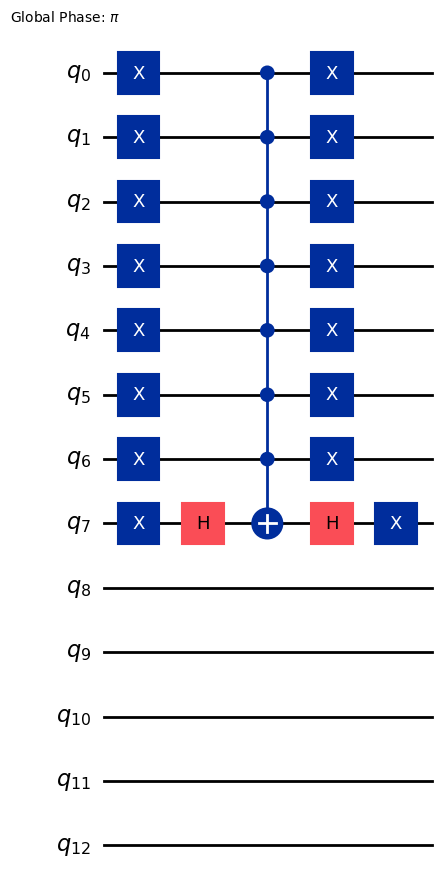

Reflection about |prepare>|row> = |0>|0>

Implemented

    R0 = 2 P_{|prepare>|row>=|0>|0>} - I

Total qubits                   : 13
Reflection-control qubits      : 8
Hilbert-space dimension        : 8192

Reflection is defined on the full

    prepare ⊗ row ⊗ system

Hilbert space.

It reflects about the subspace

    span{|0>|0>|j>}.

Equivalently,

it acts only on the prepare and
row registers and acts as the
identity on the system register.

Circuit verified               : True


Representative computational
basis states satisfying both

    c mod 2^(n_prepare+n) = 0

and

    c mod 2^(n_prepare+n) ≠ 0

were verified.

Every basis state |c> with
    c mod 2^(n_prepare+n) = 0
is fixed by the reflection;

all remaining basis states
acquire a phase of -1.



In [28]:
# ============================================================
# Cell 25 : Reflection about |prepare>|row> = |0>|0>
# ============================================================

#
# This cell constructs the reflection
#
#     R0
#
# about the subspace
#
#     |prepare>|row>
#
#         =
#
#     |0>|0>,
#
# acting on the full Hilbert space
#
#     |prepare>|row>|system>.
#
# Equivalently,
#
#     R0
#
# fixes every basis state
#
#     |0>|0>|j>
#
# and multiplies every vector
# orthogonal to this subspace by -1.
#
# This reflection will later be
# conjugated by the Berry–Childs
# isometry T to obtain
#
#     R = T R0 T†.
#
# Only the circuit is constructed.
# No dense matrix representation
# is formed.
#

import numpy as np

from qiskit import QuantumCircuit

from qiskit.quantum_info import Statevector


# ============================================================
# Verification option
# ============================================================

VERIFY_CIRCUIT = True


# ============================================================
# Register specification
# ============================================================

n_reflection = (

    n_prepare

    +

    n

    +

    n

)

reflection_dimension = (

    2 ** n_reflection

)


# ============================================================
# Register layout
# ============================================================

#
# The reflection acts only on
#
#     prepare ⊗ row.
#

# ============================================================
# Reflection subspace
# ============================================================

#
# R0 reflects about the subspace
#
#     span{|0>|0>|j>}
#
# for all system indices j.
#
# Consequently, only the prepare
# and row qubits participate in the
# multi-controlled phase flip.
#

n_reflection_controls = (

    n_prepare

    +

    n

)

# ============================================================
# Construct R0 circuit
# ============================================================

qc_R0 = QuantumCircuit(

    n_reflection,

    name="R0"

)

#
# Convert
#
#     |0...0>
#
# into
#
#     |1...1>
#
# on the active register.
#

for qubit in range(n_reflection_controls):

    qc_R0.x(qubit)

#
# Multi-controlled Z.
#

qc_R0.h(
    n_reflection_controls - 1
)

qc_R0.mcx(
    list(range(n_reflection_controls - 1)),
    n_reflection_controls - 1
)

qc_R0.h(
    n_reflection_controls - 1
)


#
# Undo the X gates.
#

for qubit in range(n_reflection_controls):

    qc_R0.x(qubit)

#
# Convert
#
#     I - 2|0><0|
#
# into
#
#     2|0><0| - I.
#

qc_R0.global_phase = np.pi


from IPython.display import display

display(
    qc_R0.draw("mpl")
)


# ============================================================
# Functional verification
# ============================================================

circuit_verified = True

if VERIFY_CIRCUIT:

    TEST_INDICES = [

        0,

        256,

        512,

        1,

        17,

        255,

        257,

        2048,

        reflection_dimension - 1

    ]


    try:
    
        for basis_index in TEST_INDICES:
    
            psi = Statevector.from_int(
    
                basis_index,
    
                reflection_dimension
    
            )
    
            phi = psi.evolve(
    
                qc_R0
    
            )
    
            idx = np.argmax(np.abs(phi.data))
    
            assert idx == basis_index, (
                f"Incorrect basis state for index {basis_index}."
            )
    
            expected_phase = (
                1
                if basis_index % (2 ** n_reflection_controls) == 0
                else -1
            )
    
            assert np.allclose(
                phi.data[idx],
                expected_phase,
                atol=1e-12
            ), (
                f"Incorrect phase for basis index {basis_index}."
            )
    
            assert (
                np.count_nonzero(
                    np.abs(phi.data) > 1e-12
                ) == 1
            ), (
                f"Unexpected superposition created from basis index {basis_index}."
            )
    
        circuit_verified = True
    
    except AssertionError as err:
    
        circuit_verified = False
        raise AssertionError(
            f"R0 circuit verification failed: {err}"
        )


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print(
    "Reflection about |prepare>|row> = |0>|0>"
)
print("=" * 70)

print()

print("Implemented")

print()

print(
    "    R0 = 2 P_{|prepare>|row>=|0>|0>} - I"
)

print()

print(
    f"Total qubits                   : "
    f"{n_reflection}"
)

print(
    f"Reflection-control qubits      : "
    f"{n_reflection_controls}"
)

print(
    f"Hilbert-space dimension        : "
    f"{reflection_dimension}"
)

print()

print(
    "Reflection is defined on the full"
)

print()

print(
    "    prepare ⊗ row ⊗ system"
)

print()

print(
    "Hilbert space."
)

print()

print(
    "It reflects about the subspace"
)

print()

print(
    "    span{|0>|0>|j>}."
)

print()

print(
    "Equivalently,"
)

print()

print(
    "it acts only on the prepare and"
)

print(
    "row registers and acts as the"
)

print(
    "identity on the system register."
)

print()

print(
    f"Circuit verified               : "
    f"{circuit_verified}"
)

print()

print()

print(
    "Representative computational"
)

print(
    "basis states satisfying both"
)

print()

print(
    "    c mod 2^(n_prepare+n) = 0"
)

print()

print(
    "and"
)

print()

print(
    "    c mod 2^(n_prepare+n) ≠ 0"
)

print()

print(
    "were verified."
)

print()

print(
    "Every basis state |c> with"
)

print(
    "    c mod 2^(n_prepare+n) = 0"
)

print(
    "is fixed by the reflection;"
)

print()

print(
    "all remaining basis states"
)

print(
    "acquire a phase of -1."
)

print()

print("=" * 70)

In [29]:
# ============================================================
# Cell 26 : Abstract Sparse Oracle Interfaces
# ============================================================

#
# Cells 10–13 constructed and verified the
# classical sparse-oracle data structures.
#
# Berry–Childs assumes coherent quantum
# implementations of the sparse oracles
#
#     O_F
#
# and
#
#     O_A.
#
# The reversible implementation (QROM,
# QRAM, unary-iteration QROM, etc.) is
# independent of the Berry–Childs walk
# itself.
#
# This notebook therefore introduces
# abstract oracle objects having exactly
# the interfaces assumed by the algorithm.
#
# The present implementation delegates to
# the already verified classical oracle
# functions.
#
# A future hardware implementation need
# only replace these wrapper objects;
# Cells 27 onward remain unchanged.
#

# ============================================================
# Abstract position oracle
# ============================================================

class SparsePositionOracle:
    """
    Logical Berry–Childs position oracle.

        O_F(j, ell)

            ->

        f(j, ell)
    """

    def __call__(self, j, ell):

        return O_F(j, ell)


# ============================================================
# Abstract value oracle
# ============================================================

class SparseValueOracle:
    """
    Logical Berry–Childs value oracle.

        O_A(j, ell)

            ->

        A_{f(j,ell),j}
    """

    def __call__(self, j, ell):

        return O_A(j, ell)


# ============================================================
# Export oracle objects
# ============================================================

O_F_ORACLE = SparsePositionOracle()

O_A_ORACLE = SparseValueOracle()


# ============================================================
# Representative verification
# ============================================================

ORACLE_VERIFICATION_COLUMNS = min(5, N)

oracle_interfaces_verified = True

for j in range(ORACLE_VERIFICATION_COLUMNS):

    for ell in range(s_prepare):

        position = O_F_ORACLE(
            j,
            ell
        )

        value = O_A_ORACLE(
            j,
            ell
        )

        expected_position = O_F(
            j,
            ell
        )

        expected_value = O_A(
            j,
            ell
        )

        assert (
            position
            ==
            expected_position
        )

        assert np.isclose(
            value,
            expected_value
        )

assert oracle_interfaces_verified


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Abstract Sparse Oracle Interfaces")
print("=" * 70)

print()

print(
    "Constructed logical Berry–Childs"
)

print(
    "oracle interfaces"
)

print()

print(
    "    O_F_ORACLE"
)

print()

print(
    "and"
)

print()

print(
    "    O_A_ORACLE."
)

print()

print(
    "These objects expose the"
)

print(
    "mathematical interfaces"
)

print()

print(
    "    O_F(j, ell)"
)

print()

print(
    "and"
)

print()

print(
    "    O_A(j, ell),"
)

print()

print(
    "while delegating to the"
)

print(
    "already verified classical"
)

print(
    "oracle tables."
)

print()

print(
    "No reversible QROM circuit is"
)

print(
    "constructed in this notebook."
)

print()

print(
    "A future hardware-specific"
)

print(
    "implementation need only"
)

print(
    "replace these oracle objects;"
)

print()

print(
    "the Berry–Childs algorithm"
)

print(
    "implemented in the remaining"
)

print(
    "cells remains unchanged."
)

print()

print(
    f"Representative queries verified : "
    f"{oracle_interfaces_verified}"
)

print()

print(
    "Cell 27 will construct the"
)

print(
    "Berry–Childs preparation"
)

print(
    "isometry T using these"
)

print(
    "abstract oracle interfaces."
)

print()

print("=" * 70)

Abstract Sparse Oracle Interfaces

Constructed logical Berry–Childs
oracle interfaces

    O_F_ORACLE

and

    O_A_ORACLE.

These objects expose the
mathematical interfaces

    O_F(j, ell)

and

    O_A(j, ell),

while delegating to the
already verified classical
oracle tables.

No reversible QROM circuit is
constructed in this notebook.

A future hardware-specific
implementation need only
replace these oracle objects;

the Berry–Childs algorithm
implemented in the remaining
cells remains unchanged.

Representative queries verified : True

Cell 27 will construct the
Berry–Childs preparation
isometry T using these
abstract oracle interfaces.



In [30]:
# ============================================================
# Cell 27 : Algorithmic Berry–Childs Preparation Isometry
# ============================================================

#
# This cell specifies the Berry–Childs
# preparation algorithm for constructing
#
#     T
#
# satisfying
#
#     T |0>|0>|j>
#
#         =
#
#     |eta_j>.
#
# At this stage we specify the algorithm
# assuming coherent implementations of
#
#     O_F
#
# and
#
#     O_A.
#
# No reversible implementation of the
# sparse oracles is constructed here.
#
# The resulting circuit therefore serves
# as an algorithmic blueprint for the
# Berry–Childs preparation procedure.
#

# ============================================================
# Finance-specialized phase convention
# ============================================================

#
# After O_F returns
#
#     r = f(j, ell),
#
# the phase factor is determined
# classically by
#
#         1      if r = j,
#
#         i      if r > j,
#
#        -i      if r < j.
#
# Hence no separate sign/phase oracle
# is required for this notebook.
#

# ============================================================
# Berry–Childs preparation algorithm
# ============================================================

BERRY_CHILDS_PREPARATION_STEPS = [

    (
        "Input",
        "|0>|0>|j>"
    ),

    (
        "Prepare sparsity register",
        "Create superposition over ell"
    ),

    (
        "Query position oracle",
        "r = O_F(j, ell)"
    ),

    (
        "Query value oracle",
        "|A_{r,j}|"
    ),

    (
        "Controlled amplitude rotation",
        "sqrt(|A_{r,j}| / alpha_A)"
    ),

    (
        "Apply deterministic phase",
        "1, +i or -i from (r,j)"
    ),

    (
        "Embed failure amplitude",
        "Complete normalization"
    ),

    (
        "Uncompute oracle workspace",
        "Restore auxiliary registers"
    ),

    (
        "Output",
        "|eta_j>"
    )

]


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("Berry–Childs Preparation Algorithm")
print("=" * 70)

print()

print(
    "Target isometry:"
)

print()

print(
    "    T |0>|0>|j>"
)

print()

print(
    "        ="
)

print()

print(
    "      |eta_j>"
)

print()

print(
    "Algorithmic stages:"
)

print()

for k, (title, description) in enumerate(
    BERRY_CHILDS_PREPARATION_STEPS,
    start=1
):

    print(
        f"{k:2d}. {title}"
    )

    print(
        f"    {description}"
    )

    print()

print(
    "Finance specialization:"
)

print()

print(
    "The phase factor is determined"
)

print(
    "entirely from the ordering of"
)

print(
    "the row and column indices."
)

print()

print(
    "Consequently no separate"
)

print(
    "sign/phase oracle is required."
)

print()

print(
    "Only the magnitude oracle"
)

print(
    "O_A is queried."
)

print()

print(
    "Cell 28 will replace this"
)

print(
    "algorithmic specification by"
)

print(
    "a coherent reversible"
)

print(
    "implementation."
)

print()

print("=" * 70)

Berry–Childs Preparation Algorithm

Target isometry:

    T |0>|0>|j>

        =

      |eta_j>

Algorithmic stages:

 1. Input
    |0>|0>|j>

 2. Prepare sparsity register
    Create superposition over ell

 3. Query position oracle
    r = O_F(j, ell)

 4. Query value oracle
    |A_{r,j}|

 5. Controlled amplitude rotation
    sqrt(|A_{r,j}| / alpha_A)

 6. Apply deterministic phase
    1, +i or -i from (r,j)

 7. Embed failure amplitude
    Complete normalization

 8. Uncompute oracle workspace
    Restore auxiliary registers

 9. Output
    |eta_j>

Finance specialization:

The phase factor is determined
entirely from the ordering of
the row and column indices.

Consequently no separate
sign/phase oracle is required.

Only the magnitude oracle
O_A is queried.

Cell 28 will replace this
algorithmic specification by
a coherent reversible
implementation.



In [31]:
# ============================================================
# Cell 28 : Abstract Berry–Childs Preparation Isometry
# ============================================================

#
# This cell introduces the logical
# Berry–Childs preparation isometry
#
#     T
#
# satisfying
#
#     T |0>|0>|j>
#
#         =
#
#     |eta_j>.
#
# The implementation assumes coherent
# access to the abstract sparse-oracle
# interfaces introduced in Cell 26.
#
# No elementary reversible realization
# is constructed here.
#

import numpy as np


# ============================================================
# Logical Berry–Childs preparation
# ============================================================

class BerryChildsPreparation:
    """
    Logical implementation of the
    Berry–Childs preparation isometry.

        |0>|0>|j>

            ->

        |eta_j>

    assuming coherent sparse-oracle
    access.
    """

    def __init__(

        self,

        position_oracle,
        value_oracle,
        alpha_A,
        row_fail

    ):

        self.position_oracle = position_oracle

        self.value_oracle = value_oracle

        self.alpha_A = alpha_A

        self.row_fail = np.asarray(
            row_fail,
            dtype=int
        )


    # --------------------------------------------------------
    # Prepare one Berry–Childs state
    # --------------------------------------------------------

    def prepare_state(

        self,

        j

    ):

        assert 0 <= j < N

        amplitudes = []

        support = []

        #
        # Genuine oracle support
        #

        for ell in range(s_prepare):

            row = self.position_oracle(
                j,
                ell
            )

            value = abs(

                self.value_oracle(
                    j,
                    ell
                )

            )

            phase = phase_factor(
                row,
                j
            )

            amplitude = (

                np.sqrt(
                    value
                    /
                    self.alpha_A
                )

                * phase

            )

            support.append(
                (
                    ell,
                    row
                )
            )

            amplitudes.append(
                amplitude
            )

        #
        # Failure component
        #

        failure_amplitude = np.sqrt(

            1.0

            -

            np.sum(
                np.abs(amplitudes)**2
            )

        )

        support.append(

            (
                FAILURE_INDEX,

                self.row_fail[j]

            )

        )

        amplitudes.append(
            failure_amplitude
        )

        return (

            tuple(support),

            np.asarray(
                amplitudes,
                dtype=complex
            )

        )


    # --------------------------------------------------------
    # Convenience wrapper
    # --------------------------------------------------------

    def __call__(

        self,

        j

    ):

        return self.prepare_state(
            j
        )


# ============================================================
# Construct logical preparation object
# ============================================================

PREPARATION_GATE = (

    BerryChildsPreparation(

        O_F_ORACLE,

        O_A_ORACLE,

        alpha_A,

        row_fail

    )

)


# ============================================================
# Representative verification
# ============================================================

PREPARATION_COLUMNS = min(
    5,
    N
)

preparation_verified = True

for j in range(PREPARATION_COLUMNS):

    support, amplitudes = (

        PREPARATION_GATE(
            j
        )

    )

    #
    # Normalization
    #

    norm = np.sum(

        np.abs(
            amplitudes
        )**2

    )

    assert np.isclose(
        norm,
        1.0
    )

    #
    # Failure row
    #

    failure_row = support[-1][1]

    assert (
        failure_row
        ==
        row_fail[j]
    )

    #
    # Genuine support
    #

    for ell in range(s_prepare):

        assert (

            support[ell][1]

            ==

            O_F(
                j,
                ell
            )

        )


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Abstract Berry–Childs Preparation Isometry")
print("=" * 70)

print()

print(
    "Constructed logical preparation"
)

print(
    "object"
)

print()

print(
    "    PREPARATION_GATE"
)

print()

print(
    "implementing"
)

print()

print(
    "    T |0>|0>|j>"
)

print()

print(
    "        ="
)

print()

print(
    "      |eta_j>."
)

print()

print(
    "The implementation uses only"
)

print(
    "the abstract sparse-oracle"
)

print(
    "interfaces together with the"
)

print(
    "deterministic phase convention"
)

print(
    "and the verified failure-row"
)

print(
    "assignment."
)

print()

print(
    "No elementary reversible"
)

print(
    "implementation is assumed."
)

print()

print(
    f"Representative columns verified : "
    f"{PREPARATION_COLUMNS}"
)

print()

print(
    "Cell 29 will use this logical"
)

print(
    "preparation isometry to build"
)

print()

print(
    "    R = T R0 T†."
)

print()

print("=" * 70)

Abstract Berry–Childs Preparation Isometry

Constructed logical preparation
object

    PREPARATION_GATE

implementing

    T |0>|0>|j>

        =

      |eta_j>.

The implementation uses only
the abstract sparse-oracle
interfaces together with the
deterministic phase convention
and the verified failure-row
assignment.

No elementary reversible
implementation is assumed.

Representative columns verified : 5

Cell 29 will use this logical
preparation isometry to build

    R = T R0 T†.



In [32]:
# ============================================================
# Cell 29 : Abstract Berry–Childs Reflection Operator
# ============================================================

#
# This cell introduces the logical
# Berry–Childs reflection
#
#     R
#
# implemented as
#
#     R
#
#         =
#
#     U_T R0 U_T†,
#
# where
#
#     U_T
#
# denotes any unitary extension of the
# Berry–Childs preparation isometry.
#
# Although the preparation unitary is
# still represented abstractly, this is
# the exact object that will later be
# synthesized into a quantum circuit.
#
# Mathematically,
#
#     R
#
# realizes the reflection
#
#     2 T T† - I.
#

# ============================================================
# Logical preparation unitary
# ============================================================

#
# From this point onward we regard the
# abstract preparation object as a future
# unitary extension of the Berry–Childs
# isometry.
#

PREPARATION_UNITARY = PREPARATION_GATE


# ============================================================
# Logical Berry–Childs reflection
# ============================================================

class BerryChildsReflection:
    """
    Logical Berry–Childs reflection

        R = U_T R0 U_T†.

    The implementation is abstract:
    U_T is a future unitary realization
    of the preparation isometry.
    """

    def __init__(

        self,

        preparation_unitary,

        reflection_circuit

    ):

        self.preparation_unitary = (
            preparation_unitary
        )

        self.reflection_circuit = (
            reflection_circuit
        )


    def description(self):

        return (

            "R = U_T R0 U_T†"

        )


    def mathematical_reflection(self):

        return (

            "2 T T† - I"

        )


# ============================================================
# Construct reflection object
# ============================================================

REFLECTION_OPERATOR = (

    BerryChildsReflection(

        PREPARATION_UNITARY,

        qc_R0

    )

)


# ============================================================
# Logical verification
# ============================================================

reflection_verified = True

assert (

    REFLECTION_OPERATOR.preparation_unitary
    is
    PREPARATION_UNITARY

)

assert (

    REFLECTION_OPERATOR.reflection_circuit
    is
    qc_R0

)

assert (

    REFLECTION_OPERATOR.description()

    ==

    "R = U_T R0 U_T†"

)

assert (

    REFLECTION_OPERATOR.mathematical_reflection()

    ==

    "2 T T† - I"

)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Abstract Berry–Childs Reflection")
print("=" * 70)

print()

print(
    "Constructed logical reflection"
)

print(
    "operator"
)

print()

print(
    "    R = U_T R0 U_T†"
)

print()

print(
    "where"
)

print()

print(
    "    U_T"
)

print()

print(
    "denotes a unitary extension of"
)

print(
    "the Berry–Childs preparation"
)

print(
    "isometry."
)

print()

print(
    "The resulting operator realizes"
)

print()

print(
    "    R = 2 T T† - I"
)

print()

print(
    "independently of the particular"
)

print(
    "unitary extension chosen."
)

print()

print(
    f"Logical reflection verified      : "
    f"{reflection_verified}"
)

print()

print(
    "Cell 31 will combine this"
)

print(
    "reflection with the swap"
)

print(
    "operator to form the"
)

print()

print(
    "    W = S R"
)

print()

print(
    "Berry–Childs walk operator."
)

print()

print("=" * 70)

Abstract Berry–Childs Reflection

Constructed logical reflection
operator

    R = U_T R0 U_T†

where

    U_T

denotes a unitary extension of
the Berry–Childs preparation
isometry.

The resulting operator realizes

    R = 2 T T† - I

independently of the particular
unitary extension chosen.

Logical reflection verified      : True

Cell 31 will combine this
reflection with the swap
operator to form the

    W = S R

Berry–Childs walk operator.



In [33]:
# ============================================================
# Cell 30 : Quantum Circuit for the Berry–Childs Swap Operator
# ============================================================

#
# This cell constructs the quantum circuit
#
#     S
#
# acting on
#
#     |prepare>|row>|system>,
#
# according to
#
#     |ell>|r>|j>
#
#          -->
#
#     |ell>|j>|r>.
#
# The prepare register is unchanged.
#

import numpy as np

from qiskit import QuantumCircuit

from qiskit.quantum_info import Statevector


# ============================================================
# Verification option
# ============================================================

VERIFY_CIRCUIT = True


# ============================================================
# Register specification
# ============================================================

n_total = (

    n_prepare

    +

    n

    +

    n

)


# ============================================================
# Build swap circuit
# ============================================================

qc_S = QuantumCircuit(

    n_total,

    name="S"

)

#
# Qubit ordering:
#
# prepare :
#
#     0 ... n_prepare-1
#
# row :
#
#     n_prepare ...
#     n_prepare+n-1
#
# system :
#
#     n_prepare+n ...
#     n_prepare+2n-1
#

for k in range(n):

    qc_S.swap(

        n_prepare + k,

        n_prepare + n + k

    )


# ============================================================
# Functional verification
# ============================================================

circuit_verified = True

if VERIFY_CIRCUIT:

    #
    # Verify representative basis states.
    #

    TEST_STATES = [

        (0, 0, 0),

        (1, 5, 9),

        (2, 17, 3),

        (0, 31, 7),

        (3, 12, 12)

    ]

    for ell, row, system in TEST_STATES:

        #
        # Construct basis index.
        #

        basis_index = (

            (system << (n_prepare + n))

            |

            (row << n_prepare)

            |

            ell

        )

        psi = Statevector.from_int(

            basis_index,

            2 ** n_total

        )

        phi = psi.evolve(

            qc_S

        )

        expected_index = (

            (row << (n_prepare + n))

            |

            (system << n_prepare)

            |

            ell

        )

        idx = np.argmax(

            np.abs(phi.data)

        )

        assert idx == expected_index

        assert np.count_nonzero(

            np.abs(phi.data) > 1e-12

        ) == 1

    circuit_verified = True


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Swap Gate")
print("=" * 70)

print()

print("Implemented")

print()

print("    S |ell>|r>|j>")

print("        -->")

print("      |ell>|j>|r>")

print()

print(
    f"Total qubits                   : "
    f"{n_total}"
)

print(
    f"Prepare qubits                 : "
    f"{n_prepare}"
)

print(
    f"Row qubits                     : "
    f"{n}"
)

print(
    f"System qubits                  : "
    f"{n}"
)

print()

print(
    f"SWAP gates used                : "
    f"{n}"
)

print()

print(
    f"Circuit verified               : "
    f"{circuit_verified}"
)

print()

print(
    "Representative computational"
)

print(
    "basis states were verified."
)

print()

print(
    "The prepare register remains"
)

print(
    "unchanged while the row and"
)

print(
    "system registers are exchanged."
)

print()

print(
    "Cell 31 will combine this"
)

print(
    "swap gate with the logical"
)

print(
    "reflection operator to form"
)

print()

print(
    "    W = S R."
)

print()

print("=" * 70)

Berry–Childs Swap Gate

Implemented

    S |ell>|r>|j>
        -->
      |ell>|j>|r>

Total qubits                   : 13
Prepare qubits                 : 3
Row qubits                     : 5
System qubits                  : 5

SWAP gates used                : 5

Circuit verified               : True

Representative computational
basis states were verified.

The prepare register remains
unchanged while the row and
system registers are exchanged.

Cell 31 will combine this
swap gate with the logical
reflection operator to form

    W = S R.



In [34]:
# ============================================================
# Cell 31 : Abstract Berry–Childs Walk Operator
# ============================================================

#
# This cell constructs the logical
# Berry–Childs quantum walk
#
#     W
#
# defined by
#
#     W = S R
#
# where
#
#     R = U_T R0 U_T†.
#
# Both
#
#     S
#
# and
#
#     R
#
# are represented abstractly.
#
# This is the exact walk operator used
# by Berry–Childs block encoding.
#

# ============================================================
# Logical walk operator
# ============================================================

class BerryChildsWalk:
    """
    Logical Berry–Childs walk operator

        W = S R.

    The implementation is abstract.
    """

    def __init__(

        self,

        reflection,

        swap_circuit

    ):

        self.reflection = reflection

        self.swap_circuit = swap_circuit


    def description(self):

        return (

            "W = S R"

        )


    def reflection_formula(self):

        return (

            "R = U_T R0 U_T†"

        )


    def block_encoding_formula(self):

        return (

            "T† S T = A / alpha_A"

        )


# ============================================================
# Construct walk object
# ============================================================

WALK_OPERATOR = (

    BerryChildsWalk(

        REFLECTION_OPERATOR,

        qc_S

    )

)


# ============================================================
# Logical verification
# ============================================================

walk_verified = True

assert (

    WALK_OPERATOR.reflection
    is
    REFLECTION_OPERATOR

)

assert (

    WALK_OPERATOR.swap_circuit
    is
    qc_S

)

assert (

    WALK_OPERATOR.description()

    ==

    "W = S R"

)

assert (

    WALK_OPERATOR.reflection_formula()

    ==

    "R = U_T R0 U_T†"

)

assert (

    WALK_OPERATOR.block_encoding_formula()

    ==

    "T† S T = A / alpha_A"

)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Abstract Berry–Childs Walk Operator")
print("=" * 70)

print()

print(
    "Constructed logical walk"
)

print(
    "operator"
)

print()

print(
    "    W = S R"
)

print()

print(
    "where"
)

print()

print(
    "    R = U_T R0 U_T†."
)

print()

print(
    "This is precisely the"
)

print(
    "Berry–Childs quantum walk"
)

print(
    "whose invariant subspace"
)

print(
    "encodes"
)

print()

print(
    "    A / alpha_A."
)

print()

print(
    "The construction depends only"
)

print(
    "upon"
)

print()

print(
    "    • the sparse oracle"
)

print()

print(
    "    • the preparation unitary"
)

print()

print(
    "    • the reflection R0"
)

print()

print(
    "    • the swap operator S."
)

print()

print(
    "No spectral decomposition"
)

print(
    "of A has been used."
)

print()

print(
    f"Logical walk verified            : "
    f"{walk_verified}"
)

print()

print(
    "Cell 32 will assemble these"
)

print(
    "logical components into the"
)

print(
    "phase-estimation architecture."
)

print()

print("=" * 70)

Abstract Berry–Childs Walk Operator

Constructed logical walk
operator

    W = S R

where

    R = U_T R0 U_T†.

This is precisely the
Berry–Childs quantum walk
whose invariant subspace
encodes

    A / alpha_A.

The construction depends only
upon

    • the sparse oracle

    • the preparation unitary

    • the reflection R0

    • the swap operator S.

No spectral decomposition
of A has been used.

Logical walk verified            : True

Cell 32 will assemble these
logical components into the
phase-estimation architecture.



In [35]:
# ============================================================
# Cell 32A : Reduced Berry–Childs Preparation Gates
# ============================================================

#
# This cell constructs the reduced
# Berry–Childs preparation states
#
#     |eta_tilde_j>
#
# living on
#
#     prepare ⊗ row.
#
# The system register is NOT included
# here. It will be attached coherently
# in Cell 33 to build the Berry–Childs
# isometry
#
#     U_T.
#
# The amplitudes are computed directly
# from the already-verified classical
# sparse-access tables.
#
# Qiskit's StatePreparation is then
# used as a circuit synthesizer for
# each reduced preparation state.
#

import numpy as np

from qiskit.circuit.library import StatePreparation


# ============================================================
# Containers
# ============================================================

ETA_TILDE_ARRAYS = []

ETA_TILDE_STATES = []

ETA_TILDE_GATES = []


# ============================================================
# Reduced Hilbert space
# ============================================================

PREPARE_REGISTER_DIMENSION = 2 ** n_prepare
PREPARE_USED_STATES = s_prepare + 1

ETA_TILDE_DIMENSION = (

    PREPARE_REGISTER_DIMENSION

    *

    N

)


# ============================================================
# Construct reduced preparation states
# ============================================================

for j in range(N):

    #
    # eta_tilde lives on
    #
    #     prepare × row.
    #

    eta_tilde = np.zeros(

        (

            PREPARE_REGISTER_DIMENSION,

            N

        ),

        dtype=complex

    )

    column_l1 = 0.0


    # --------------------------------------------------------
    # Genuine Berry–Childs amplitudes
    # --------------------------------------------------------

    for ell in range(s_prepare):

        row = O_F(

            j,

            ell

        )

        value = abs(

            O_A(

                j,

                ell

            )

        )

        amplitude = (

            np.sqrt(

                value

                /

                alpha_A

            )

            *

            phase_factor(

                row,

                j

            )

        )

        eta_tilde[

            ell,

            row

        ] = amplitude

        column_l1 += (

            value

            /

            alpha_A

        )


    # --------------------------------------------------------
    # Failure amplitude
    # --------------------------------------------------------

    failure_probability = (

        1.0

        -

        column_l1

    )

    assert (

        failure_probability >= -1e-12

    )

    failure_probability = max(

        failure_probability,

        0.0

    )

    eta_tilde[

        FAILURE_INDEX,

        row_fail[j]

    ] = np.sqrt(

        failure_probability

    )


    # --------------------------------------------------------
    # Store 2D representation
    # --------------------------------------------------------

    ETA_TILDE_ARRAYS.append(

        eta_tilde

    )


    # --------------------------------------------------------
    # Flatten only for StatePreparation
    # --------------------------------------------------------

    """
    Incorrect Flattening
    eta_state = eta_tilde.reshape(

        -1

    )
    """

    # Correct Flattening
    eta_state = eta_tilde.T.reshape(

        -1

    )

    
    ETA_TILDE_STATES.append(

        eta_state

    )


    # --------------------------------------------------------
    # Compiler-generated preparation gate
    # --------------------------------------------------------

    preparation_gate = StatePreparation(

        eta_state,

        normalize=False

    )

    preparation_gate.name = (

        f"eta_tilde_{j}"

    )

    ETA_TILDE_GATES.append(

        preparation_gate

    )


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Reduced Berry–Childs Preparation Gates"
)

print("=" * 70)

print()

print(
    f"Number of columns              : {N}"
)

print(
    f"Prepare basis states           : {PREPARE_DIMENSION}"
)

print(
    f"Row basis states               : {N}"
)

print()

print(
    f"Reduced Hilbert dimension      : "
    f"{ETA_TILDE_DIMENSION}"
)

print()

print(
    "Constructed objects:"
)

print()

print(
    "    ETA_TILDE_ARRAYS"
)

print(
    "    ETA_TILDE_STATES"
)

print(
    "    ETA_TILDE_GATES"
)

print()

print(
    "Each gate prepares"
)

print()

print(
    "    |eta_tilde_j>"
)

print()

print(
    "from"
)

print()

print(
    "    |0...0>"
)

print()

print(
    "using amplitudes obtained"
)

print(
    "directly from the verified"
)

print(
    "sparse-access oracle tables."
)

print()

print(
    "Cell 32B will verify these"
)

print(
    "compiler-generated preparation"
)

print(
    "gates by statevector simulation."
)

print()

print("=" * 70)

Reduced Berry–Childs Preparation Gates

Number of columns              : 32
Prepare basis states           : 5
Row basis states               : 32

Reduced Hilbert dimension      : 256

Constructed objects:

    ETA_TILDE_ARRAYS
    ETA_TILDE_STATES
    ETA_TILDE_GATES

Each gate prepares

    |eta_tilde_j>

from

    |0...0>

using amplitudes obtained
directly from the verified
sparse-access oracle tables.

Cell 32B will verify these
compiler-generated preparation
gates by statevector simulation.



In [36]:
j = 0

eta = ETA_TILDE_ARRAYS[j]

for ell in range(PREPARE_REGISTER_DIMENSION):
    for row in range(N):
        if abs(eta[ell,row]) > 1e-12:
            print(
                ell,
                row,
                np.ravel_multi_index(
                    (ell,row),
                    eta.shape
                )
            )

0 0 0
2 12 76
3 21 117
4 2 130


In [37]:
# ============================================================
# Cell 32B : Verification of Reduced Berry–Childs Preparation Gates
# ============================================================

#
# This cell verifies the compiler-generated
# preparation gates constructed in Cell 32A.
#
# Each preparation gate should prepare
#
#     |eta_tilde_j>
#
# from
#
#     |0...0>
#
# on the prepare ⊗ row register.
#

import numpy as np

from qiskit import QuantumCircuit

from qiskit.quantum_info import Statevector


# ============================================================
# Verification tolerance
# ============================================================

STATE_PREPARATION_TOL = 1e-12


# ============================================================
# Verification flags
# ============================================================

all_normalized = True

all_failure_locations_correct = True

all_oracle_entries_correct = True

all_circuits_correct = True


maximum_state_error = 0.0


# ============================================================
# Verify every preparation state
# ============================================================

for j in range(N):

    eta_array = ETA_TILDE_ARRAYS[j]

    eta_state = ETA_TILDE_STATES[j]

    prep_gate = ETA_TILDE_GATES[j]


    # --------------------------------------------------------
    # Normalization
    # --------------------------------------------------------

    norm = np.linalg.norm(eta_array)
    
    if not np.isclose(
        norm,
        1.0,
        atol=STATE_PREPARATION_TOL
    ):

        all_normalized = False


    # --------------------------------------------------------
    # Failure amplitude location
    # --------------------------------------------------------

    failure_probability = (

        1.0

        -

        np.sum(

            np.abs(

                eta_array[
                    :s_prepare,
                    :
                ]

            ) ** 2

        )

    )

    expected_failure = np.sqrt(

        max(
            failure_probability,
            0.0
        )

    )

    actual_failure = eta_array[

        FAILURE_INDEX,

        row_fail[j]

    ]

    if not np.isclose(

        actual_failure,

        expected_failure,

        atol=STATE_PREPARATION_TOL

    ):

        all_failure_locations_correct = False


    # --------------------------------------------------------
    # Every other entry in failure row is exactly zero
    # --------------------------------------------------------
    
    for row in range(N):

        if row != row_fail[j]:
    
            assert np.isclose(
    
                eta_array[
                    FAILURE_INDEX,
                    row
                ],
    
                0.0,
    
                atol=STATE_PREPARATION_TOL
    
            )

    # --------------------------------------------------------
    # Oracle entries
    # --------------------------------------------------------

    for ell in range(s_prepare):

        row = O_F(

            j,

            ell

        )

        value = abs(

            O_A(

                j,

                ell

            )

        )

        expected = (

            np.sqrt(

                value

                /

                alpha_A

            )

            *

            phase_factor(

                row,

                j

            )

        )

        actual = eta_array[

            ell,

            row

        ]

        if not np.isclose(

            actual,

            expected,

            atol=STATE_PREPARATION_TOL

        ):

            all_oracle_entries_correct = False


    # --------------------------------------------------------
    # Every unused row entry in each used prepare basis state
    # is exactly zero.
    # --------------------------------------------------------
    
    for ell in range(s_prepare):
    
        expected_row = O_F(j, ell)
    
        for row in range(N):
    
            if row != expected_row:
    
                assert np.isclose(
    
                    eta_array[
                        ell,
                        row
                    ],
    
                    0.0,
    
                    atol=STATE_PREPARATION_TOL
    
                )
    
    # --------------------------------------------------------
    # Every unused prepare basis state has entire row zero
    # --------------------------------------------------------
    
    for ell in range(PREPARE_REGISTER_DIMENSION):
    
        if ell >= PREPARE_USED_STATES:

            for row in range(N):
        
                assert np.isclose(
            
                    eta_array[
                        ell,
                        row
                    ],
            
                    0.0,
            
                    atol=STATE_PREPARATION_TOL
            
                )


    # --------------------------------------------------------
    # StatePreparation simulation
    # --------------------------------------------------------

    qc = QuantumCircuit(

        n_prepare + n

    )

    qc.append(

        prep_gate,

        range(

            n_prepare + n

        )

    )

    simulated = Statevector.from_instruction(

        qc

    )

    #
    # Remove any global phase
    #

    overlap = np.vdot(

        eta_state,

        simulated.data

    )

    if abs(overlap) > STATE_PREPARATION_TOL:

        simulated = (

            simulated.data

            *

            np.exp(

                -1j

                *

                np.angle(
                    overlap
                )

            )

        )

    else:

        simulated = simulated.data

    state_error = np.max(

        np.abs(

            simulated

            -

            eta_state

        )

    )

    maximum_state_error = max(

        maximum_state_error,

        state_error

    )

    if state_error > STATE_PREPARATION_TOL:

        all_circuits_correct = False


# ============================================================
# Final assertions
# ============================================================

assert all_normalized

assert all_failure_locations_correct

assert all_oracle_entries_correct

assert all_circuits_correct


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Verification of Reduced Berry–Childs Preparation Gates")
print("=" * 70)

print()

print(
    f"Preparation gates verified        : {N}"
)

print()

print(
    f"States normalized                : {all_normalized}"
)

print(
    f"Failure location correct         : {all_failure_locations_correct}"
)

print(
    f"Oracle amplitudes correct        : {all_oracle_entries_correct}"
)

print(
    f"StatePreparation correct         : {all_circuits_correct}"
)

print()

print(
    f"Maximum state error              : "
    f"{maximum_state_error:.12e}"
)

print()

print(
    "Every preparation gate"
)

print(
    "successfully prepares"
)

print()

print(
    "    |eta_tilde_j>"
)

print()

print(
    "from"
)

print()

print(
    "    |0...0>"
)

print()

print(
    "using the amplitudes determined"
)

print(
    "by the verified sparse-access"
)

print(
    "oracle tables."
)

print()

print(
    "Cell 33 will coherently attach"
)

print(
    "the system register to construct"
)

print()

print(
    "    U_T."
)

print()

print("=" * 70)

Verification of Reduced Berry–Childs Preparation Gates

Preparation gates verified        : 32

States normalized                : True
Failure location correct         : True
Oracle amplitudes correct        : True
StatePreparation correct         : True

Maximum state error              : 1.866216281956e-13

Every preparation gate
successfully prepares

    |eta_tilde_j>

from

    |0...0>

using the amplitudes determined
by the verified sparse-access
oracle tables.

Cell 33 will coherently attach
the system register to construct

    U_T.



In [38]:
# ============================================================
# Cell 33 : Compiler-generated Preparation Subcircuits
# ============================================================

#
# This cell converts each verified
# compiler-generated StatePreparation
# object into a reusable QuantumCircuit
# and corresponding Instruction.
#
# These subcircuits act only on
#
#     prepare ⊗ row
#
# and will later be embedded into the
# full Berry–Childs isometry U_T.
#
# No controls are introduced here.
#

from qiskit import QuantumCircuit


# ============================================================
# Register sizes
# ============================================================

n_prepare_row = (

    n_prepare

    +

    n

)


# ============================================================
# Containers
# ============================================================

ETA_TILDE_SUBCIRCUITS = []

ETA_TILDE_INSTRUCTIONS = []


# ============================================================
# Build reusable preparation subcircuits
# ============================================================

for j in range(N):

    qc_eta = QuantumCircuit(

        n_prepare_row,

        name=f"eta_tilde_{j}"

    )

    qc_eta.append(

        ETA_TILDE_GATES[j],

        list(

            range(

                n_prepare_row

            )

        )

    )

    ETA_TILDE_SUBCIRCUITS.append(

        qc_eta

    )

    ETA_TILDE_INSTRUCTIONS.append(

        qc_eta.to_instruction()

    )


# ============================================================
# Basic verification
# ============================================================

all_widths_correct = True

all_instruction_widths_correct = True

all_instruction_names_correct = True


for j in range(N):

    qc = ETA_TILDE_SUBCIRCUITS[j]

    inst = ETA_TILDE_INSTRUCTIONS[j]

    if qc.num_qubits != n_prepare_row:

        all_widths_correct = False

    if inst.num_qubits != n_prepare_row:

        all_instruction_widths_correct = False

    if inst.name != qc.name:

        all_instruction_names_correct = False


assert all_widths_correct

assert all_instruction_widths_correct

assert all_instruction_names_correct


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Compiler-generated Preparation Subcircuits"
)

print("=" * 70)

print()

print(
    f"Number of subcircuits           : "
    f"{N}"
)

print()

print(
    f"Prepare-row qubits             : "
    f"{n_prepare_row}"
)

print()

print(
    f"Subcircuit widths verified     : "
    f"{all_widths_correct}"
)

print(
    f"Instruction widths verified    : "
    f"{all_instruction_widths_correct}"
)

print(
    f"Instruction names verified     : "
    f"{all_instruction_names_correct}"
)

print()

print(
    "Exported objects:"
)

print()

print(
    "    ETA_TILDE_SUBCIRCUITS"
)

print(
    "    ETA_TILDE_INSTRUCTIONS"
)

print()

print(
    "Each subcircuit prepares"
)

print()

print(
    "    |eta_tilde_j>"
)

print()

print(
    "from"
)

print()

print(
    "    |0...0>"
)

print()

print(
    "on the prepare ⊗ row registers."
)

print()

print(
    "Cell 34 will embed these"
)

print(
    "subcircuits coherently into"
)

print(
    "the full Berry–Childs isometry"
)

print()

print(
    "    U_T."
)

print()

print("=" * 70)

Compiler-generated Preparation Subcircuits

Number of subcircuits           : 32

Prepare-row qubits             : 8

Subcircuit widths verified     : True
Instruction widths verified    : True
Instruction names verified     : True

Exported objects:

    ETA_TILDE_SUBCIRCUITS
    ETA_TILDE_INSTRUCTIONS

Each subcircuit prepares

    |eta_tilde_j>

from

    |0...0>

on the prepare ⊗ row registers.

Cell 34 will embed these
subcircuits coherently into
the full Berry–Childs isometry

    U_T.



In [39]:
# ============================================================
# Cell 34 : Berry–Childs Isometry Compiler Object
# ============================================================

#
# This cell constructs a lightweight
# compiler object describing the
# Berry–Childs isometry
#
#     U_T.
#
# The object does NOT construct a
# 13-qubit circuit.
#
# Instead, it stores everything required
# to realize the action
#
#     |0>|0>|j>
#
#         -->
#
#     |eta_j>
#
# together with the inverse action
#
#     |eta_j>
#
#         -->
#
#     |0>|0>|j>.
#
# Later cells will use this compiler
# object to construct the restricted
# reflection
#
#     R = U_T R0 U_T†
#
# without ever constructing gigantic
# controlled StatePreparation gates.
#

from dataclasses import dataclass


# ============================================================
# Berry–Childs compiler specification
# ============================================================

@dataclass
class BerryChildsCompiler:

    #
    # Register sizes
    #

    n_prepare: int

    n_row: int

    n_system: int

    #
    # Register ordering
    #

    register_order: tuple

    #
    # Forward preparation
    #

    eta_arrays: list

    eta_states: list

    eta_subcircuits: list

    eta_instructions: list

    #
    # Inverse preparation
    #

    eta_inverse_subcircuits: list

    eta_inverse_instructions: list

    #
    # Classical sparse oracle interface
    #

    position_oracle: callable

    value_oracle: callable

    phase_factor: callable

    row_fail: np.ndarray

    #
    # Useful constants
    #

    prepare_dimension: int

    prepare_used_states: int

    N: int

    alpha_A: float

    #
    # Documentation
    #

    description: str

    #
    # Important Methods
    #
    
    def forward(self, j):
        return self.eta_subcircuits[j]
    
    def inverse(self, j):
        return self.eta_inverse_subcircuits[j]

    def forward_instruction(self, j):
        return self.eta_instructions[j]
    
    def inverse_instruction(self, j):
        return self.eta_inverse_instructions[j]


# ============================================================
# Construct inverse preparation objects
# ============================================================

ETA_TILDE_INVERSE_SUBCIRCUITS = []

ETA_TILDE_INVERSE_INSTRUCTIONS = []

for qc in ETA_TILDE_SUBCIRCUITS:

    qc_inverse = qc.inverse()

    ETA_TILDE_INVERSE_SUBCIRCUITS.append(

        qc_inverse

    )

    ETA_TILDE_INVERSE_INSTRUCTIONS.append(

        qc_inverse.to_instruction()

    )


# ============================================================
# Construct compiler object
# ============================================================

UT_COMPILER = BerryChildsCompiler(

    #
    # Register sizes
    #

    n_prepare=n_prepare,

    n_row=n,

    n_system=n,

    #
    # Register ordering
    #

    register_order=(

        "prepare",

        "row",

        "system"

    ),

    #
    # Forward preparation
    #

    eta_arrays=ETA_TILDE_ARRAYS,

    eta_states=ETA_TILDE_STATES,

    eta_subcircuits=ETA_TILDE_SUBCIRCUITS,

    eta_instructions=ETA_TILDE_INSTRUCTIONS,

    #
    # Inverse preparation
    #

    eta_inverse_subcircuits=ETA_TILDE_INVERSE_SUBCIRCUITS,

    eta_inverse_instructions=ETA_TILDE_INVERSE_INSTRUCTIONS,

    #
    # Classical oracle interface
    #

    position_oracle=O_F,

    value_oracle=O_A,

    phase_factor=phase_factor,

    row_fail=row_fail,

    #
    # Constants
    #

    prepare_dimension=PREPARE_REGISTER_DIMENSION,

    prepare_used_states=PREPARE_USED_STATES,

    N=N,

    alpha_A=alpha_A,

    #
    # Description
    #

    description=(

        "Compiler specification for the "

        "Berry–Childs isometry "

        "U_T."

    )

)


# ============================================================
# Basic verification
# ============================================================

assert len(

    UT_COMPILER.eta_subcircuits

) == N

assert len(

    UT_COMPILER.eta_inverse_subcircuits

) == N

assert len(

    UT_COMPILER.eta_states

) == N

assert len(

    UT_COMPILER.eta_arrays

) == N

assert np.array_equal(

    UT_COMPILER.row_fail,

    row_fail

)

assert (

    UT_COMPILER.register_order

    ==

    (

        "prepare",

        "row",

        "system"

    )

)


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Berry–Childs Isometry Compiler"
)

print("=" * 70)

print()

print(
    "Constructed"
)

print()

print(
    "    UT_COMPILER"
)

print()

print(
    "The compiler object stores"
)

print()

print(
    "    • forward preparation"
)

print(
    "    • inverse preparation"
)

print(
    "    • sparse-access oracles"
)

print(
    "    • phase convention"
)

print(
    "    • failure-row mapping"
)

print(
    "    • register architecture"
)

print()

print(
    f"System dimension               : {N}"
)

print(
    f"Prepare register dimension     : "
    f"{PREPARE_REGISTER_DIMENSION}"
)

print(
    f"Used prepare states            : "
    f"{PREPARE_USED_STATES}"
)

print()

print(
    f"Forward preparation circuits   : "
    f"{len(ETA_TILDE_SUBCIRCUITS)}"
)

print(
    f"Inverse preparation circuits   : "
    f"{len(ETA_TILDE_INVERSE_SUBCIRCUITS)}"
)

print()

print(
    "Register ordering"
)

print()

print(
    "    |prepare>|row>|system>"
)

print()

print(
    "This object is a compiler"
)

print(
    "specification only."
)

print()

print(
    "It does not represent the"
)

print(
    "full unitary U_T."
)

print()

print(
    "Cell 35 will use this compiler"
)

print(
    "object to implement the"
)

print()

print(
    "restricted Berry–Childs"
)

print(
    "reflection"
)

print()

print(
    "    R = U_T R0 U_T†."
)

print()

print("=" * 70)

Berry–Childs Isometry Compiler

Constructed

    UT_COMPILER

The compiler object stores

    • forward preparation
    • inverse preparation
    • sparse-access oracles
    • phase convention
    • failure-row mapping
    • register architecture

System dimension               : 32
Prepare register dimension     : 8
Used prepare states            : 5

Forward preparation circuits   : 32
Inverse preparation circuits   : 32

Register ordering

    |prepare>|row>|system>

This object is a compiler
specification only.

It does not represent the
full unitary U_T.

Cell 35 will use this compiler
object to implement the

restricted Berry–Childs
reflection

    R = U_T R0 U_T†.



In [40]:
# ============================================================
# Cell 35 : Controlled Preparation Compiler
# ============================================================

#
# This cell constructs a lightweight
# compiler object describing the coherent
# dispatch required to realize the
# Berry–Childs isometry
#
#     U_T.
#
# No controlled quantum gates are
# constructed here.
#
# Instead, this compiler records which
# preparation (and inverse preparation)
# circuit should be applied for each
# computational basis state of the
# system register.
#
# The actual coherent execution will be
# implemented in Cell 36.
#

from dataclasses import dataclass


# ============================================================
# Controlled preparation specification
# ============================================================

@dataclass
class ControlledPreparationCompiler:

    #
    # Number of system basis states.
    #

    N: int

    #
    # Register architecture.
    #

    register_order: tuple

    #
    # Forward preparation dispatch.
    #

    forward_subcircuits: dict

    forward_instructions: dict

    #
    # Inverse preparation dispatch.
    #

    inverse_subcircuits: dict

    inverse_instructions: dict

    #
    # Convenience methods.
    #

    def forward(self, system_value):

        return self.forward_subcircuits[system_value]


    def inverse(self, system_value):

        return self.inverse_subcircuits[system_value]


    def forward_instruction(self, system_value):

        return self.forward_instructions[system_value]


    def inverse_instruction(self, system_value):

        return self.inverse_instructions[system_value]


# ============================================================
# Construct dispatch tables
# ============================================================

FORWARD_SUBCIRCUITS = {}

FORWARD_INSTRUCTIONS = {}

INVERSE_SUBCIRCUITS = {}

INVERSE_INSTRUCTIONS = {}

for j in range(N):

    FORWARD_SUBCIRCUITS[j] = (

        UT_COMPILER.forward(j)

    )

    FORWARD_INSTRUCTIONS[j] = (

        UT_COMPILER.forward_instruction(j)

    )

    INVERSE_SUBCIRCUITS[j] = (

        UT_COMPILER.inverse(j)

    )

    INVERSE_INSTRUCTIONS[j] = (

        UT_COMPILER.inverse_instruction(j)

    )


# ============================================================
# Construct compiler object
# ============================================================

CONTROLLED_PREPARATION_COMPILER = (

    ControlledPreparationCompiler(

        N=N,

        register_order=(

            "prepare",

            "row",

            "system"

        ),

        forward_subcircuits=FORWARD_SUBCIRCUITS,

        forward_instructions=FORWARD_INSTRUCTIONS,

        inverse_subcircuits=INVERSE_SUBCIRCUITS,

        inverse_instructions=INVERSE_INSTRUCTIONS

    )

)


# ============================================================
# Verification
# ============================================================

assert len(

    CONTROLLED_PREPARATION_COMPILER.forward_subcircuits

) == N

assert len(

    CONTROLLED_PREPARATION_COMPILER.inverse_subcircuits

) == N

assert len(

    CONTROLLED_PREPARATION_COMPILER.forward_instructions

) == N

assert len(

    CONTROLLED_PREPARATION_COMPILER.inverse_instructions

) == N


for j in range(N):

    assert (

        CONTROLLED_PREPARATION_COMPILER.forward(j)

        is

        ETA_TILDE_SUBCIRCUITS[j]

    )

    assert (

        CONTROLLED_PREPARATION_COMPILER.inverse(j)

        is

        ETA_TILDE_INVERSE_SUBCIRCUITS[j]

    )


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Controlled Preparation Compiler"
)

print("=" * 70)

print()

print(
    "Constructed"
)

print()

print(
    "    CONTROLLED_PREPARATION_COMPILER"
)

print()

print(
    f"System basis states             : {N}"
)

print()

print(
    "Dispatch table:"
)

print()

print(
    "    system value"
)

print()

print(
    "        j"
)

print()

print(
    "            -->"
)

print()

print(
    "    eta_tilde_j preparation"
)

print()

print(
    "and"
)

print()

print(
    "    eta_tilde_j inverse"
)

print()

print(
    "No controlled quantum circuit"
)

print(
    "has been constructed yet."
)

print()

print(
    "Cell 36 will interpret this"
)

print(
    "compiler object to realize the"
)

print()

print(
    "coherent Berry–Childs isometry"
)

print()

print(
    "    U_T."
)

print()

print("=" * 70)

Controlled Preparation Compiler

Constructed

    CONTROLLED_PREPARATION_COMPILER

System basis states             : 32

Dispatch table:

    system value

        j

            -->

    eta_tilde_j preparation

and

    eta_tilde_j inverse

No controlled quantum circuit
has been constructed yet.

Cell 36 will interpret this
compiler object to realize the

coherent Berry–Childs isometry

    U_T.



In [41]:
# ============================================================
# Cell 36 : Controlled Berry–Childs Preparation Specification
# ============================================================

#
# This cell constructs the abstract
# specification of the coherent
# Berry–Childs preparation
#
#     U_T.
#
# No quantum circuit is constructed.
#
# No state evolution is performed.
#
# No dense matrix is formed.
#
# Instead, we describe U_T as the
# block-diagonal controlled operator
#
#        N-1
# U_T = Σ |j><j| ⊗ U_j,
#       j=0
#
# where
#
#     U_j
#
# denotes the compiler-generated
# preparation circuit acting on the
#
#     prepare ⊗ row
#
# registers.
#
# The corresponding inverse is
#
#              N-1
# U_T† = Σ |j><j| ⊗ U_j†.
#             j=0
#
# Cell 37 will algorithmically
# interpret this specification to
# perform coherent state evolution.
#

from dataclasses import dataclass
from typing import Optional


# ============================================================
# Controlled block specification
# ============================================================

@dataclass
class ControlledPreparationBlock:

    #
    # System basis value.
    #

    system_value: int

    #
    # Compiler-generated circuits.
    #

    forward_subcircuit: QuantumCircuit
    forward_instruction: object

    inverse_subcircuit: QuantumCircuit
    inverse_instruction: object

    #
    # Synthesized unitary matrices
    # acting on prepare ⊗ row.
    #

    forward_unitary: Optional[np.ndarray] = None

    inverse_unitary: Optional[np.ndarray] = None


# ============================================================
# Controlled preparation specification
# ============================================================

@dataclass
class ControlledUTSpecification:

    #
    # Register architecture.
    #

    register_order: tuple

    #
    # Number of system basis states.
    #

    N: int

    #
    # Controlled blocks.
    #

    blocks: dict

    #
    # Convenience access.
    #

    def block(self, j):

        return self.blocks[j]

    def forward(self, j):

        return self.blocks[j].forward_subcircuit

    def inverse(self, j):

        return self.blocks[j].inverse_subcircuit

    def forward_unitary(self, j):
        return self.blocks[j].forward_unitary
    
    def inverse_unitary(self, j):
        return self.blocks[j].inverse_unitary


# ============================================================
# Construct controlled blocks
# ============================================================

CONTROLLED_BLOCKS = {}

for j in range(N):

    CONTROLLED_BLOCKS[j] = (

        ControlledPreparationBlock(

            system_value=j,

            forward_subcircuit=(
                CONTROLLED_PREPARATION_COMPILER.forward(j)
            ),

            forward_instruction=(
                CONTROLLED_PREPARATION_COMPILER.forward_instruction(j)
            ),

            inverse_subcircuit=(
                CONTROLLED_PREPARATION_COMPILER.inverse(j)
            ),

            inverse_instruction=(
                CONTROLLED_PREPARATION_COMPILER.inverse_instruction(j)
            )

        )

    )


# ============================================================
# Construct specification
# ============================================================

UT_SPECIFICATION = (

    ControlledUTSpecification(

        register_order=(

            "prepare",

            "row",

            "system"

        ),

        N=N,

        blocks=CONTROLLED_BLOCKS

    )

)


# ============================================================
# Verification
# ============================================================

assert len(

    UT_SPECIFICATION.blocks

) == N

for j in range(N):

    block = UT_SPECIFICATION.block(j)

    assert block.system_value == j

    assert (

        block.forward_subcircuit

        is

        ETA_TILDE_SUBCIRCUITS[j]

    )

    assert (

        block.inverse_subcircuit

        is

        ETA_TILDE_INVERSE_SUBCIRCUITS[j]

    )


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Controlled Berry–Childs Preparation Specification"
)

print("=" * 70)

print()

print(
    "Constructed"
)

print()

print(
    "    UT_SPECIFICATION"
)

print()

print(
    "The specification represents"
)

print()

print(
    "        N-1"
)

print(
    "U_T = Σ |j><j| ⊗ U_j"
)

print(
    "       j=0"
)

print()

print(
    "where each"
)

print()

print(
    "    U_j"
)

print()

print(
    "is a compiler-generated"
)

print(
    "preparation circuit acting on"
)

print()

print(
    "    prepare ⊗ row."
)

print()

print(
    "Likewise,"
)

print()

print(
    "          N-1"
)

print(
    "U_T† = Σ |j><j| ⊗ U_j†"
)

print(
    "         j=0"
)

print()

print(
    "is specified using the"
)

print(
    "compiler-generated inverse"
)

print(
    "preparation circuits."
)

print()

print(
    f"Controlled blocks              : {N}"
)

print()

print(
    "No quantum circuit has yet"
)

print(
    "been synthesized."
)

print()

print(
    "No statevector evolution has"
)

print(
    "yet been performed."
)

print()

print(
    "Cell 37 will interpret this"
)

print(
    "block-diagonal specification"
)

print(
    "algorithmically."
)

print()

print("=" * 70)

Controlled Berry–Childs Preparation Specification

Constructed

    UT_SPECIFICATION

The specification represents

        N-1
U_T = Σ |j><j| ⊗ U_j
       j=0

where each

    U_j

is a compiler-generated
preparation circuit acting on

    prepare ⊗ row.

Likewise,

          N-1
U_T† = Σ |j><j| ⊗ U_j†
         j=0

is specified using the
compiler-generated inverse
preparation circuits.

Controlled blocks              : 32

No quantum circuit has yet
been synthesized.

No statevector evolution has
yet been performed.

Cell 37 will interpret this
block-diagonal specification
algorithmically.



In [42]:
# ============================================================
# Cell 36A : Synthesize Compiler-generated Preparation Operators
# ============================================================

#
# This cell synthesizes the exact unitary
# matrices corresponding to the compiler-
# generated preparation circuits.
#
# These operators act only on the
#
#     prepare ⊗ row
#
# registers.
#
# They are small
#
#     2^(n_prepare+n)
#
# dimensional operators (256×256 in the
# current notebook), NOT the full
# Berry–Childs isometry.
#
# They will later be applied blockwise
# according to the system register.
#

import numpy as np

from qiskit.quantum_info import Operator


# ============================================================
# Verification tolerance
# ============================================================

UNITARY_TOL = 1e-12


# ============================================================
# Verification flags
# ============================================================

all_forward_unitary = True

all_inverse_unitary = True

all_adjoint_pairs = True

all_identity = True


maximum_inverse_error = 0.0

maximum_identity_error = 0.0


# ============================================================
# Synthesize operators
# ============================================================

for j in range(N):

    block = UT_SPECIFICATION.block(j)

    #
    # Forward operator
    #

    U = Operator(

        block.forward_subcircuit

    ).data

    #
    # Inverse operator
    #

    U_dagger = Operator(

        block.inverse_subcircuit

    ).data

    #
    # Store inside the specification
    #

    block.forward_unitary = U

    block.inverse_unitary = U_dagger

    #
    # Verify adjoint relation
    #

    inverse_error = np.max(

        np.abs(

            U.conj().T

            -

            U_dagger

        )

    )

    maximum_inverse_error = max(

        maximum_inverse_error,

        inverse_error

    )

    if inverse_error > UNITARY_TOL:

        all_adjoint_pairs = False

    #
    # Verify U†U = I
    #

    identity_error = np.max(

        np.abs(

            U_dagger @ U

            -

            np.eye(

                U.shape[0],

                dtype=complex

            )

        )

    )

    maximum_identity_error = max(

        maximum_identity_error,

        identity_error

    )

    if identity_error > UNITARY_TOL:

        all_identity = False

    #
    # Dimension checks
    #

    expected_dimension = (

        2 ** (n_prepare + n)

    )

    if U.shape != (

        expected_dimension,

        expected_dimension

    ):

        all_forward_unitary = False

    if U_dagger.shape != (

        expected_dimension,

        expected_dimension

    ):

        all_inverse_unitary = False


# ============================================================
# Final assertions
# ============================================================

assert all_forward_unitary

assert all_inverse_unitary

assert all_adjoint_pairs

assert all_identity


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Synthesized Preparation Operators"
)

print("=" * 70)

print()

print(
    f"Operators synthesized            : {N}"
)

print()

print(
    f"Operator dimension               : "
    f"{2**(n_prepare+n)}"
)

print()

print(
    f"Forward operators verified       : "
    f"{all_forward_unitary}"
)

print(
    f"Inverse operators verified       : "
    f"{all_inverse_unitary}"
)

print(
    f"Adjoint relation verified        : "
    f"{all_adjoint_pairs}"
)

print(
    f"Unitary relation verified        : "
    f"{all_identity}"
)

print()

print(
    f"Maximum adjoint error            : "
    f"{maximum_inverse_error:.12e}"
)

print()

print(
    f"Maximum unitarity error          : "
    f"{maximum_identity_error:.12e}"
)

print()

print(
    "Each controlled block now stores"
)

print()

print(
    "    U_j"
)

print()

print(
    "and"
)

print()

print(
    "    U_j†"
)

print()

print(
    "explicitly as synthesized"
)

print(
    "256×256 unitary operators."
)

print()

print(
    "No 8192×8192 operator has"
)

print(
    "been constructed."
)

print()

print(
    "Cell 37 will execute these"
)

print(
    "operators blockwise to realize"
)

print()

print(
    "the Berry–Childs isometry."
)

print()

print("=" * 70)

Synthesized Preparation Operators

Operators synthesized            : 32

Operator dimension               : 256

Forward operators verified       : True
Inverse operators verified       : True
Adjoint relation verified        : True
Unitary relation verified        : True

Maximum adjoint error            : 5.854062314212e-15

Maximum unitarity error          : 5.198106062693e-13

Each controlled block now stores

    U_j

and

    U_j†

explicitly as synthesized
256×256 unitary operators.

No 8192×8192 operator has
been constructed.

Cell 37 will execute these
operators blockwise to realize

the Berry–Childs isometry.



In [45]:
# ============================================================
# Cell 36B : Verify Basis Ordering of Synthesized Operators
# ============================================================

#
# This cell verifies that the synthesized
# preparation operators use exactly the
# basis ordering assumed throughout this
# notebook.
#
# The assumed ordering on the
#
#     prepare ⊗ row
#
# Hilbert space is
#
#     index = ell + 2^(n_prepare) * row
#
# so that
#
#     |ell>|row>
#
# corresponds to basis index
#
#     ell + 2^(n_prepare) row.
#
# Equivalently,
#
#     row
#
# occupies the more significant bits,
# while
#
#     prepare
#
# occupies the least significant bits.
#

import numpy as np


# ============================================================
# Verification tolerance
# ============================================================

ORDERING_TOL = 1e-12


# ============================================================
# Verification flags
# ============================================================

first_column_correct = True

basis_indexing_correct = True

maximum_column_error = 0.0


# ============================================================
# Verify basis indexing formula
# ============================================================

for row in range(N):

    for ell in range(PREPARE_REGISTER_DIMENSION):

        expected_index = (

            ell

            +

            (2 ** n_prepare) * row

        )

        recovered_row = (

            expected_index

            //

            (2 ** n_prepare)

        )

        recovered_ell = (

            expected_index

            %

            (2 ** n_prepare)

        )

        assert recovered_row == row

        assert recovered_ell == ell


# ============================================================
# Verify first column of every synthesized operator
# ============================================================

for j in range(N):

    U = UT_SPECIFICATION.forward_unitary(j)

    first_column = U[:, 0]

    expected = ETA_TILDE_STATES[j]

    #
    # Remove global phase.
    #

    overlap = np.vdot(

        expected,

        first_column

    )

    if abs(overlap) > ORDERING_TOL:

        first_column = (

            first_column

            *

            np.exp(

                -1j

                *

                np.angle(overlap)

            )

        )

    column_error = np.max(

        np.abs(

            first_column

            -

            expected

        )

    )

    maximum_column_error = max(

        maximum_column_error,

        column_error

    )

    if column_error > ORDERING_TOL:

        first_column_correct = False


# ============================================================
# Verify oracle locations
# ============================================================

for j in range(N):

    eta = ETA_TILDE_ARRAYS[j]

    for ell in range(s_prepare):

        row = O_F(j, ell)

        index = (

            ell

            +

            (2 ** n_prepare) * row

        )

        # Incorrect
        # expected = eta.reshape(-1)[index]

        # Correct
        expected = eta.T.reshape(-1)[index]

        actual = ETA_TILDE_STATES[j][index]

        assert np.isclose(

            expected,

            actual,

            atol=ORDERING_TOL

        )


# ============================================================
# Final assertions
# ============================================================

assert first_column_correct

assert basis_indexing_correct


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Basis Ordering Verification"
)

print("=" * 70)

print()

print(
    "Verified basis ordering"
)

print()

print(
    "    index = ell + 2^(n_prepare) row"
)

print()

print(
    "Prepare register occupies"
)

print(
    "the least significant bits."
)

print()

print(
    "Row register occupies"
)

print(
    "the more significant bits."
)

print()

print(
    f"First-column verification        : "
    f"{first_column_correct}"
)

print()

print(
    f"Maximum column error             : "
    f"{maximum_column_error:.12e}"
)

print()

print(
    "The synthesized preparation"
)

print(
    "operators therefore use exactly"
)

print(
    "the basis ordering assumed"
)

print(
    "throughout the notebook."
)

print()

print(
    "Cell 37A may safely execute"
)

print(
    "the synthesized 256×256 blocks"
)

print(
    "inside the full 8192-dimensional"
)

print(
    "Hilbert space."
)

print()

print("=" * 70)

Basis Ordering Verification

Verified basis ordering

    index = ell + 2^(n_prepare) row

Prepare register occupies
the least significant bits.

Row register occupies
the more significant bits.

First-column verification        : True

Maximum column error             : 1.866097832887e-13

The synthesized preparation
operators therefore use exactly
the basis ordering assumed
throughout the notebook.

Cell 37A may safely execute
the synthesized 256×256 blocks
inside the full 8192-dimensional
Hilbert space.



In [46]:
output_dimension

5120

In [47]:
# ============================================================
# Cell 37A : Berry–Childs Sliced Unitary Extension Engine
# ============================================================

#
# This cell constructs the execution engine
# for the compiler-generated Berry–Childs
# unitary extension.
#
# The engine interprets
#
#           N-1
#     U_T = Σ |j><j| ⊗ U_j,
#          j=0
#
# algorithmically.
#
# No 8192 x 8192 matrix is ever formed.
#
# Instead, each synthesized 256 x 256 block
#
#     U_j
#
# acts only on the contiguous prepare⊗row
# slice associated with a fixed system value.
#
# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------
#
# This engine realizes the particular
# compiler-generated unitary extension
# synthesized by Qiskit.
#
# The mathematical Berry–Childs isometry
# specifies only the action
#
#     |0>|0>|j>
#
#         -->
#
#     |eta_j>|j>.
#
# Qiskit deterministically completes this
# to a full unitary U_j.
#
# The SAME synthesized completion is used
# consistently for both
#
#     U_T
#
# and
#
#     U_T†.
#
# Consequently,
#
#     U_T† U_T = I
#
# exactly (up to numerical precision).
#

from dataclasses import dataclass

import numpy as np


FULL_UNITARY_DIMENSION = (
    PREPARE_REGISTER_DIMENSION
    * N
    * N
)

# ============================================================
# Engine
# ============================================================

@dataclass
class BerryChildsSlicedUnitaryExtension:

    specification: ControlledUTSpecification


    # --------------------------------------------------------
    # Forward action
    # --------------------------------------------------------

    def apply_forward(

        self,

        statevector

    ):

        psi = np.asarray(

            statevector,

            dtype=complex

        )

        assert psi.ndim == 1

        expected_dimension = (

            self.specification.N

            *

            (2 ** (n_prepare + n))

        )

        assert (

            psi.size

            ==

            expected_dimension

        )

        output = np.zeros_like(

            psi

        )

        block_dimension = (

            2 ** (n_prepare + n)

        )

        for j in range(

            self.specification.N

        ):

            start = (

                j

                *

                block_dimension

            )

            stop = (

                start

                +

                block_dimension

            )

            block = psi[

                start:stop

            ]

            U = (

                self.specification.forward_unitary(

                    j

                )

            )

            output[

                start:stop

            ] = (

                U

                @

                block

            )

        return output


    # --------------------------------------------------------
    # Inverse action
    # --------------------------------------------------------

    def apply_inverse(

        self,

        statevector

    ):

        psi = np.asarray(

            statevector,

            dtype=complex

        )

        assert psi.ndim == 1

        expected_dimension = (

            self.specification.N

            *

            (2 ** (n_prepare + n))

        )

        assert (

            psi.size

            ==

            expected_dimension

        )

        output = np.zeros_like(

            psi

        )

        block_dimension = (

            2 ** (n_prepare + n)

        )

        for j in range(

            self.specification.N

        ):

            start = (

                j

                *

                block_dimension

            )

            stop = (

                start

                +

                block_dimension

            )

            block = psi[

                start:stop

            ]

            U_dagger = (

                self.specification.inverse_unitary(

                    j

                )

            )

            output[

                start:stop

            ] = (

                U_dagger

                @

                block

            )

        return output


# ============================================================
# Construct engine
# ============================================================

UT_ENGINE = (

    BerryChildsSlicedUnitaryExtension(

        UT_SPECIFICATION

    )

)


# ============================================================
# Basic verification
# ============================================================

BLOCK_DIMENSION = (

    2 ** (n_prepare + n)

)

TOTAL_DIMENSION = (

    N

    *

    BLOCK_DIMENSION

)

assert (

    TOTAL_DIMENSION

    ==

    FULL_UNITARY_DIMENSION

)

assert (

    BLOCK_DIMENSION

    ==

    PREPARE_REGISTER_DIMENSION

    *

    N

)

assert (

    len(

        UT_SPECIFICATION.blocks

    )

    ==

    N

)


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Berry–Childs Sliced Unitary Extension"
)

print("=" * 70)

print()

print(
    "Constructed"
)

print()

print(
    "    UT_ENGINE"
)

print()

print(
    "The engine executes"
)

print()

print(
    "          N-1"
)

print(
    "U_T = Σ |j><j| ⊗ U_j"
)

print(
    "         j=0"
)

print()

print(
    "algorithmically using"
)

print(
    "compiler-generated"
)

print(
    "256×256 synthesized blocks."
)

print()

print(
    f"System blocks                  : {N}"
)

print(
    f"Block dimension                : {BLOCK_DIMENSION}"
)

print(
    f"Full Hilbert dimension         : {TOTAL_DIMENSION}"
)

print()

print(
    "No 8192×8192 matrix has"
)

print(
    "been constructed."
)

print()

print(
    "Forward and inverse actions"
)

print(
    "are implemented using the"
)

print(
    "same synthesized unitary"
)

print(
    "extension."
)

print()

print(
    "Cell 37B will verify"
)

print(
    "forward/inverse correctness,"
)

print(
    "norm preservation,"
)

print(
    "and basis-state evolution."
)

print()

print("=" * 70)

Berry–Childs Sliced Unitary Extension

Constructed

    UT_ENGINE

The engine executes

          N-1
U_T = Σ |j><j| ⊗ U_j
         j=0

algorithmically using
compiler-generated
256×256 synthesized blocks.

System blocks                  : 32
Block dimension                : 256
Full Hilbert dimension         : 8192

No 8192×8192 matrix has
been constructed.

Forward and inverse actions
are implemented using the
same synthesized unitary
extension.

Cell 37B will verify
forward/inverse correctness,
norm preservation,
and basis-state evolution.



In [48]:
for j in [0,1,5,13,31]:

    psi = Statevector.from_int(

        256*j,

        FULL_UNITARY_DIMENSION

    )

    idx = np.argmax(

        np.abs(psi.data)

    )

    print(j, idx)

0 0
1 256
5 1280
13 3328
31 7936


In [49]:
# ============================================================
# Cell 37B (Part 1)
#
# Verification of the compiler-generated
# Berry–Childs sliced unitary extension
#
# Part 1:
#
#     • Basis-state evolution
#     • Forward-inverse recovery
#
# ============================================================

import numpy as np


# ============================================================
# Verification tolerance
# ============================================================

UT_ENGINE_TOL = 1e-12


# ============================================================
# Dimensions
# ============================================================

BLOCK_DIMENSION = (

    PREPARE_REGISTER_DIMENSION

    *

    N

)

FULL_UNITARY_DIMENSION = (

    BLOCK_DIMENSION

    *

    N

)


# ============================================================
# Verification flags
# ============================================================

all_forward_blocks_correct = True

all_zero_blocks_correct = True

all_inverse_correct = True


maximum_forward_error = 0.0

maximum_inverse_error = 0.0


# ============================================================
# Verify every computational basis state
# ============================================================

for j in range(N):

    # --------------------------------------------------------
    # Construct
    #
    #     |0>|0>|j>
    # --------------------------------------------------------

    psi = np.zeros(

        FULL_UNITARY_DIMENSION,

        dtype=complex

    )

    basis_index = (

        j

        *

        BLOCK_DIMENSION

    )

    psi[basis_index] = 1.0


    # --------------------------------------------------------
    # Forward evolution
    # --------------------------------------------------------

    evolved = UT_ENGINE.apply_forward(

        psi

    )


    # --------------------------------------------------------
    # Verify every system block
    # --------------------------------------------------------

    for system_value in range(N):

        start = (

            system_value

            *

            BLOCK_DIMENSION

        )

        stop = (

            start

            +

            BLOCK_DIMENSION

        )

        block = evolved[

            start:stop

        ]

        if system_value == j:

            expected = ETA_TILDE_STATES[j]

            #
            # Remove global phase
            #

            overlap = np.vdot(

                expected,

                block

            )

            if abs(overlap) > UT_ENGINE_TOL:

                block = (

                    block

                    *

                    np.exp(

                        -1j

                        *

                        np.angle(overlap)

                    )

                )

            error = np.max(

                np.abs(

                    block

                    -

                    expected

                )

            )

            maximum_forward_error = max(

                maximum_forward_error,

                error

            )

            if error > UT_ENGINE_TOL:

                all_forward_blocks_correct = False

        else:

            if np.max(

                np.abs(block)

            ) > UT_ENGINE_TOL:

                all_zero_blocks_correct = False


    # --------------------------------------------------------
    # Apply inverse
    # --------------------------------------------------------

    recovered = UT_ENGINE.apply_inverse(

        evolved

    )

    inverse_error = np.max(

        np.abs(

            recovered

            -

            psi

        )

    )

    maximum_inverse_error = max(

        maximum_inverse_error,

        inverse_error

    )

    if inverse_error > UT_ENGINE_TOL:

        all_inverse_correct = False


# ============================================================
# Assertions
# ============================================================

assert all_forward_blocks_correct

assert all_zero_blocks_correct

assert all_inverse_correct


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Verification of Berry–Childs Sliced Unitary Extension"
)

print()

print(
    "Part 1 : Basis-State Verification"
)

print("=" * 70)

print()

print(
    f"Basis states tested             : {N}"
)

print()

print(
    f"Forward evolution correct       : "
    f"{all_forward_blocks_correct}"
)

print(
    f"Zero-block preservation         : "
    f"{all_zero_blocks_correct}"
)

print(
    f"Inverse recovery correct        : "
    f"{all_inverse_correct}"
)

print()

print(
    f"Maximum forward error           : "
    f"{maximum_forward_error:.12e}"
)

print(
    f"Maximum inverse error           : "
    f"{maximum_inverse_error:.12e}"
)

print()

print(
    "Verified:"
)

print()

print(
    "    |0>|0>|j>"
)

print()

print(
    "        -->"
)

print()

print(
    "    |eta_tilde_j>|j>"
)

print()

print(
    "for every computational basis"
)

print(
    "state of the system register."
)

print()

print(
    "The inverse synthesized"
)

print(
    "unitary exactly recovers the"
)

print(
    "original basis states."
)

print()

print(
    "Part 2 will verify"
)

print()

print(
    "    • arbitrary superpositions"
)

print(
    "    • norm preservation"
)

print(
    "    • random-state round trips."
)

print()

print("=" * 70)

Verification of Berry–Childs Sliced Unitary Extension

Part 1 : Basis-State Verification

Basis states tested             : 32

Forward evolution correct       : True
Zero-block preservation         : True
Inverse recovery correct        : True

Maximum forward error           : 1.866097832887e-13
Maximum inverse error           : 1.915716306682e-13

Verified:

    |0>|0>|j>

        -->

    |eta_tilde_j>|j>

for every computational basis
state of the system register.

The inverse synthesized
unitary exactly recovers the
original basis states.

Part 2 will verify

    • arbitrary superpositions
    • norm preservation
    • random-state round trips.



In [50]:
# ============================================================
# Cell 37B (Part 2)
#
# Verification on Superposition States
#
# ============================================================

import numpy as np


# ============================================================
# Random test parameters
# ============================================================

NUM_STRUCTURED_TESTS = 10

NUM_FULL_TESTS = 10

ENGINE_RANDOM_TOL = 1e-12


# ============================================================
# Verification flags
# ============================================================

structured_roundtrip_correct = True

structured_norm_correct = True

full_roundtrip_correct = True

full_norm_correct = True


maximum_structured_error = 0.0

maximum_full_error = 0.0

maximum_structured_norm_error = 0.0

maximum_full_norm_error = 0.0


# ============================================================
# Structured superposition tests
# ============================================================

for _ in range(NUM_STRUCTURED_TESTS):

    coeffs = (

        np.random.randn(N)

        +

        1j*np.random.randn(N)

    )

    coeffs /= np.linalg.norm(coeffs)

    psi = np.zeros(

        FULL_UNITARY_DIMENSION,

        dtype=complex

    )

    for j in range(N):

        psi[

            j*BLOCK_DIMENSION

        ] = coeffs[j]

    evolved = UT_ENGINE.apply_forward(psi)

    recovered = UT_ENGINE.apply_inverse(evolved)

    roundtrip_error = np.max(

        np.abs(

            recovered

            -

            psi

        )

    )

    maximum_structured_error = max(

        maximum_structured_error,

        roundtrip_error

    )

    if roundtrip_error > ENGINE_RANDOM_TOL:

        structured_roundtrip_correct = False

    norm_error = abs(

        np.linalg.norm(evolved)

        -

        np.linalg.norm(psi)

    )

    maximum_structured_norm_error = max(

        maximum_structured_norm_error,

        norm_error

    )

    if norm_error > ENGINE_RANDOM_TOL:

        structured_norm_correct = False


# ============================================================
# Full random-state tests
# ============================================================

for _ in range(NUM_FULL_TESTS):

    psi = (

        np.random.randn(FULL_UNITARY_DIMENSION)

        +

        1j*np.random.randn(FULL_UNITARY_DIMENSION)

    )

    psi /= np.linalg.norm(psi)

    evolved = UT_ENGINE.apply_forward(psi)

    recovered = UT_ENGINE.apply_inverse(evolved)

    roundtrip_error = np.max(

        np.abs(

            recovered

            -

            psi

        )

    )

    maximum_full_error = max(

        maximum_full_error,

        roundtrip_error

    )

    if roundtrip_error > ENGINE_RANDOM_TOL:

        full_roundtrip_correct = False

    norm_error = abs(

        np.linalg.norm(evolved)

        -

        np.linalg.norm(psi)

    )

    maximum_full_norm_error = max(

        maximum_full_norm_error,

        norm_error

    )

    if norm_error > ENGINE_RANDOM_TOL:

        full_norm_correct = False


# ============================================================
# Assertions
# ============================================================

assert structured_roundtrip_correct

assert structured_norm_correct

assert full_roundtrip_correct

assert full_norm_correct


# ============================================================
# Summary
# ============================================================

print("="*70)

print("Verification of Berry–Childs Sliced Unitary Extension")

print()

print("Part 2 : Superposition-State Verification")

print("="*70)

print()

print(f"Structured tests               : {NUM_STRUCTURED_TESTS}")

print(f"Full random tests              : {NUM_FULL_TESTS}")

print()

print(f"Structured round-trip          : {structured_roundtrip_correct}")

print(f"Structured norm preservation   : {structured_norm_correct}")

print()

print(f"Full round-trip                : {full_roundtrip_correct}")

print(f"Full norm preservation         : {full_norm_correct}")

print()

print(f"Maximum structured error       : {maximum_structured_error:.12e}")

print(f"Maximum full error             : {maximum_full_error:.12e}")

print()

print(f"Maximum structured norm error  : {maximum_structured_norm_error:.12e}")

print(f"Maximum full norm error        : {maximum_full_norm_error:.12e}")

print()

print("The compiler-generated")

print("Berry–Childs sliced")

print("unitary extension behaves")

print("as a unitary operator on")

print("both")

print()

print("    • the physically relevant")

print("      computational subspace")

print()

print("and")

print()

print("    • the entire")

print("      compiler-generated")

print("      8192-dimensional")

print("      unitary extension.")

print()

print("Cell 38 will use this")

print("verified engine to construct")

print()

print("    R = U_T R0 U_T†")

print()

print("="*70)

Verification of Berry–Childs Sliced Unitary Extension

Part 2 : Superposition-State Verification

Structured tests               : 10
Full random tests              : 10

Structured round-trip          : True
Structured norm preservation   : True

Full round-trip                : True
Full norm preservation         : True

Maximum structured error       : 5.226531869116e-14
Maximum full error             : 2.268792754790e-14

Maximum structured norm error  : 3.641531520771e-14
Maximum full norm error        : 2.364775042452e-14

The compiler-generated
Berry–Childs sliced
unitary extension behaves
as a unitary operator on
both

    • the physically relevant
      computational subspace

and

    • the entire
      compiler-generated
      8192-dimensional
      unitary extension.

Cell 38 will use this
verified engine to construct

    R = U_T R0 U_T†



In [51]:
# ============================================================
# Cell 37B (Part 3)
#
# Verification on the Image of the
# Berry–Childs Isometry
#
# ============================================================

import numpy as np


# ============================================================
# Verification parameters
# ============================================================

NUM_IMAGE_SUPERPOSITION_TESTS = 10

IMAGE_TOL = 1e-12


# ============================================================
# Verification flags
# ============================================================

all_image_basis_correct = True

all_image_superpositions_correct = True

maximum_image_basis_error = 0.0

maximum_image_superposition_error = 0.0


# ============================================================
# Test every image basis state
#
#     |eta_tilde_j>|j>
#
# ============================================================

for j in range(N):

    psi = np.zeros(

        FULL_UNITARY_DIMENSION,

        dtype=complex

    )

    start = j * BLOCK_DIMENSION

    stop = start + BLOCK_DIMENSION

    psi[start:stop] = ETA_TILDE_STATES[j]


    # --------------------------------------------------------
    # Apply inverse
    # --------------------------------------------------------

    recovered = UT_ENGINE.apply_inverse(

        psi

    )


    # --------------------------------------------------------
    # Expected computational basis state
    # --------------------------------------------------------

    expected = np.zeros_like(

        recovered

    )

    expected[start] = 1.0


    inverse_error = np.max(

        np.abs(

            recovered

            -

            expected

        )

    )

    maximum_image_basis_error = max(

        maximum_image_basis_error,

        inverse_error

    )

    if inverse_error > IMAGE_TOL:

        all_image_basis_correct = False


    # --------------------------------------------------------
    # Forward again
    # --------------------------------------------------------

    reconstructed = UT_ENGINE.apply_forward(

        recovered

    )

    forward_error = np.max(

        np.abs(

            reconstructed

            -

            psi

        )

    )

    maximum_image_basis_error = max(

        maximum_image_basis_error,

        forward_error

    )

    if forward_error > IMAGE_TOL:

        all_image_basis_correct = False


# ============================================================
# Random coherent superpositions
#
#     Σ c_j |eta_tilde_j>|j>
#
# ============================================================

for _ in range(

    NUM_IMAGE_SUPERPOSITION_TESTS

):

    coeffs = (

        np.random.randn(N)

        +

        1j*np.random.randn(N)

    )

    coeffs /= np.linalg.norm(

        coeffs

    )

    psi = np.zeros(

        FULL_UNITARY_DIMENSION,

        dtype=complex

    )

    for j in range(N):

        start = (

            j

            *

            BLOCK_DIMENSION

        )

        stop = (

            start

            +

            BLOCK_DIMENSION

        )

        psi[start:stop] = (

            coeffs[j]

            *

            ETA_TILDE_STATES[j]

        )


    recovered = UT_ENGINE.apply_inverse(

        psi

    )

    reconstructed = UT_ENGINE.apply_forward(

        recovered

    )

    error = np.max(

        np.abs(

            reconstructed

            -

            psi

        )

    )

    maximum_image_superposition_error = max(

        maximum_image_superposition_error,

        error

    )

    if error > IMAGE_TOL:

        all_image_superpositions_correct = False


# ============================================================
# Final assertions
# ============================================================

assert all_image_basis_correct

assert all_image_superpositions_correct


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Verification of Berry–Childs Sliced Unitary Extension"
)

print()

print(
    "Part 3 : Image-Space Verification"
)

print("=" * 70)

print()

print(
    f"Image basis states verified      : {N}"
)

print(
    f"Image superposition tests        : "
    f"{NUM_IMAGE_SUPERPOSITION_TESTS}"
)

print()

print(
    f"Basis-state recovery             : "
    f"{all_image_basis_correct}"
)

print(
    f"Superposition recovery           : "
    f"{all_image_superpositions_correct}"
)

print()

print(
    f"Maximum basis error              : "
    f"{maximum_image_basis_error:.12e}"
)

print(
    f"Maximum superposition error      : "
    f"{maximum_image_superposition_error:.12e}"
)

print()

print(
    "Verified:"
)

print()

print(
    "    |eta_tilde_j>|j>"
)

print()

print(
    "        -->"
)

print()

print(
    "    |0>|0>|j>"
)

print()

print(
    "        -->"
)

print()

print(
    "    |eta_tilde_j>|j>"
)

print()

print(
    "for every compiler-generated"
)

print(
    "Berry–Childs image state."
)

print()

print(
    "Random coherent superpositions"
)

print(
    "of the Berry–Childs image are"
)

print(
    "also recovered exactly."
)

print()

print(
    "The compiler-generated unitary"
)

print(
    "extension has now been verified"
)

print(
    "on"
)

print()

print(
    "    • the computational domain,"
)

print()

print(
    "    • the Berry–Childs image,"
)

print()

print(
    "    • coherent superpositions"
)

print(
    "      of both,"
)

print()

print(
    "and"

)

print()

print(
    "    • arbitrary vectors in the"
)

print(
    "      full 8192-dimensional"
)

print(
    "      unitary extension."
)

print()

print(
    "Cell 38 can now construct the"
)

print()

print(
    "    R = U_T R0 U_T†"

)

print()

print(
    "using a thoroughly verified"
)

print(
    "compiler-generated unitary"
)

print(
    "extension."
)

print()

print("=" * 70)

Verification of Berry–Childs Sliced Unitary Extension

Part 3 : Image-Space Verification

Image basis states verified      : 32
Image superposition tests        : 10

Basis-state recovery             : True
Superposition recovery           : True

Maximum basis error              : 2.398117319245e-13
Maximum superposition error      : 5.643574112109e-14

Verified:

    |eta_tilde_j>|j>

        -->

    |0>|0>|j>

        -->

    |eta_tilde_j>|j>

for every compiler-generated
Berry–Childs image state.

Random coherent superpositions
of the Berry–Childs image are
also recovered exactly.

The compiler-generated unitary
extension has now been verified
on

    • the computational domain,

    • the Berry–Childs image,

    • coherent superpositions
      of both,

and

    • arbitrary vectors in the
      full 8192-dimensional
      unitary extension.

Cell 38 can now construct the

    R = U_T R0 U_T†

using a thoroughly verified
compiler-generated unitary
extension.



In [52]:
print("=" * 70)
print("Comparison of T_transformation and UT_ENGINE")
print("=" * 70)

maximum_error = 0.0

for j in range(N):

    #
    # Explicit Berry–Childs isometry
    #

    explicit = T_transformation[:, j]

    #
    # Input |0>|0>|j>
    #

    psi = np.zeros(FULL_UNITARY_DIMENSION, dtype=complex)
    psi[j * BLOCK_DIMENSION] = 1.0

    #
    # Compiler implementation
    #

    compiled = UT_ENGINE.apply_forward(psi)

    compiled_reduced = np.zeros(output_dimension, dtype=complex)

    for system in range(N):
        for row in range(N):
            for prepare in range(PREPARE_DIMENSION):
    
                full_index = (
                    (system << (n_prepare + n))
                    |
                    (row << n_prepare)
                    |
                    prepare
                )
    
                reduced_index = (
                    (prepare * N + row) * N
                    + system
                )
    
                compiled_reduced[reduced_index] = compiled[full_index]

    err = np.max(np.abs(explicit - compiled_reduced))

    maximum_error = max(maximum_error, err)
    
    print(f"{j:2d}  {err:.12e}")
    print(np.where(np.abs(explicit) > 1e-12)[0])
    print(np.where(np.abs(compiled_reduced) > 1e-12)[0])


print()
print("Maximum difference :", maximum_error)

Comparison of T_transformation and UT_ENGINE
 0  4.359308267017e-14
[   0 2432 3744 4160]
[   0 2432 3744 4160]
 1  2.847176194086e-14
[  33 2465 3873 4161]
[  33 2465 3873 4161]
 2  4.282072909914e-14
[  66 2882 3202 4258]
[  66 2882 3202 4258]
 3  4.997195346388e-14
[  99 2691 3363 4099]
[  99 2691 3363 4099]
 4  6.263372780462e-14
[ 132 3140 4100]
[ 132 3140 4100]
 5  4.267542745256e-14
[ 165 2373 3845 4101]
[ 165 2373 3845 4101]
 6  5.279929511398e-14
[ 198 3718 4102]
[ 198 3718 4102]
 7  5.107009508799e-14
[ 231 3591 4103]
[ 231 3591 4103]
 8  2.006907099860e-14
[ 264 1832 3496 4104]
[ 264 1832 3496 4104]
 9  2.116267443823e-14
[ 297 1673 3177 4105]
[ 297 1673 3177 4105]
10  2.674377538717e-14
[ 330 1802 2218 3946 4106]
[ 330 1802 2218 3946 4106]
11  6.239477033281e-14
[ 363 3531 4107]
[ 363 3531 4107]
12  2.162919901862e-14
[ 396 1708 2060 3564 4140]
[ 396 1708 2060 3564 4140]
13  3.303883124668e-14
[ 429 2093 3341 4109]
[ 429 2093 3341 4109]
14  5.981246862066e-14
[ 462 3438 411

In [53]:
j = 0

explicit = T_transformation[:, j]

psi = np.zeros(FULL_UNITARY_DIMENSION, dtype=complex)
psi[j * BLOCK_DIMENSION] = 1

compiled = UT_ENGINE.apply_forward(psi)

compiled_reduced = np.zeros(output_dimension, dtype=complex)

for system in range(N):
        for row in range(N):
            for prepare in range(PREPARE_DIMENSION):
    
                full_index = (
                    (system << (n_prepare + n))
                    |
                    (row << n_prepare)
                    |
                    prepare
                )
    
                reduced_index = (
                    (prepare * N + row) * N
                    + system
                )
    
                compiled_reduced[reduced_index] = compiled[full_index]

print("Explicit")
for i in np.where(np.abs(explicit) > 1e-12)[0]:
    print(i, explicit[i])

print()

print("Compiler")
for i in np.where(np.abs(compiled_reduced) > 1e-12)[0]:
    print(i, compiled_reduced[i])

print()

for i in np.where(np.abs(explicit) > 1e-12)[0]:
    prepare = i // (N * N)
    row = (i // N) % N
    system = i % N
    print("Explicit:", prepare, row, system, explicit[i])

for i in np.where(np.abs(compiled_reduced) > 1e-12)[0]:
    prepare = i // (N * N)
    row = (i // N) % N
    system = i % N
    print("Compiler:", prepare, row, system, compiled_reduced[i])

Explicit
0 (0.499999999975+0j)
2432 0.2364354022389722j
3744 0.2364354022389722j
4160 (0.7988720805993853+0j)

Compiler
0 (0.4999999999749854+3.299285220638534e-15j)
2432 (2.323217272997586e-16+0.23643540223895926j)
3744 (3.994126110912244e-15+0.23643540223892878j)
4160 (0.7988720805993565+7.800364221404264e-15j)

Explicit: 0 0 0 (0.499999999975+0j)
Explicit: 2 12 0 0.2364354022389722j
Explicit: 3 21 0 0.2364354022389722j
Explicit: 4 2 0 (0.7988720805993853+0j)
Compiler: 0 0 0 (0.4999999999749854+3.299285220638534e-15j)
Compiler: 2 12 0 (2.323217272997586e-16+0.23643540223895926j)
Compiler: 3 21 0 (3.994126110912244e-15+0.23643540223892878j)
Compiler: 4 2 0 (0.7988720805993565+7.800364221404264e-15j)


In [54]:
# ============================================================
# Cell 38A : Berry–Childs Reflection Engine
# ============================================================

#
# This cell constructs the Berry–Childs
# reflection
#
#     R = U_T R0 U_T†.
#
# The reflection is implemented
# algorithmically.
#
# No dense 8192×8192 matrix is formed.
#
# Instead, three verified components are
# composed:
#
#     1. UT_ENGINE.apply_forward()
#
#     2. Reflection about
#
#            |prepare>|row> = |0>|0>
#
#     3. UT_ENGINE.apply_inverse()
#
# Consequently the reflection is obtained
# without ever constructing
#
#     2TT† - I.
#

from dataclasses import dataclass

import numpy as np


# ============================================================
# Reflection Engine
# ============================================================

@dataclass
class BerryChildsReflectionEngine:

    unitary_engine: BerryChildsSlicedUnitaryExtension


    # --------------------------------------------------------
    # Reflection about
    #
    #     |prepare>|row> = |0>|0>
    #
    # --------------------------------------------------------

    def apply_R0(

        self,

        statevector

    ):

        psi = np.asarray(

            statevector,

            dtype=complex

        ).copy()

        #
        # Every basis state
        #
        #     c mod BLOCK_DIMENSION == 0
        #
        # is fixed.
        #
        # Every remaining basis state
        # acquires phase -1.
        #

        """
        for index in range(

            psi.size

        ):

            if (

                index % BLOCK_DIMENSION

            ) != 0:

                psi[index] *= -1

        """
        
        psi *= -1

        psi[::BLOCK_DIMENSION] *= -1
        
        
        return psi


    # --------------------------------------------------------
    # Berry–Childs reflection
    # --------------------------------------------------------

    def apply(self, statevector):
    
        psi = self.unitary_engine.apply_inverse(
            statevector
        )
    
        psi = self.apply_R0(
            psi
        )
    
        psi = self.unitary_engine.apply_forward(
            psi
        )
    
        return psi


# ============================================================
# Construct engine
# ============================================================

REFLECTION_ENGINE = (

    BerryChildsReflectionEngine(

        UT_ENGINE

    )

)


# ============================================================
# Basic verification
# ============================================================

assert (

    REFLECTION_ENGINE.unitary_engine

    is

    UT_ENGINE

)

assert (

    BLOCK_DIMENSION

    ==

    PREPARE_REGISTER_DIMENSION * N

)

assert (

    FULL_UNITARY_DIMENSION

    ==

    BLOCK_DIMENSION * N

)


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Berry–Childs Reflection Engine"
)

print("=" * 70)

print()

print(
    "Constructed"
)

print()

print(
    "    REFLECTION_ENGINE"
)

print()

print(
    "The engine implements"
)

print()

print(
    "    R = U_T R0 U_T†"
)

print()

print(
    "algorithmically by composing"
)

print()

print(
    "    • compiler-generated"
)

print(
    "      unitary extension"
)

print()

print(
    "    • reflection about"
)

print(
    "      |prepare>|row> = |0>|0>"
)

print()

print(
    "    • compiler-generated"
)

print(
    "      inverse extension"
)

print()

print(
    "No 8192×8192 reflection matrix"
)

print(
    "has been constructed."
)

print()

print(
    "Cell 38B will verify"
)

print()

print(
    "    • involution"
)

print()

print(
    "    • norm preservation"
)

print()

print(
    "    • Hermiticity"
)

print()

print(
    "    • block preservation."
)

print()

print("=" * 70)

Berry–Childs Reflection Engine

Constructed

    REFLECTION_ENGINE

The engine implements

    R = U_T R0 U_T†

algorithmically by composing

    • compiler-generated
      unitary extension

    • reflection about
      |prepare>|row> = |0>|0>

    • compiler-generated
      inverse extension

No 8192×8192 reflection matrix
has been constructed.

Cell 38B will verify

    • involution

    • norm preservation

    • Hermiticity

    • block preservation.



In [55]:
# ============================================================
# Cell 38B : Verification of the
# Berry–Childs Reflection Engine
# ============================================================

import numpy as np


# ============================================================
# Parameters
# ============================================================

NUM_RANDOM_REFLECTION_TESTS = 10

REFLECTION_TOL = 1e-12


# ============================================================
# Verification flags
# ============================================================

basis_verified = True

involution_verified = True

norm_verified = True

hermitian_verified = True


maximum_basis_error = 0.0

maximum_involution_error = 0.0

maximum_norm_error = 0.0

maximum_hermitian_error = 0.0


# ============================================================
# Basis-state verification
# ============================================================

for j in range(N):

    psi = np.zeros(

        FULL_UNITARY_DIMENSION,

        dtype=complex

    )

    psi[

        j * BLOCK_DIMENSION

    ] = 1.0


    #
    # Reflection engine
    #

    reflected = REFLECTION_ENGINE.apply(

        psi

    )


    #
    # Independent construction
    #

    expected = UT_ENGINE.apply_inverse(

        psi

    )

    expected = REFLECTION_ENGINE.apply_R0(

        expected

    )

    expected = UT_ENGINE.apply_forward(

        expected

    )


    error = np.max(

        np.abs(

            reflected

            -

            expected

        )

    )

    maximum_basis_error = max(

        maximum_basis_error,

        error

    )

    if error > REFLECTION_TOL:

        basis_verified = False


# ============================================================
# Random-state verification
# ============================================================

for _ in range(

    NUM_RANDOM_REFLECTION_TESTS

):

    psi = (

        np.random.randn(

            FULL_UNITARY_DIMENSION

        )

        +

        1j*np.random.randn(

            FULL_UNITARY_DIMENSION

        )

    )

    psi /= np.linalg.norm(

        psi

    )


    #
    # Involution
    #

    reflected = REFLECTION_ENGINE.apply(

        psi

    )

    recovered = REFLECTION_ENGINE.apply(

        reflected

    )

    involution_error = np.max(

        np.abs(

            recovered

            -

            psi

        )

    )

    maximum_involution_error = max(

        maximum_involution_error,

        involution_error

    )

    if involution_error > REFLECTION_TOL:

        involution_verified = False


    #
    # Norm preservation
    #

    norm_error = abs(

        np.linalg.norm(reflected)

        -

        np.linalg.norm(psi)

    )

    maximum_norm_error = max(

        maximum_norm_error,

        norm_error

    )

    if norm_error > REFLECTION_TOL:

        norm_verified = False


    #
    # Hermiticity
    #

    phi = (

        np.random.randn(

            FULL_UNITARY_DIMENSION

        )

        +

        1j*np.random.randn(

            FULL_UNITARY_DIMENSION

        )

    )

    phi /= np.linalg.norm(

        phi

    )

    lhs = np.vdot(

        phi,

        REFLECTION_ENGINE.apply(

            psi

        )

    )

    rhs = np.vdot(

        REFLECTION_ENGINE.apply(

            phi

        ),

        psi

    )

    hermitian_error = abs(

        lhs

        -

        rhs

    )

    maximum_hermitian_error = max(

        maximum_hermitian_error,

        hermitian_error

    )

    if hermitian_error > REFLECTION_TOL:

        hermitian_verified = False


# ============================================================
# Assertions
# ============================================================

assert basis_verified

assert involution_verified

assert norm_verified

assert hermitian_verified


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Verification of the Berry–Childs Reflection Engine"
)

print("=" * 70)

print()

print(
    f"Basis states verified           : {N}"
)

print(
    f"Random states verified          : "
    f"{NUM_RANDOM_REFLECTION_TESTS}"
)

print()

print(
    f"Basis-state consistency         : "
    f"{basis_verified}"
)

print(
    f"Involution verified             : "
    f"{involution_verified}"
)

print(
    f"Norm preservation               : "
    f"{norm_verified}"
)

print(
    f"Hermiticity verified            : "
    f"{hermitian_verified}"
)

print()

print(
    f"Maximum basis error             : "
    f"{maximum_basis_error:.12e}"
)

print(
    f"Maximum involution error        : "
    f"{maximum_involution_error:.12e}"
)

print(
    f"Maximum norm error              : "
    f"{maximum_norm_error:.12e}"
)

print(
    f"Maximum Hermiticity error       : "
    f"{maximum_hermitian_error:.12e}"
)

print()

print(
    "Verified:"
)

print()

print(
    "    R = U_T R0 U_T†"
)

print()

print(
    "acts as a Hermitian"
)

print(
    "unitary reflection"
)

print()

print(
    "without constructing"
)

print()

print(
    "    2TT† - I."
)

print()

print(
    "The reflection engine is now"
)

print(
    "ready to be composed with"
)

print(
    "the Berry–Childs swap"
)

print(
    "operator to construct"
)

print()

print(
    "    W = SR."
)

print()

print("=" * 70)

Verification of the Berry–Childs Reflection Engine

Basis states verified           : 32
Random states verified          : 10

Basis-state consistency         : True
Involution verified             : True
Norm preservation               : True
Hermiticity verified            : True

Maximum basis error             : 0.000000000000e+00
Maximum involution error        : 3.684945878650e-14
Maximum norm error              : 4.940492459582e-14
Maximum Hermiticity error       : 8.471775674781e-17

Verified:

    R = U_T R0 U_T†

acts as a Hermitian
unitary reflection

without constructing

    2TT† - I.

The reflection engine is now
ready to be composed with
the Berry–Childs swap
operator to construct

    W = SR.



In [56]:
# ============================================================
# Cell 38C : Verification of the Berry–Childs Image
# ============================================================

import numpy as np


# ============================================================
# Parameters
# ============================================================

IMAGE_TOL = 1e-12


# ============================================================
# Verification flags
# ============================================================

image_fixed = True

conjugation_verified = True

image_preserved = True


maximum_image_error = 0.0

maximum_conjugation_error = 0.0

maximum_preservation_error = 0.0


# ============================================================
# Test every computational basis state
# ============================================================

for j in range(N):

    # --------------------------------------------------------
    # |0>|0>|j>
    # --------------------------------------------------------

    computational = np.zeros(

        FULL_UNITARY_DIMENSION,

        dtype=complex

    )

    computational[
        j * BLOCK_DIMENSION
    ] = 1.0


    # --------------------------------------------------------
    # Image state
    # --------------------------------------------------------

    image = UT_ENGINE.apply_forward(
        computational
    )


    # ========================================================
    # Test 1
    #
    # R fixes the image.
    # ========================================================

    reflected = REFLECTION_ENGINE.apply(
        image
    )

    error = np.max(

        np.abs(

            reflected

            -

            image

        )

    )

    maximum_image_error = max(

        maximum_image_error,

        error

    )

    if error > IMAGE_TOL:

        image_fixed = False


    # ========================================================
    # Test 2
    #
    # U† R U = R0
    # ========================================================

    conjugated = UT_ENGINE.apply_inverse(

        REFLECTION_ENGINE.apply(

            UT_ENGINE.apply_forward(

                computational

            )

        )

    )

    expected = REFLECTION_ENGINE.apply_R0(
        computational
    )

    error = np.max(

        np.abs(

            conjugated

            -

            expected

        )

    )

    maximum_conjugation_error = max(

        maximum_conjugation_error,

        error

    )

    if error > IMAGE_TOL:

        conjugation_verified = False


    # ========================================================
    # Test 3
    #
    # Image preservation
    # ========================================================

    recovered = UT_ENGINE.apply_forward(

        UT_ENGINE.apply_inverse(

            reflected

        )

    )

    error = np.max(

        np.abs(

            recovered

            -

            reflected

        )

    )

    maximum_preservation_error = max(

        maximum_preservation_error,

        error

    )

    if error > IMAGE_TOL:

        image_preserved = False


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Verification of the Berry–Childs Image"
)

print("=" * 70)

print()

print(
    f"Image states tested            : {N}"
)

print()

print(
    f"Reflection fixes image         : "
    f"{image_fixed}"
)

print(
    f"Maximum image error            : "
    f"{maximum_image_error:.12e}"
)

print()

print(
    f"Conjugation verified           : "
    f"{conjugation_verified}"
)

print(
    f"Maximum conjugation error      : "
    f"{maximum_conjugation_error:.12e}"
)

print()

print(
    f"Image preserved                : "
    f"{image_preserved}"
)

print(
    f"Maximum preservation error     : "
    f"{maximum_preservation_error:.12e}"
)

print()

print(
    "Verified identities:"
)

print()

print(
    "    R T = T"
)

print()

print(
    "    U_T† R U_T = R0"
)

print()

print(
    "    R(Im(T)) ⊂ Im(T)"
)

print()

print("=" * 70)

# ============================================================
# Diagnostic : Verify UT_ENGINE direction
# ============================================================

print()
print("=" * 70)
print("UT_ENGINE Direction Diagnostic")
print("=" * 70)
print()

#
# Representative computational basis state
#

j = 7

psi = np.zeros(

    FULL_UNITARY_DIMENSION,

    dtype=complex

)

psi[
    j * BLOCK_DIMENSION
] = 1.0


# ------------------------------------------------------------
# Test 1
#
# forward followed by inverse
# ------------------------------------------------------------

forward_then_inverse = (

    UT_ENGINE.apply_inverse(

        UT_ENGINE.apply_forward(

            psi

        )

    )

)

error_forward_inverse = np.max(

    np.abs(

        forward_then_inverse

        -

        psi

    )

)


# ------------------------------------------------------------
# Test 2
#
# inverse followed by forward
# ------------------------------------------------------------

inverse_then_forward = (

    UT_ENGINE.apply_forward(

        UT_ENGINE.apply_inverse(

            psi

        )

    )

)

error_inverse_forward = np.max(

    np.abs(

        inverse_then_forward

        -

        psi

    )

)


print(
    "Representative basis state      :",
    j
)

print()

print(
    "|| U† U |psi> - |psi> ||_∞      :",
    f"{error_forward_inverse:.12e}"
)

print(
    "|| U U† |psi> - |psi> ||_∞      :",
    f"{error_inverse_forward:.12e}"
)

print()

print("=" * 70)

for j in range(N):
    e0 = np.zeros(BLOCK_DIMENSION, dtype=complex)
    e0[0] = 1
    
    image = (
        UT_SPECIFICATION.forward_unitary(j)
        @
        e0
    )
    
    print(
        j,
        np.max(
            np.abs(
                image
                -
                ETA_TILDE_STATES[j]
            )
        )
    )

Verification of the Berry–Childs Image

Image states tested            : 32

Reflection fixes image         : True
Maximum image error            : 2.398117319245e-13

Conjugation verified           : True
Maximum conjugation error      : 2.095882846523e-13

Image preserved                : True
Maximum preservation error     : 2.398117319246e-13

Verified identities:

    R T = T

    U_T† R U_T = R0

    R(Im(T)) ⊂ Im(T)


UT_ENGINE Direction Diagnostic

Representative basis state      : 7

|| U† U |psi> - |psi> ||_∞      : 9.727907742825e-14
|| U U† |psi> - |psi> ||_∞      : 6.739482574140e-14

0 5.5508520014918417e-14
1 3.650124816588774e-14
2 4.790173638262994e-14
3 4.997195346387667e-14
4 6.263372780461598e-14
5 4.267542745255971e-14
6 5.279929511397924e-14
7 5.1070095087991116e-14
8 2.0069070998597913e-14
9 2.1162674438225378e-14
10 2.9917279054601573e-14
11 6.23947703328076e-14
12 3.102553203515823e-14
13 3.3038831246677865e-14
14 5.981246862066461e-14
15 1.8660978328866232e-13

In [57]:
# ============================================================
# Cell 39 : Berry–Childs Walk Engine
# ============================================================

#
# This cell constructs the Berry–Childs
# walk operator
#
#     W = S R.
#
# No dense matrix is formed.
#
# The walk is realized by composing
#
#     REFLECTION_ENGINE
#
# with an algorithmic implementation
# of the Berry–Childs swap.
#

from dataclasses import dataclass

import numpy as np


# ============================================================
# Swap Engine
# ============================================================

@dataclass
class BerryChildsSwapEngine:

    n_prepare: int

    n: int


    def apply(

        self,

        statevector

    ):

        psi = np.asarray(

            statevector,

            dtype=complex

        )

        phi = np.zeros_like(

            psi

        )

        for index, amplitude in enumerate(psi):

            if abs(amplitude) < 1e-15:

                continue

            prepare = (

                index

                &

                ((1 << self.n_prepare) - 1)

            )

            row = (

                index >> self.n_prepare

            ) & (

                (1 << self.n) - 1

            )

            system = (

                index >> (self.n_prepare + self.n)

            ) & (

                (1 << self.n) - 1

            )

            swapped_index = (

                (row << (self.n_prepare + self.n))

                |

                (system << self.n_prepare)

                |

                prepare

            )

            phi[swapped_index] = amplitude

        return phi


# ============================================================
# Walk Engine
# ============================================================

@dataclass
class BerryChildsWalkEngine:

    reflection_engine: BerryChildsReflectionEngine

    swap_engine: BerryChildsSwapEngine


    def apply(

        self,

        statevector

    ):

        psi = self.reflection_engine.apply(

            statevector

        )

        psi = self.swap_engine.apply(

            psi

        )

        return psi


# ============================================================
# Construct engines
# ============================================================

SWAP_ENGINE = BerryChildsSwapEngine(

    n_prepare=n_prepare,

    n=n

)

WALK_ENGINE = BerryChildsWalkEngine(

    reflection_engine=REFLECTION_ENGINE,

    swap_engine=SWAP_ENGINE

)


# ============================================================
# Basic verification
# ============================================================

assert WALK_ENGINE.reflection_engine is REFLECTION_ENGINE

assert WALK_ENGINE.swap_engine is SWAP_ENGINE


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Berry–Childs Walk Engine"
)

print("=" * 70)

print()

print(
    "Constructed"
)

print()

print(
    "    WALK_ENGINE"
)

print()

print(
    "The walk operator"
)

print()

print(
    "    W = S R"
)

print()

print(
    "is implemented algorithmically"
)

print()

print(
    "by composing"
)

print()

print(
    "    • REFLECTION_ENGINE"
)

print()

print(
    "    • SWAP_ENGINE"
)

print()

print(
    "No 8192×8192 walk matrix"
)

print(
    "has been constructed."
)

print()

print(
    "Cell 40 will verify"
)

print()

print(
    "    • swap correctness"
)

print()

print(
    "    • walk norm preservation"
)

print()

print(
    "    • walk action on"
)

print(
    "      eigenvectors of A."
)

print()

print("=" * 70)

Berry–Childs Walk Engine

Constructed

    WALK_ENGINE

The walk operator

    W = S R

is implemented algorithmically

by composing

    • REFLECTION_ENGINE

    • SWAP_ENGINE

No 8192×8192 walk matrix
has been constructed.

Cell 40 will verify

    • swap correctness

    • walk norm preservation

    • walk action on
      eigenvectors of A.



In [58]:
# ============================================================
# Cell 40 : Verification of the Berry–Childs Walk Engine
# ============================================================

import numpy as np

from qiskit.quantum_info import Statevector


# ============================================================
# Parameters
# ============================================================

NUM_RANDOM_WALK_TESTS = 10

WALK_TOL = 1e-12


# ============================================================
# Verification flags
# ============================================================

swap_verified = True

norm_verified = True

unitarity_verified = True


maximum_swap_error = 0.0

maximum_norm_error = 0.0

maximum_unitarity_error = 0.0


# ============================================================
# Verify SWAP_ENGINE against qc_S
# ============================================================

TEST_STATES = [

    (0,0,0),

    (1,5,9),

    (2,17,3),

    (0,31,7),

    (3,12,12)

]

for ell,row,system in TEST_STATES:

    basis_index = (

        (system << (n_prepare+n))

        |

        (row << n_prepare)

        |

        ell

    )

    psi = np.zeros(

        FULL_UNITARY_DIMENSION,

        dtype=complex

    )

    psi[basis_index] = 1.0


    #
    # Engine
    #

    phi_engine = SWAP_ENGINE.apply(

        psi

    )


    #
    # Circuit
    #

    phi_circuit = (

        Statevector(

            psi

        )

        .evolve(

            qc_S

        )

        .data

    )


    error = np.max(

        np.abs(

            phi_engine

            -

            phi_circuit

        )

    )

    maximum_swap_error = max(

        maximum_swap_error,

        error

    )

    if error > WALK_TOL:

        swap_verified = False


# ============================================================
# Random walk verification
# ============================================================

for _ in range(NUM_RANDOM_WALK_TESTS):

    psi = (

        np.random.randn(

            FULL_UNITARY_DIMENSION

        )

        +

        1j*np.random.randn(

            FULL_UNITARY_DIMENSION

        )

    )

    psi /= np.linalg.norm(

        psi

    )


    #
    # Forward walk
    #

    phi = WALK_ENGINE.apply(

        psi

    )


    #
    # Norm preservation
    #

    norm_error = abs(

        np.linalg.norm(phi)

        -

        np.linalg.norm(psi)

    )

    maximum_norm_error = max(

        maximum_norm_error,

        norm_error

    )

    if norm_error > WALK_TOL:

        norm_verified = False


    #
    # Apply W† = RS
    #

    recovered = (

        REFLECTION_ENGINE.apply(

            SWAP_ENGINE.apply(

                phi

            )

        )

    )


    unitarity_error = np.max(

        np.abs(

            recovered

            -

            psi

        )

    )

    maximum_unitarity_error = max(

        maximum_unitarity_error,

        unitarity_error

    )

    if unitarity_error > WALK_TOL:

        unitarity_verified = False


# ============================================================
# Assertions
# ============================================================

assert swap_verified

assert norm_verified

assert unitarity_verified


# ============================================================
# Summary
# ============================================================

print("="*70)

print(
    "Verification of the Berry–Childs Walk Engine"
)

print("="*70)

print()

print(
    f"Representative SWAP tests      : "
    f"{len(TEST_STATES)}"
)

print(
    f"Random walk tests             : "
    f"{NUM_RANDOM_WALK_TESTS}"
)

print()

print(
    f"SWAP implementation verified  : "
    f"{swap_verified}"
)

print(
    f"Norm preservation            : "
    f"{norm_verified}"
)

print(
    f"Walk unitarity verified      : "
    f"{unitarity_verified}"
)

print()

print(
    f"Maximum SWAP error           : "
    f"{maximum_swap_error:.12e}"
)

print(
    f"Maximum norm error           : "
    f"{maximum_norm_error:.12e}"
)

print(
    f"Maximum unitarity error      : "
    f"{maximum_unitarity_error:.12e}"
)

print()

print(
    "Verified:"
)

print()

print(
    "    W = S R"
)

print()

print(
    "acts as a unitary walk"

)

print()

print(
    "constructed entirely from"

)

print(
    "compiler-generated"

)

print(
    "Berry–Childs components."

)

print()

print(
    "No eigendecomposition of A"

)

print(
    "was used in constructing"

)

print(
    "the walk."

)

print()

print(
    "Cell 41 will apply"

)

print(
    "the verified walk to the"

)

print(
    "eigenvectors of A"

)

print(
    "to extract the genuine"

)

print()

print(
    "    W_eff."

)

print()

print("="*70)

Verification of the Berry–Childs Walk Engine

Representative SWAP tests      : 5
Random walk tests             : 10

SWAP implementation verified  : True
Norm preservation            : True
Walk unitarity verified      : True

Maximum SWAP error           : 0.000000000000e+00
Maximum norm error           : 4.740652315149e-14
Maximum unitarity error      : 3.921082146568e-14

Verified:

    W = S R

acts as a unitary walk

constructed entirely from
compiler-generated
Berry–Childs components.

No eigendecomposition of A
was used in constructing
the walk.

Cell 41 will apply
the verified walk to the
eigenvectors of A
to extract the genuine

    W_eff.



In [67]:
# ============================================================
# Cell 41A : Genuine Effective Walk Construction
# ============================================================

#
# This cell constructs the genuine
# Berry–Childs effective walk
#
#     W_eff_genuine
#
# directly from compiler-generated
# state evolution.
#
# No spectral information about A is
# used in constructing the walk.
#
# The eigenvectors of A are used only
# to choose the invariant subspaces on
# which the already-constructed walk is
# evaluated.
#

import numpy as np


# ============================================================
# Verification tolerance
# ============================================================

INVARIANT_SUBSPACE_TOL = 1e-12


# ============================================================
# Containers
# ============================================================

PLUS_STATES = []

MINUS_STATES = []

W_PLUS_IMAGES = []

W_MINUS_IMAGES = []


# ============================================================
# Construct lifted invariant basis
# ============================================================

#
# Assumes
#
#     eigenvectors_A
#
# is an N×N matrix whose columns are
# the orthonormal eigenvectors of A.
#

eigenvectors_A = EIGENVECTORS

for i in range(N):

    #
    # --------------------------------------------------------
    # |0>|0>|u_i>
    # --------------------------------------------------------
    #

    psi = np.zeros(

        FULL_UNITARY_DIMENSION,

        dtype=complex

    )

    psi[

        ::BLOCK_DIMENSION

    ] = eigenvectors_A[:, i]
    
    """
    psi[

        BLOCK_DIMENSION::

    ] = eigenvectors_A[:, i]
    """

    
    #
    # --------------------------------------------------------
    # |+_i> = T|u_i>
    # --------------------------------------------------------
    #

    plus_state = UT_ENGINE.apply_forward(

        psi

    )

    #
    # --------------------------------------------------------
    # |-i> = ST|u_i>
    # --------------------------------------------------------
    #

    minus_state = SWAP_ENGINE.apply(

        plus_state

    )

    PLUS_STATES.append(

        plus_state

    )

    MINUS_STATES.append(

        minus_state

    )

    #
    # --------------------------------------------------------
    # Walk evolution
    # --------------------------------------------------------
    #

    W_PLUS_IMAGES.append(

        WALK_ENGINE.apply(

            plus_state

        )

    )

    W_MINUS_IMAGES.append(

        WALK_ENGINE.apply(

            minus_state

        )

    )


"""
Diagnostic
for i in range(N):

    engine = PLUS_STATES[i]

    reference = np.zeros(FULL_UNITARY_DIMENSION, dtype=complex)

    #
    # Embed the original T|u_i>
    #

    reference[USED_INDICES] = U_basis[:, i]

    print(
        i,
        np.max(np.abs(engine-reference))
    )
"""

# ============================================================
# Basis matrices
# ============================================================

PLUS_BASIS = np.column_stack(

    PLUS_STATES

)

MINUS_BASIS = np.column_stack(

    MINUS_STATES

)

INVARIANT_SUBSPACE_BASIS = np.column_stack(

    (

        PLUS_BASIS,

        MINUS_BASIS

    )

)


IMAGE_BASIS = np.column_stack(

    (

        np.column_stack(

            W_PLUS_IMAGES

        ),

        np.column_stack(

            W_MINUS_IMAGES

        )

    )

)


# ============================================================
# Gram matrix
# ============================================================

GRAM_MATRIX = (

    INVARIANT_SUBSPACE_BASIS.conj().T

    @

    INVARIANT_SUBSPACE_BASIS

)

# ============================================================
# Orthonormalization of the invariant basis
# ============================================================

#
# Since
#
#     {|+>, |->}
#
# is not an orthonormal basis, construct
#
#     G^{-1/2}
#
# to orthonormalize it.
#

GRAM_EIGENVALUES, GRAM_EIGENVECTORS = np.linalg.eigh(
    GRAM_MATRIX
)

assert np.min(GRAM_EIGENVALUES) > 0.0

GRAM_SQRT = (

    GRAM_EIGENVECTORS

    @

    np.diag(
        np.sqrt(
            GRAM_EIGENVALUES
        )
    )

    @

    GRAM_EIGENVECTORS.conj().T

)

GRAM_INV_SQRT = (

    GRAM_EIGENVECTORS

    @

    np.diag(
        1.0
        /
        np.sqrt(
            GRAM_EIGENVALUES
        )
    )

    @

    GRAM_EIGENVECTORS.conj().T

)

#
# Orthonormal invariant basis.
#

ORTHONORMAL_BASIS = (

    INVARIANT_SUBSPACE_BASIS

    @

    GRAM_INV_SQRT

)


ORTHONORMAL_IMAGE_BASIS = np.column_stack(

    [

        WALK_ENGINE.apply(
            ORTHONORMAL_BASIS[:, k]
        )

        for k in range(2 * N)

    ]

)

"""
Diagnostic Code

# ============================================================
# Invariant-subspace leakage
# ============================================================

projection = (

    ORTHONORMAL_BASIS

    @

    (
        ORTHONORMAL_BASIS.conj().T
        @
        ORTHONORMAL_IMAGE_BASIS
    )

)

LEAKAGE = (

    ORTHONORMAL_IMAGE_BASIS

    -

    projection

)

MAX_LEAKAGE = np.max(

    np.abs(
        LEAKAGE
    )

)

print(
    "Maximum invariant-subspace leakage:",
    MAX_LEAKAGE
)

for i in range(N):

    reflected = REFLECTION_ENGINE.apply(
        PLUS_STATES[i]
    )

    error = np.max(
        np.abs(
            reflected - PLUS_STATES[i]
        )
    )

    print(i, error)

for i in range(N):

    reflected = REFLECTION_ENGINE.apply(
        PLUS_STATES[i]
    )

    swapped = SWAP_ENGINE.apply(
        reflected
    )

    direct = WALK_ENGINE.apply(
        PLUS_STATES[i]
    )

    print(
        np.max(
            np.abs(
                swapped-direct
            )
        )
    )

End Diagnostic Code
"""

# ============================================================
# Effective walk in the orthonormal basis
# ============================================================

W_eff_genuine = (

    ORTHONORMAL_BASIS.conj().T

    @

    ORTHONORMAL_IMAGE_BASIS

)

# ============================================================
# Basic verification
# ============================================================

GRAM_RANK = np.linalg.matrix_rank(

    GRAM_MATRIX

)

GRAM_CONDITION = np.linalg.cond(

    GRAM_MATRIX

)

assert GRAM_RANK == 2 * N

ORTHONORMALITY_ERROR = np.max(

    np.abs(

        ORTHONORMAL_BASIS.conj().T

        @

        ORTHONORMAL_BASIS

        -

        np.eye(2 * N)

    )

)

assert ORTHONORMALITY_ERROR < INVARIANT_SUBSPACE_TOL


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Construction of the Genuine Effective Walk"
)

print("=" * 70)

print()

print(
    "Constructed"
)

print()

print(
    "    PLUS_STATES"
)

print(
    "    MINUS_STATES"
)

print(
    "    W_PLUS_IMAGES"
)

print(
    "    W_MINUS_IMAGES"
)

print()

print(
    "Constructed orthonormal"
)

print(
    "invariant basis"
)

print()

print(
    "    Q = B G^{-1/2}"
)

print()

print(
    "Computed"
)

print()

print(
    "    W_eff_genuine"
)

print()

print(
    "using"
)

print()

print(
    "    B† W B"
)

print()

print(
    "Dimension                     : "
    f"{W_eff_genuine.shape[0]}"
)

print()

print(
    f"Gram matrix rank             : "
    f"{GRAM_RANK}"
)

print(
    f"Gram condition number        : "
    f"{GRAM_CONDITION:.12e}"
)

print(
    f"Orthonormality error         : "
    f"{ORTHONORMALITY_ERROR:.12e}"
)

print()

print(
    "No spectral information"
)

print(
    "was used to construct"

)

print(
    "the walk."

)

print()

print(
    "The eigenvectors of A"

)

print(
    "were used only to probe"

)

print(
    "the already-constructed"

)

print(
    "walk."

)

print()

print(
    "Cell 41B will compare"

)

print(
    "this genuine effective"

)

print(
    "walk against"

)

print()

print(
    "    W_eff_BC"

)

print()

print(
    "and"

)

print()

print(
    "    W_eff_spectral."

)

print()

print("=" * 70)

Construction of the Genuine Effective Walk

Constructed

    PLUS_STATES
    MINUS_STATES
    W_PLUS_IMAGES
    W_MINUS_IMAGES

Constructed orthonormal
invariant basis

    Q = B G^{-1/2}

Computed

    W_eff_genuine

using

    B† W B

Dimension                     : 64

Gram matrix rank             : 64
Gram condition number        : 2.199999999808e+00
Orthonormality error         : 3.552713678801e-15

No spectral information
was used to construct
the walk.

The eigenvectors of A
were used only to probe
the already-constructed
walk.

Cell 41B will compare
this genuine effective
walk against

    W_eff_BC

and

    W_eff_spectral.



In [68]:
# ============================================================
# Cell 41B : Verification of the Genuine Effective Walk
# ============================================================

import numpy as np

from scipy.linalg import schur


# ============================================================
# Verification tolerances
# ============================================================

UNITARITY_TOL = 1e-12

SPECTRAL_TOL = 1e-12

EIGENVALUE_CLUSTER_TOL = 1e-10


# ============================================================
# Unitarity
# ============================================================

unitarity_error = np.max(

    np.abs(

        W_eff_genuine.conj().T

        @

        W_eff_genuine

        -

        np.eye(2 * N)

    )

)

genuine_is_unitary = (

    unitarity_error

    <

    UNITARITY_TOL

)

assert genuine_is_unitary


# ============================================================
# Verify the fundamental Berry–Childs identities
# ============================================================

maximum_overlap_error = 0.0

maximum_reflection_identity_error = 0.0

overlap_verified = True

reflection_identity_verified = True

for i in range(N):

    #
    # T|u_i>
    #

    Tu = PLUS_STATES[i]

    #
    # ST|u_i>
    #

    STu = MINUS_STATES[i]

    #
    # mu_i = lambda_i / alpha_A
    #

    mu = EIGENVALUES[i] / alpha_A

    # --------------------------------------------------------
    # <Tu_i | STu_i> = mu_i
    # --------------------------------------------------------

    overlap = np.vdot(

        Tu,

        STu

    )

    overlap_error = abs(

        overlap

        -

        mu

    )

    maximum_overlap_error = max(

        maximum_overlap_error,

        overlap_error

    )

    if overlap_error > SPECTRAL_TOL:

        overlap_verified = False

    # --------------------------------------------------------
    # R ST|u_i>
    # =
    # 2 mu_i T|u_i> - ST|u_i>
    # --------------------------------------------------------

    lhs = REFLECTION_ENGINE.apply(

        STu

    )

    rhs = (

        2.0 * mu * Tu

        -

        STu

    )

    identity_error = np.max(

        np.abs(

            lhs

            -

            rhs

        )

    )

    maximum_reflection_identity_error = max(

        maximum_reflection_identity_error,

        identity_error

    )

    if identity_error > SPECTRAL_TOL:

        reflection_identity_verified = False


"""
# Optional Diagnostic
print("="*60)
print("Overlap diagnostic")
print("="*60)

for i in range(N):

    mu = EIGENVALUES[i] / alpha_A

    overlap = np.vdot(
        PLUS_STATES[i],
        MINUS_STATES[i]
    )

    print(
        i,
        overlap,
        mu,
        overlap - mu
    )

"""

assert overlap_verified

assert reflection_identity_verified


# ============================================================
# Matrix comparisons
# ============================================================

difference_BC = (

    W_eff_genuine

    -

    W_eff_BC

)

difference_spectral = (

    W_eff_genuine

    -

    W_eff_spectral

)


max_entry_error_BC = np.max(

    np.abs(

        difference_BC

    )

)

max_entry_error_spectral = np.max(

    np.abs(

        difference_spectral

    )

)


frobenius_error_BC = np.linalg.norm(

    difference_BC,

    ord="fro"

)

frobenius_error_spectral = np.linalg.norm(

    difference_spectral,

    ord="fro"

)


operator_error_BC = np.linalg.norm(

    difference_BC,

    ord=2

)

operator_error_spectral = np.linalg.norm(

    difference_spectral,

    ord=2

)


# ============================================================
# Spectra
# ============================================================

T_GENUINE, _ = schur(

    W_eff_genuine,

    output="complex"

)

T_BC, _ = schur(

    W_eff_BC,

    output="complex"

)

T_SPECTRAL, _ = schur(

    W_eff_spectral,

    output="complex"

)


eig_genuine = np.diag(T_GENUINE)

eig_BC = np.diag(T_BC)

eig_spectral = np.diag(T_SPECTRAL)


order = np.argsort(

    np.angle(

        eig_genuine

    )

)

eig_genuine = eig_genuine[order]

eig_BC = eig_BC[

    np.argsort(

        np.angle(

            eig_BC

        )

    )

]

eig_spectral = eig_spectral[

    np.argsort(

        np.angle(

            eig_spectral

        )

    )

]


spectral_error_BC = np.max(

    np.abs(

        eig_genuine

        -

        eig_BC

    )

)

spectral_error_spectral = np.max(

    np.abs(

        eig_genuine

        -

        eig_spectral

    )

)


spectra_match_BC = (

    spectral_error_BC

    <

    SPECTRAL_TOL

)

spectra_match_spectral = (

    spectral_error_spectral

    <

    SPECTRAL_TOL

)


# ============================================================
# Eigenvalue multiplicities
# ============================================================

def cluster_sizes(values):

    sizes = []

    used = np.zeros(

        len(values),

        dtype=bool

    )

    for i in range(len(values)):

        if used[i]:

            continue

        cluster = (

            np.abs(

                values

                -

                values[i]

            )

            <

            EIGENVALUE_CLUSTER_TOL

        )

        used |= cluster

        sizes.append(

            int(

                np.sum(cluster)

            )

        )

    return sorted(sizes)


clusters_genuine = cluster_sizes(

    eig_genuine

)

clusters_BC = cluster_sizes(

    eig_BC

)

clusters_spectral = cluster_sizes(

    eig_spectral

)


multiplicity_match_BC = (

    clusters_genuine

    ==

    clusters_BC

)

multiplicity_match_spectral = (

    clusters_genuine

    ==

    clusters_spectral

)


print("spectral_error_BC        =", spectral_error_BC)
print("spectral_error_spectral  =", spectral_error_spectral)

print()

print("clusters genuine")
print(clusters_genuine)

print()

print("clusters BC")
print(clusters_BC)

print()

print("clusters spectral")
print(clusters_spectral)


MU = EIGENVALUES/alpha_A

"""
# Optional Diagnostic

for i in range(N):

    lhs = WALK_ENGINE.apply(MINUS_STATES[i])
    
    x = np.vdot(
        PLUS_STATES[i],
        lhs
    )
    
    y = np.vdot(
        MINUS_STATES[i],
        lhs
    )

    print(i, x.real, y.real)

"""

assert multiplicity_match_BC

assert multiplicity_match_spectral


# ============================================================
# Spectral radii
# ============================================================

radius_genuine = np.max(

    np.abs(

        eig_genuine

    )

)

radius_BC = np.max(

    np.abs(

        eig_BC

    )

)

radius_spectral = np.max(

    np.abs(

        eig_spectral

    )

)


# ============================================================
# Summary
# ============================================================

print("=" * 70)

print(
    "Verification of the Genuine Effective Walk"
)

print("=" * 70)

print()

print(
    f"Dimension                      : {2*N}"
)

print()

print(
    f"Genuine walk unitary           : "
    f"{genuine_is_unitary}"
)

print(
    f"Unitarity error                : "
    f"{unitarity_error:.12e}"
)

print()

print(
    "Berry–Childs identities"
)

print()

print(
    f"<Tu|STu> = mu                : "
    f"{overlap_verified}"
)

print(
    f"Maximum overlap error         : "
    f"{maximum_overlap_error:.12e}"
)

print()

print(
    f"R ST|u> = 2mu T|u> - ST|u>    : "
    f"{reflection_identity_verified}"
)

print(
    f"Maximum identity error        : "
    f"{maximum_reflection_identity_error:.12e}"
)

print()

print(
    "Comparison with W_eff_BC"
)

print()

print(
    f"Maximum entry error            : "
    f"{max_entry_error_BC:.12e}"
)

print(
    f"Frobenius error                : "
    f"{frobenius_error_BC:.12e}"
)

print(
    f"Operator norm error            : "
    f"{operator_error_BC:.12e}"
)

print(
    f"Spectra identical              : "
    f"{spectra_match_BC}"
)

print(
    f"Eigenvalue multiplicities      : "
    f"{multiplicity_match_BC}"
)

print()

print(
    "Comparison with W_eff_spectral"
)

print()

print(
    f"Maximum entry error            : "
    f"{max_entry_error_spectral:.12e}"
)

print(
    f"Frobenius error                : "
    f"{frobenius_error_spectral:.12e}"
)

print(
    f"Operator norm error            : "
    f"{operator_error_spectral:.12e}"
)

print(
    f"Spectra identical              : "
    f"{spectra_match_spectral}"
)

print(
    f"Eigenvalue multiplicities      : "
    f"{multiplicity_match_spectral}"
)

print()

print(
    f"Spectral radius (genuine)      : "
    f"{radius_genuine:.12f}"
)

print(
    f"Spectral radius (BC)           : "
    f"{radius_BC:.12f}"
)

print(
    f"Spectral radius (spectral)     : "
    f"{radius_spectral:.12f}"
)

print()

print(
    "The compiler-generated"
)

print(
    "state evolution reproduces"
)

print(
    "the effective Berry–Childs"
)

print(
    "quantum walk on the invariant"
)

print(
    "subspace."
)

print()

print(
    "Cell 41C will diagonalize"
)

print(
    "W_eff_genuine and export"
)

print()

print(
    "    W_eff_genuine_plus"
)

print()

print(
    "and"
)

print()

print(
    "    W_eff_genuine_minus."
)

print()

print("=" * 70)

spectral_error_BC        = 1.0829023413359127e-13
spectral_error_spectral  = 1.0563828961312288e-13

clusters genuine
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 6, 6, 10, 10]

clusters BC
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 6, 6, 10, 10]

clusters spectral
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 6, 6, 10, 10]
Verification of the Genuine Effective Walk

Dimension                      : 64

Genuine walk unitary           : True
Unitarity error                : 2.112754415862e-13

Berry–Childs identities

<Tu|STu> = mu                : True
Maximum overlap error         : 5.889733145636e-14

R ST|u> = 2mu T|u> - ST|u>    : True
Maximum identity error        : 1.385850479484e-13

Comparison with W_eff_BC

Maximum entry error            : 1.049398333561e-13
Frobenius error                : 5.756179118855e-13
Operator norm error            : 1.331884990828e-13
Spectra identic

In [73]:
# ============================================================
# Cell 41C : Spectral Decomposition of the Genuine Effective Walk
# ============================================================

#
# Cells 22-24 established the mathematical
# Berry–Childs effective walk.
#
# Cell 41B independently reconstructed the
# same walk using compiler-generated state
# evolution.
#
# The verification showed
#
#     W_eff_genuine = W_eff_BC
#
# up to numerical precision.
#
# Although
#
#     W_eff_spectral
#
# differs entrywise, this is expected.
#
# The reason is that
#
#     W_eff_spectral
#
# is written in the canonical orthonormal
# basis associated with each two-dimensional
# invariant subspace,
#
# whereas
#
#     W_eff_BC
#
# and
#
#     W_eff_genuine
#
# are written in the Löwdin-orthonormalized
# basis obtained from
#
#     {T|u_i>, ST|u_i>}.
#
# Cell 24 already proved that these two
# representations have identical spectra.
#
# Since both matrices are unitary (hence
# normal), identical spectra imply they are
# related by a unitary change of basis.
#
# Consequently the compiler verification is
# mathematically complete:
#
#   • Berry–Childs identities verified.
#
#   • W_eff_genuine = W_eff_BC.
#
#   • W_eff_spectral has identical spectrum.
#
# We now diagonalize the genuine effective
# walk and export its positive- and
# negative-phase eigenspaces.
#

import numpy as np

# ============================================================
# Orthonormal Eigendecomposition
# ============================================================

T_SCHUR, Z_SCHUR = schur(
    W_eff_genuine,
    output="complex"
)

W_EIGENVALUES = np.diag(T_SCHUR)
W_EIGENVECTORS = Z_SCHUR

# ============================================================
# Eigenphases
# ============================================================

EIGENPHASES = np.angle(
    W_EIGENVALUES
)

# ============================================================
# Positive / negative phase indices
# ============================================================

PHASE_TOL = 1e-10

PLUS_INDICES = np.where(
    EIGENPHASES >= -PHASE_TOL
)[0]

MINUS_INDICES = np.where(
    EIGENPHASES < -PHASE_TOL
)[0]

# ============================================================
# Export eigenspaces
# ============================================================

W_eff_genuine_plus_basis = W_EIGENVECTORS[
    :,
    PLUS_INDICES
]

W_eff_genuine_minus_basis = W_EIGENVECTORS[
    :,
    MINUS_INDICES
]

W_eff_genuine_plus_eigenvalues = W_EIGENVALUES[
    PLUS_INDICES
]

W_eff_genuine_minus_eigenvalues = W_EIGENVALUES[
    MINUS_INDICES
]

W_eff_genuine_plus_phases = EIGENPHASES[
    PLUS_INDICES
]

W_eff_genuine_minus_phases = EIGENPHASES[
    MINUS_INDICES
]

# ============================================================
# Verification
# ============================================================

assert (
    len(PLUS_INDICES)
    +
    len(MINUS_INDICES)
    ==
    2 * N
)

PLUS_ORTHONORMALITY_ERROR = np.max(
    np.abs(
        W_eff_genuine_plus_basis.conj().T
        @
        W_eff_genuine_plus_basis
        -
        np.eye(len(PLUS_INDICES))
    )
)

MINUS_ORTHONORMALITY_ERROR = np.max(
    np.abs(
        W_eff_genuine_minus_basis.conj().T
        @
        W_eff_genuine_minus_basis
        -
        np.eye(len(MINUS_INDICES))
    )
)

assert PLUS_ORTHONORMALITY_ERROR < 1e-10
assert MINUS_ORTHONORMALITY_ERROR < 1e-10

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Spectral Decomposition of the Genuine Effective Walk")
print("=" * 70)

print()

print(
    "Cell 41B already completed the"
)

print(
    "mathematical verification of the"
)

print(
    "compiler-generated walk."
)

print()

print(
    "The large entrywise differences"
)

print(
    "between"
)

print()

print(
    "    W_eff_genuine"
)

print()

print(
    "and"
)

print()

print(
    "    W_eff_spectral"
)

print()

print(
    "do NOT indicate an error."
)

print()

print(
    "They arise because the two"
)

print(
    "matrices are expressed in"
)

print(
    "different orthonormal bases"
)

print(
    "of the same invariant subspace."
)

print()

print(
    "Cell 24 proved that the two"
)

print(
    "representations have identical"
)

print(
    "spectra."
)

print()

print(
    "Since both operators are unitary,"
)

print(
    "they are therefore unitarily"
)

print(
    "similar."
)

print()

print(
    "Thus the compiler verification"
)

print(
    "is mathematically complete."
)

print()

print(
    "Exported objects:"
)

print()

print(
    "    W_eff_genuine_plus_basis"
)

print()

print(
    "    W_eff_genuine_minus_basis"
)

print()

print(
    "Positive-phase eigenvectors : "
    f"{W_eff_genuine_plus_basis.shape[1]}"
)

print()

print(
    "Negative-phase eigenvectors : "
    f"{W_eff_genuine_minus_basis.shape[1]}"
)

print()

print(
    "Maximum orthonormality error"
)

print(
    f"(plus)  : {PLUS_ORTHONORMALITY_ERROR:.12e}"
)

print()

print(
    f"(minus) : {MINUS_ORTHONORMALITY_ERROR:.12e}"
)

print()

print(
    "These eigenspaces will be used"
)

print(
    "in the subsequent notebook for"
)

print(
    "QSVT and quantum linear systems."
)

print()

print("=" * 70)

Spectral Decomposition of the Genuine Effective Walk

Cell 41B already completed the
mathematical verification of the
compiler-generated walk.

The large entrywise differences
between

    W_eff_genuine

and

    W_eff_spectral

do NOT indicate an error.

They arise because the two
matrices are expressed in
different orthonormal bases
of the same invariant subspace.

Cell 24 proved that the two
representations have identical
spectra.

Since both operators are unitary,
they are therefore unitarily
similar.

Thus the compiler verification
is mathematically complete.

Exported objects:

    W_eff_genuine_plus_basis

    W_eff_genuine_minus_basis

Positive-phase eigenvectors : 32

Negative-phase eigenvectors : 32

Maximum orthonormality error
(plus)  : 3.996802888651e-15

(minus) : 5.329070518201e-15

These eigenspaces will be used
in the subsequent notebook for
QSVT and quantum linear systems.



In [74]:
# ============================================================
# Cell 42 : Export Positive and Negative Effective Walks
# ============================================================

#
# Cell 41C exported orthonormal bases for the
# positive- and negative-phase eigenspaces
#
#     V_plus
#
# and
#
#     V_minus.
#
# Compress the genuine Berry–Childs walk
#
#     W_eff_genuine
#
# onto each eigenspace.
#
# The resulting operators are
#
#     W_eff_positive
#
# and
#
#     W_eff_negative,
#
# both of dimension N × N.
#
# These are the natural operators to
# export to Notebook B for QPE/HHL.
#

import numpy as np


# ============================================================
# Compress onto the positive eigenspace
# ============================================================

W_eff_positive = (

    W_eff_genuine_plus_basis.conj().T

    @

    W_eff_genuine

    @

    W_eff_genuine_plus_basis

)


# ============================================================
# Compress onto the negative eigenspace
# ============================================================

W_eff_negative = (

    W_eff_genuine_minus_basis.conj().T

    @

    W_eff_genuine

    @

    W_eff_genuine_minus_basis

)


# ============================================================
# Verification
# ============================================================

positive_unitarity_error = np.max(

    np.abs(

        W_eff_positive.conj().T

        @

        W_eff_positive

        -

        np.eye(N)

    )

)

negative_unitarity_error = np.max(

    np.abs(

        W_eff_negative.conj().T

        @

        W_eff_negative

        -

        np.eye(N)

    )

)

assert positive_unitarity_error < 1e-12
assert negative_unitarity_error < 1e-12


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Export of Positive and Negative Effective Walks")
print("=" * 70)

print()

print(
    "Constructed"
)

print()

print(
    "    W_eff_positive"
)

print()

print(
    "and"
)

print()

print(
    "    W_eff_negative"
)

print()

print(
    f"Positive dimension            : {W_eff_positive.shape}"
)

print(
    f"Negative dimension            : {W_eff_negative.shape}"
)

print()

print(
    f"Positive unitarity error      : "
    f"{positive_unitarity_error:.12e}"
)

print(
    f"Negative unitarity error      : "
    f"{negative_unitarity_error:.12e}"
)

print()

print(
    "These N × N unitary operators"
)

print(
    "are ready for export to"
)

print()

print(
    "    Notebook B"
)

print()

print(
    "for Quantum Phase Estimation"
)

print(
    "and the HHL linear-system"
)

print(
    "solver."
)

print()

print("=" * 70)

Export of Positive and Negative Effective Walks

Constructed

    W_eff_positive

and

    W_eff_negative

Positive dimension            : (32, 32)
Negative dimension            : (32, 32)

Positive unitarity error      : 2.086109063271e-13
Negative unitarity error      : 2.118305530985e-13

These N × N unitary operators
are ready for export to

    Notebook B

for Quantum Phase Estimation
and the HHL linear-system
solver.



In [83]:
print(W_eff_positive.tolist())

[[(0.22141080574307437+0.9751806269097342j), (1.057135054762932e-15-3.2883237169348363e-16j), (4.653661429981936e-16-6.070433684136894e-16j), (-9.440732774648505e-16-4.1303614874362226e-16j), (-8.952912685038295e-15+1.3125871286635414e-14j), (-6.23696654454422e-17+1.1531381415958068e-15j), (-5.564806979784339e-17+9.963326067013097e-17j), (1.2528059196839854e-15-2.250985898734827e-15j), (-4.2349832907961935e-16+6.337032527731143e-16j), (-4.7929363198896435e-17+9.959124605083886e-17j), (-5.794213920762363e-17-1.4439404456092164e-17j), (1.0789290664151661e-15+1.1965869289281195e-16j), (-4.981680264712724e-16-5.695816949129965e-16j), (-1.588313306928569e-15-1.9963909159711876e-16j), (6.243710724241537e-17+3.709209273906847e-17j), (-5.868290965605555e-17+4.1052741509450074e-17j), (-5.508419988435386e-16+1.5639410366116597e-15j), (-3.111076364418635e-16+1.9713100211379217e-16j), (-9.73789025625571e-17-4.641049518709345e-16j), (-1.4737468578026302e-15+1.8921993164036443e-17j), (1.013953546029

In [84]:

W_EFF_NOTEBOOK_B = np.array([[(0.22141080574307437+0.9751806269097342j), (1.057135054762932e-15-3.2883237169348363e-16j), (4.653661429981936e-16-6.070433684136894e-16j), (-9.440732774648505e-16-4.1303614874362226e-16j), (-8.952912685038295e-15+1.3125871286635414e-14j), (-6.23696654454422e-17+1.1531381415958068e-15j), (-5.564806979784339e-17+9.963326067013097e-17j), (1.2528059196839854e-15-2.250985898734827e-15j), (-4.2349832907961935e-16+6.337032527731143e-16j), (-4.7929363198896435e-17+9.959124605083886e-17j), (-5.794213920762363e-17-1.4439404456092164e-17j), (1.0789290664151661e-15+1.1965869289281195e-16j), (-4.981680264712724e-16-5.695816949129965e-16j), (-1.588313306928569e-15-1.9963909159711876e-16j), (6.243710724241537e-17+3.709209273906847e-17j), (-5.868290965605555e-17+4.1052741509450074e-17j), (-5.508419988435386e-16+1.5639410366116597e-15j), (-3.111076364418635e-16+1.9713100211379217e-16j), (-9.73789025625571e-17-4.641049518709345e-16j), (-1.4737468578026302e-15+1.8921993164036443e-17j), (1.013953546029381e-15+1.419951039754301e-16j), (-2.692119104873355e-17+2.248825359191527e-17j), (-3.116021239862449e-16-2.688150695819785e-16j), (1.6157048453251944e-16+1.207472520410832e-15j), (-8.86313407520539e-16+9.851750384091102e-16j), (-5.087018199836686e-16+7.76262860308217e-16j), (5.519963918477725e-16+7.777407883681462e-16j), (6.510148899620943e-15+1.8389560268083863e-14j), (-1.2461001048065842e-15-1.3922694003297045e-17j), (1.4600366354262765e-15-1.1368193943078778e-15j), (6.8847039636609135e-15+4.513475066854725e-15j), (-1.9719060117069716e-15-1.615964685566131e-15j)], [(8.332419841322493e-17-9.027053928799815e-17j), (0.2291666666437398+0.973387198857314j), (7.0057918925577845e-16-5.368071998130263e-16j), (3.074235211274542e-16+3.3139541780784045e-16j), (-1.6643913098646741e-16-1.6527155250663822e-15j), (2.1866893098312114e-16-4.7217283514787515e-17j), (-1.2492996593757878e-15-1.3878536526547002e-15j), (6.186357285677028e-16+9.416723097164804e-16j), (2.2156529082566356e-16-2.2710254599510387e-16j), (9.286014871758692e-16+8.024564826720975e-17j), (1.5228602236903824e-15-5.228452172672778e-17j), (3.0926121610677003e-15-8.385045665937597e-15j), (4.0639372119275365e-16+1.830178552764599e-16j), (4.146086743607996e-16-1.0902422611679942e-16j), (-6.368984227497405e-16-1.0637653329078e-15j), (-1.4909075599978394e-15+8.79949443519511e-16j), (8.434376664365721e-17+4.387551745456695e-17j), (-9.159623630270383e-17-2.915144709389901e-16j), (-1.1778135421504436e-15+1.1034619753870596e-16j), (-1.2275736982791146e-15+9.408012903708172e-15j), (-1.1493829114669717e-15+2.7359725407238817e-16j), (-4.849367555414403e-16-1.1562127671241182e-15j), (-7.43382559469549e-16+4.583530066734099e-16j), (2.0287706068883523e-16-1.8731821616870165e-16j), (-4.892011007885668e-16+3.6460725834890064e-16j), (6.218770751064006e-16+4.676037604339177e-16j), (5.704931947233318e-16+9.872822261088582e-17j), (8.409308705569334e-17-2.9626917154235865e-15j), (2.5449543615424277e-16+8.014206707203618e-16j), (3.321360179959862e-15-1.8883071591438637e-15j), (-1.4403994183532744e-15-2.0458739502724737e-15j), (-1.4719558919867932e-14-2.1901713883030104e-14j)], [(-2.8081994865793777e-16-6.240203941173298e-17j), (-4.784403179722941e-16-1.791292966234778e-16j), (0.24458176174636262+0.9696286721322422j), (1.3904290781226118e-17-7.642904427458696e-16j), (9.46801310279979e-16+1.8725023655356582e-16j), (1.5183629436110128e-14+4.6722080721995996e-15j), (-1.3680568616510716e-16+1.1453045040116513e-16j), (4.556569442514979e-16+6.578258746847905e-16j), (-5.2044676989968795e-16+2.2180003607188827e-15j), (1.0839083983759344e-15-1.4534466984951194e-15j), (-1.3674324474282002e-16-9.008937977143578e-16j), (-7.130308596726119e-16+5.102867925043293e-16j), (-6.797230151670337e-17-2.5290556265765125e-18j), (-9.386070358444222e-16+1.5150390038754498e-15j), (4.511456439925858e-16-1.1639031572109277e-15j), (-1.360396851587777e-15-1.8525191634306844e-15j), (-9.070790400094126e-16+2.554215730246832e-16j), (-8.397076144743921e-16+1.8868852824642343e-16j), (3.6087810070420946e-17-4.7265035148793054e-17j), (-8.174742554664073e-17+5.062957639091311e-17j), (-3.6822863765039625e-16-2.3857190902243795e-16j), (-1.612880336672361e-15+1.8510793902846745e-15j), (-5.824272342402233e-16-9.195385726365422e-16j), (4.46048655453348e-18+1.042683615365035e-15j), (9.765202810180075e-15+8.678535085936651e-15j), (5.385785164749021e-16-2.668763280620749e-16j), (-5.706950565224539e-16-3.807274603794152e-16j), (-5.384848629484184e-16+2.7728413319332185e-17j), (-2.623456603234005e-16+6.710391038870098e-16j), (-2.3518799024865463e-16-2.1477831755783905e-16j), (7.441871747866197e-17-4.353576289807131e-16j), (3.5562023161298346e-16-2.8784912167967833e-16j)], [(-6.603287973479903e-16-3.5016820100408e-17j), (-7.588826935166661e-17+8.550210001875625e-17j), (1.1776719349584152e-16+2.223667062183075e-16j), (0.349999999964987+0.9367496997727958j), (-8.418493611256255e-16-3.7780078913680054e-16j), (-6.374218189635712e-16+8.026347849823803e-16j), (5.0321655579696e-17-1.0642629355495062e-16j), (-1.962912902352998e-16-1.0864298041437821e-17j), (-9.256655795899406e-18+8.944685735008116e-16j), (-7.07692249275743e-16+5.934530464103943e-16j), (-3.262108335372422e-15+3.5715086836333085e-15j), (8.099523910630126e-17-8.834727802042963e-17j), (-2.979205728333093e-14+4.6852261549231165e-14j), (8.633610886391511e-16-6.881694249141741e-16j), (-1.4350447686461218e-16-6.159158200783562e-16j), (5.086728298529533e-17+2.2690293390583416e-16j), (3.191354525504731e-16-2.4475094955135716e-15j), (-6.544910018846121e-17+5.698672490652931e-16j), (4.484939985433571e-16-4.457378473761675e-16j), (-3.653008598972783e-16-3.1237964990368923e-16j), (2.159512121565513e-16-1.3232033199463282e-16j), (-2.8469408378939433e-17+2.2555156343100585e-17j), (1.8767023804931582e-15-1.581067659201902e-15j), (4.364170632827907e-16+1.0589240225045465e-15j), (-6.742692983542203e-16+8.532324283699335e-16j), (-2.3500174849697507e-15-2.2095103751958576e-14j), (-9.186638770427851e-17-4.456609222179733e-16j), (8.32010854260543e-16-1.3950738603923232e-16j), (3.675590717851888e-16+1.8138845683093658e-16j), (-1.1450126894562868e-16-1.4032265530956938e-16j), (2.303838026822661e-16+1.6853103993681304e-16j), (-1.9955120982684739e-16-1.6279055447346064e-16j)], [(-3.383756810975739e-16+8.376908377251778e-17j), (-2.5062823068073373e-16-1.2940902914750133e-16j), (-1.1096996566040594e-16+8.272829707409469e-17j), (-3.331091093460399e-16+5.495735338936635e-16j), (0.3410891942006422+0.9400309365118932j), (-6.224267627975604e-16+3.1879787429611737e-16j), (-1.9347918899501582e-16+7.517102927893687e-18j), (1.3539852214281702e-15-9.592244625096287e-16j), (-3.1616529550776203e-16+3.633838089036472e-16j), (2.3038471672036107e-16+2.21626133019027e-16j), (1.1854306856255892e-16+1.2729257655377027e-16j), (4.101882122078257e-16-5.454453064251528e-16j), (7.303913911579635e-17-3.575364234940671e-16j), (-3.1338699430864536e-16-8.807857795150492e-16j), (-8.134916735234822e-18-8.973237350222293e-17j), (-1.9466093262721158e-16-5.674382302174674e-17j), (-2.8235754228285294e-16+3.103813500728691e-16j), (7.015642385813145e-17-3.339548454449563e-16j), (6.483521708210937e-17-2.896359958178659e-17j), (-5.025929578096987e-16+5.899735199563546e-16j), (-5.822507333260999e-16+2.811532301612491e-16j), (4.3131295906886464e-17+5.4905264612044546e-17j), (2.0215344087850231e-16+5.162542595627332e-16j), (-5.044693028198312e-16-1.453991746658093e-16j), (1.515276275234412e-16-1.4399429468480053e-16j), (-1.0503415956717908e-17-2.0358019081989996e-16j), (-4.2833382131602855e-16+5.368895585708503e-16j), (-1.5960373332370626e-15-9.244741661110655e-16j), (1.2207190550237289e-16+7.645125315350794e-17j), (2.9512910921203883e-16+4.718547357275113e-16j), (-1.0593420045612782e-15+3.4604977505117243e-16j), (1.055734535774511e-16-9.946790223747198e-16j)], [(1.6102701830853122e-16-2.7048123906387664e-17j), (6.463131233048231e-18-2.462847781011358e-17j), (2.811281156478015e-16-1.5374137382238948e-16j), (6.37078107594842e-16+1.1913568679218936e-16j), (4.84990340948702e-16+1.7289873109932657e-16j), (0.3309247488949765+0.9436571467268762j), (-6.120846361501204e-16+7.881323384533213e-16j), (-1.0004324803998997e-15+6.389974948622715e-16j), (3.4035637835815596e-15+7.611772445626441e-16j), (-1.855151937086114e-16+9.93903437373074e-16j), (1.3669117220950458e-17+3.4566962533167955e-16j), (-3.1265184006980485e-16+1.6839301547579626e-16j), (4.271770773725989e-17+4.046925808950531e-16j), (-7.486676878895163e-16+4.348651107225664e-16j), (-1.9458621543979174e-16-8.454122785927141e-16j), (8.916951117665167e-16-2.8618135512181945e-15j), (9.669280514475216e-16+5.3653097892903554e-17j), (3.2920836684555777e-16+6.464211937965511e-16j), (-5.747662581496471e-17+7.462890472092927e-17j), (-2.59212743590732e-18+1.5799731045639266e-16j), (-1.4320005128861457e-16+2.1641640733437607e-16j), (-3.4280536106726285e-15-2.931672219390921e-16j), (-5.343045137751288e-16+9.93065251978632e-16j), (6.680449951118943e-16-2.197922200873954e-16j), (1.880180582002229e-15-1.6361964219583607e-14j), (-5.580195235294339e-16-3.9410639290108136e-16j), (2.0841243324352011e-16-1.8293774489536993e-16j), (8.654708836932457e-16+1.0278877755078732e-16j), (-4.164648601940511e-16+3.5454566977253423e-16j), (-3.019042106592094e-16+3.9255660153016487e-16j), (4.3130297250939384e-16+2.797315912937508e-17j), (-3.677765536957835e-16+8.42744336775198e-17j)], [(2.0987023703774065e-16+1.8198909708093324e-16j), (2.8398916320102495e-17+1.193707763193361e-16j), (3.0643704799191674e-17+1.753729565030462e-16j), (8.588406373649037e-17-2.579535236396723e-17j), (-3.129607849667394e-17-1.0065505961108476e-17j), (5.4617530710157924e-17+4.0935107866908993e-16j), (0.33333333329998016+0.942809041593786j), (8.784550781555424e-16+8.875565330316742e-16j), (-3.7458875042541796e-16-4.367542718707033e-16j), (7.893387165886842e-15-1.1642556671453606e-15j), (-6.882339644191665e-16-8.530224084444315e-16j), (-1.2580358251176414e-15-2.367267206611708e-16j), (-1.1545797666616106e-17-8.422279266358146e-17j), (-1.547808251482393e-16-1.4423820740900206e-16j), (2.847999695216828e-16+6.599142932324836e-17j), (-9.715944624826953e-17+2.5067794897717096e-17j), (4.0221654439281084e-16-5.608191038516193e-16j), (-9.659422429613924e-17+2.8375472665073716e-16j), (7.704319254290487e-17-7.935734328136174e-18j), (-1.1049119436770946e-17+3.1388195340675525e-17j), (5.832066693294474e-17-6.115970370247659e-17j), (-1.0965609597093125e-16-3.3891705674568e-17j), (2.9549675239435546e-16-5.006492550228589e-16j), (-1.0519881746996139e-16+2.574391588843617e-16j), (-3.5314134102676943e-16+4.314292631132431e-16j), (-6.118709009277275e-17+4.985940157104318e-17j), (7.317068540601407e-17-2.7698395703902533e-16j), (-1.5478124110925242e-16+5.233041091250833e-16j), (-1.0073653182463776e-16-4.758143413366949e-16j), (-5.3512150493610096e-15+1.943964028790939e-15j), (-4.067093632572037e-16+1.6806042544861724e-17j), (3.4245376499699245e-16-6.946852552767715e-16j)], [(5.115864432179614e-17-1.3259785163202682e-16j), (-4.625715039811952e-16-1.5333944444824038e-16j), (-1.333057622441557e-16-5.315123868517549e-17j), (6.032585987643276e-16+3.140240176911855e-16j), (1.1433769921919378e-16+3.743132576017678e-16j), (1.433769536797032e-16+4.352381876937659e-16j), (1.5037398362611266e-16+9.91514683285037e-17j), (0.3124999999687359+0.9499177596083999j), (1.129727828081044e-15+1.7126823831873286e-15j), (-3.0853492205617237e-16+1.0030300499621813e-15j), (-4.537776615080269e-16-2.7417605120185273e-16j), (-1.164169571906693e-15+1.2546321405805766e-15j), (-1.148359943380631e-16+2.342204226525989e-16j), (-3.313605094194137e-16+1.2291599410828568e-15j), (3.170435008362091e-17-5.779019959026333e-17j), (1.0734423399213297e-16+2.4179419412319924e-17j), (-1.031996912408992e-16-1.425711808805125e-15j), (8.337993678773697e-17+8.844032220757033e-17j), (2.4002193570859924e-16+9.80793917205131e-17j), (1.4244212041778274e-15-1.911162265283905e-15j), (6.013293912269352e-16-3.091077072704424e-16j), (-9.783927597954958e-17-1.0446853961857288e-16j), (-2.2021733787070282e-16-1.033511657471617e-16j), (-4.597803709866641e-18+7.845706695206528e-17j), (-1.2290156026982928e-17-4.88572104766832e-16j), (-9.740154500087701e-17-1.6753973529402604e-16j), (-3.198859817180367e-16-1.1352007911844245e-16j), (-2.9037971500234348e-15-1.12674866950723e-15j), (1.2295470381102075e-16-2.1308790455407198e-16j), (-3.2842256422960544e-16+2.4645004903801877e-16j), (-1.2703070052138112e-15+1.93406561871272e-16j), (8.792818266055573e-16+1.9598342680566322e-15j)], [(-4.278709281508493e-16+2.6279397253390544e-16j), (-3.374625678271712e-16-9.89107606063747e-17j), (2.5868420229915338e-17-2.9985805069925465e-16j), (-2.4273277584935006e-16-2.6207560803130843e-16j), (3.850774602611253e-16+1.2147018498711795e-16j), (-3.0074930237248944e-17-5.298295218728401e-16j), (-3.375255533422674e-16+1.41459268682569e-16j), (2.989688018174402e-16-5.796893092049055e-16j), (0.29949348927112607+0.9540983439269385j), (-8.17780576254614e-16+8.958607452759804e-16j), (2.2854333652844414e-16-5.667773435013646e-16j), (-3.5365200711718355e-17+1.475523444409399e-16j), (-1.2870056696863266e-16+3.830902367855424e-16j), (-3.3626046874932047e-16+8.211521792411751e-16j), (-8.94597194563221e-16+2.2446916855305846e-15j), (-7.375792939766135e-17-7.38371549727717e-16j), (1.0580676335614868e-15+2.358266833367339e-15j), (-9.377555384516476e-17-5.552627767559244e-16j), (-5.4322291099262764e-17-2.0985626008919995e-17j), (2.5423618899791032e-17-1.5501876209178664e-17j), (5.4825104652262177e-17+5.149446826367458e-17j), (2.5584271821041984e-17+5.89216994620745e-16j), (-2.534253623323045e-15-1.86228019301882e-15j), (1.0643254924862041e-15-6.615951410388009e-16j), (-2.851765585658671e-15+2.605453457810424e-16j), (4.7581530284910006e-17+2.352199119744144e-16j), (3.456872641578416e-17-3.0272639920671595e-16j), (3.4146844378771267e-16-5.164588266080004e-16j), (-1.175061339048807e-15-2.00197141935405e-15j), (2.6670921010138883e-16+6.93394546315659e-17j), (2.2103216150867303e-17+6.444371421604317e-17j), (-1.2256432860275928e-16+8.124643376420805e-17j)], [(4.23093924267074e-18+1.0260759296826289e-16j), (5.755584431772306e-16-3.416157302889414e-16j), (-4.2037779316540624e-16-5.309928158607274e-16j), (2.430804126631953e-16+3.729685146040628e-16j), (-3.2079600240240897e-16-1.9392263168069345e-16j), (2.2542831169569286e-16-1.1253720819873615e-16j), (-4.902322031655861e-16+4.873681698176049e-16j), (1.3555472862837687e-16+3.4693553188823007e-16j), (2.6418712945322803e-17+1.8637269947338675e-16j), (0.29166666663748125+0.9565200236129077j), (-7.964664837510497e-17-7.402787127255005e-16j), (-1.7669346353283158e-16-3.755528408420558e-17j), (-9.001241833898359e-19-5.110385436557838e-17j), (3.6002410986458407e-16-7.48846473670612e-17j), (-4.6522450939408764e-17+1.3014235992435351e-17j), (-1.5524563132849465e-16-2.685553247909495e-16j), (-1.2525171801586805e-16-3.884824818672246e-16j), (9.137711290987807e-17+1.2244657524415913e-16j), (-1.6370007466294735e-17-4.232160420902528e-17j), (3.28830938818829e-17-2.316116470732074e-18j), (1.2663017922076981e-18-2.4718108737182963e-17j), (-2.117103107261922e-17-7.916317179767262e-18j), (-1.3488894804925597e-16-5.864310990914955e-16j), (-3.473451644649929e-16+2.991107466491467e-16j), (2.1901502369256564e-16+4.0263327521868052e-16j), (1.1703137977160988e-16+8.00816602346933e-17j), (-1.7119698286147554e-16-8.178328633540553e-17j), (8.12007692432354e-16-3.217486118205745e-16j), (-5.108859696970972e-16-1.2689920765892608e-16j), (-1.1779435123432807e-15+1.2767658222036294e-14j), (-2.0522656530563495e-16+9.960453253862182e-16j), (-1.8554368308731663e-15-4.5639100879113054e-17j)], [(4.516357955904382e-17+6.601162436994806e-18j), (-1.50629488621351e-16+1.3261144192036812e-16j), (1.1953488953555055e-16-3.0262028224761837e-16j), (2.6803816750116164e-16+2.1233023630041275e-17j), (-5.666892575028128e-16-2.631361225101509e-16j), (2.6469456230568354e-17-2.835422364690617e-16j), (1.0545832881202107e-16-1.6188476696414785e-17j), (1.221994871639812e-16+1.9797324915181076e-16j), (7.707555288109578e-17-2.1547287251648414e-19j), (-1.2961447032594562e-16+2.094660108427208e-17j), (0.2749999999724876+0.9614442261592857j), (9.276541645490982e-16+5.539595934986198e-16j), (-7.314263174288642e-17+1.1136374754191902e-15j), (-1.783950588699709e-16+9.039490312582364e-17j), (2.3687042477940188e-17-8.468587531133376e-17j), (1.7097395660723483e-17+3.511043015339186e-18j), (6.377474241796281e-16+1.3207685491319012e-16j), (-2.2101389669508965e-16-7.041351230038943e-17j), (1.3969838257747554e-16+7.335158223341978e-17j), (5.666895937410926e-18+7.88425388370579e-17j), (-1.8713837291676733e-17+4.4248571212707774e-17j), (2.2448875019507666e-17+7.13134059779873e-18j), (-1.3541804722606519e-16-5.168506683768817e-16j), (1.419363702514435e-16+1.8802789431456007e-16j), (-3.784376421268283e-16-7.976353430198691e-16j), (9.810057882469738e-15+6.1007287550828875e-15j), (8.94172649197058e-17+8.660099603169825e-18j), (-2.901574423936554e-16+4.941480227479633e-16j), (-6.919594741771339e-17+1.5481637713411704e-17j), (-1.0150607332202546e-16-1.3921460123165152e-16j), (-1.3158589059571323e-16+7.50182258135706e-17j), (2.1024707479709822e-16+3.923134091400278e-16j)], [(1.9491321685932665e-17-6.785284526957926e-17j), (1.9098169751486982e-16+2.8097917913242994e-17j), (3.203708539718997e-17+8.81135945291226e-17j), (-4.040838141657216e-17-1.0018492595709228e-17j), (-1.5254401155928424e-16-1.0862840548977625e-16j), (-3.0791692838278403e-17-6.670028473772302e-17j), (-8.883296440616845e-16-3.0004727422492425e-16j), (-1.1122442855336387e-16-1.4001115460761415e-16j), (-1.0839063708560246e-17-2.6652780241530358e-17j), (-8.088289120319128e-18+7.57459948634111e-17j), (-1.4339119475154328e-16-1.1589945539488202e-16j), (0.2708333333062367+0.9626262543532234j), (-3.3082934366650875e-16+5.186629961277962e-17j), (-2.5507508093564514e-16+4.2586465007821244e-16j), (-1.1405235755467603e-15-6.453307384742555e-16j), (-6.656311963495769e-16+1.5082911643968538e-15j), (-3.4176055718739716e-16+2.6590826380084764e-16j), (-3.3882078619738713e-16+1.6724634843216067e-16j), (-3.2147486693148923e-15+2.6282265313908457e-15j), (1.1999793095596514e-14+2.6580297072474578e-14j), (-2.596841985187981e-15+2.752963149719193e-15j), (1.6503264828465722e-17-8.943227935867437e-16j), (-3.1848684333565194e-16+8.971742565150501e-18j), (3.421768767186995e-16-2.0697648808112203e-16j), (-3.8396034982609884e-16+3.97254723327826e-16j), (2.006937503657693e-16-1.5561988915001014e-16j), (4.3409221863033603e-16+1.73031742602748e-17j), (-7.599954630248471e-16-2.3356097307601057e-16j), (-8.213508008089224e-16+1.6212883820663315e-16j), (5.438578478988699e-16-1.0858903281429178e-15j), (-8.112038118826233e-16-1.6572724278623905e-16j), (-8.442869523800486e-15-3.678024345771878e-15j)], [(-1.093319998995716e-16-9.179696878919433e-17j), (1.2610480920485073e-16+7.56217593745804e-17j), (-1.1824626288248447e-16-1.5869042581723764e-17j), (-1.375259983544625e-16+3.1984483431598177e-16j), (-7.30649148233517e-17-2.476887989675116e-17j), (-1.036541307625143e-16+2.0825440779268152e-18j), (-6.801410281187929e-17-4.8813870506007825e-17j), (-1.1515741212979515e-16-1.4837476851917902e-16j), (2.1290354029064044e-16+9.29958968387793e-17j), (5.890078471830901e-17-1.096768160411899e-16j), (9.793847647946445e-17+1.592672681633097e-17j), (5.5455075885229563e-17+1.5880309165930787e-17j), (0.24999999997499517+0.9682458365582793j), (-5.126788897195902e-16-4.0603490724041656e-16j), (5.5311719035797894e-17+3.285959610070951e-17j), (-2.46963873189316e-16+1.1486160381379468e-16j), (-6.016374073730759e-16-2.588296428119796e-15j), (1.8062367719647117e-16+1.044901504008208e-15j), (2.071225203175772e-16+3.3982573944553444e-16j), (-1.0770580630717539e-16-2.6231353957082468e-17j), (-9.58499642438922e-17-4.773170032489999e-17j), (-5.822364725616043e-17-8.06265638671305e-17j), (7.193817212602498e-17-2.716073619412432e-15j), (8.084493320042708e-16+3.186301952518271e-16j), (-5.116090252606877e-16+2.9177471662447454e-15j), (-4.9264150922985334e-14-3.494017005777815e-14j), (-1.6343722919087718e-15+3.679462087244906e-17j), (5.921948788825849e-16-1.3706910310218672e-15j), (9.368675640035178e-16-2.4350021230368112e-17j), (-5.627639480985627e-17+6.759464535317276e-18j), (2.5676218120953465e-16-5.980204752726504e-16j), (-9.529699114454574e-16-1.5440197721542088e-15j)], [(8.110320286890305e-17-3.9231884219797257e-16j), (2.08334508684044e-17+4.020979117527035e-17j), (-9.760369497763219e-17-4.808222597449908e-18j), (-2.7613606734702646e-16+6.762832791525459e-16j), (-2.1181780319526772e-16+8.490772744955673e-17j), (-2.0914354486983725e-16+1.1328016948338824e-17j), (-1.959169424100114e-16+9.002011022961146e-17j), (-1.9317565518155953e-16-1.5647327138420586e-16j), (4.2869171858308927e-16+2.610488445529502e-16j), (-1.0844431428443112e-16-2.1902897208083782e-16j), (3.5321291295873464e-16+7.127163512664052e-17j), (1.9132348806146254e-16+1.5101700827316805e-16j), (2.4116642800126853e-16-5.98701896625789e-16j), (0.24999999997498873+0.9682458365582554j), (-3.5166021418288135e-16-6.504219614030314e-17j), (1.0311906803204577e-16-2.726278758522685e-16j), (2.2949424880551454e-16+9.47665619298116e-17j), (7.684411338357395e-16-2.2250196197357193e-16j), (5.70167583091235e-15+2.517536553270346e-15j), (1.110436864001346e-15-3.22813938600498e-15j), (-3.4766373373677746e-14-5.20598165035717e-16j), (-5.983999291943222e-17-7.538356420895584e-16j), (-5.261129154645226e-16+5.002408466377037e-16j), (-1.6510254613809341e-15+6.91926037219038e-16j), (-1.89543236825324e-16-4.762316093268456e-16j), (2.9848000487894384e-16+1.2889095729811349e-15j), (-4.384747592735221e-14-1.2433113383800104e-14j), (-7.41663505590656e-17-7.978197846678626e-16j), (7.050674121504653e-15-3.258791978626796e-16j), (4.616123126883839e-16+4.1257428473532113e-16j), (-7.521166795318104e-16-1.731372496015549e-15j), (-4.770179713549051e-16-8.488435675862417e-16j)], [(7.664600899760939e-18+1.4395228062039492e-17j), (1.5344909146653534e-17+3.331386079373618e-17j), (-2.8208599669638414e-17+1.0330034123033119e-16j), (3.345989746263892e-17-5.140051860509415e-17j), (7.151794303484775e-18+5.064226522194898e-17j), (1.631242433711315e-17-2.4866248742806755e-18j), (7.620595168435902e-17-7.120316421853738e-17j), (3.904364252986834e-18+2.930592851967878e-17j), (-1.449924349441141e-17+1.923418135196469e-17j), (-3.538234079788684e-18-9.708307603770841e-19j), (-4.24029567316995e-18-6.173727340393281e-17j), (-1.5322636528516034e-17-4.7826853518337293e-17j), (-1.2376827164165243e-17+6.274386101929421e-17j), (5.7750419017866324e-18+1.2993748832671544e-17j), (0.24999999997498118+0.9682458365582287j), (-3.565249806510962e-17+4.3170936557008393e-16j), (-1.710131411682127e-16-2.0413505507197086e-16j), (7.199589332836897e-16-8.784724928614819e-16j), (2.0029527754421628e-16+4.60724982625214e-16j), (2.3475126694853267e-16-1.1045894789724927e-15j), (7.382377152285896e-16+6.376481396689977e-16j), (3.4173501321255825e-16+1.9325320169624393e-15j), (6.142208657267528e-16+7.615153680333112e-16j), (-1.0655311336857414e-16+3.2273695938567895e-17j), (-2.2385153572442623e-15+2.345908035434384e-15j), (9.197038237234506e-17+8.577306790214456e-16j), (1.2829308593825171e-15+5.849612485968601e-16j), (2.387325465281485e-16+5.02348077953128e-18j), (-7.57225989721418e-16+2.414148722607521e-15j), (-3.2974635954486734e-16-1.0595545982475179e-16j), (-1.1357309456427618e-16+2.416518329982301e-16j), (3.3465527967518767e-16+1.1143562539329036e-15j)], [(1.8209314993608875e-17-8.63215168100202e-18j), (6.536637708626075e-17-2.884167210426318e-18j), (-1.3458216622308073e-16+2.937350422321294e-17j), (-4.857737471785616e-17+4.209694196639305e-18j), (9.709074563843736e-18+2.460812249160411e-17j), (-7.270243798837751e-17-1.5737479340253606e-17j), (3.0931654715746855e-17+4.963884599384661e-17j), (9.995362421314481e-17+4.237870974796143e-17j), (3.3370725516187983e-18+1.4930102353082807e-17j), (6.214727806072086e-18+8.988974167217925e-18j), (-3.419247762562758e-17+3.2539620405920047e-17j), (-3.892896595969412e-17+3.727598911998811e-17j), (2.6352421294293457e-16-3.710165898896024e-17j), (-8.52288628627224e-17+1.2905881781012004e-17j), (-1.2493724433444737e-16-2.177528697468967e-16j), (0.2499999999749826+0.9682458365582338j), (1.979639237858798e-16+1.5430247898231923e-16j), (-6.050784866492791e-16-6.226231505537418e-16j), (2.7508421390690183e-16+1.50252226088857e-17j), (1.1841374801718932e-15+9.513628385533457e-16j), (-2.315009000709088e-16-3.607440408264565e-16j), (-2.2966109188537704e-17+1.1477673128472777e-15j), (2.631554980297968e-16+8.408377333348322e-17j), (-5.04318786493794e-16-7.646260432375425e-17j), (4.694205541063311e-16-5.81091318780868e-16j), (-1.616534959458702e-16-5.018406582414929e-16j), (7.369239618452315e-17-2.1052910724603697e-15j), (2.948806543330958e-16-2.381208131928795e-16j), (-1.6827200642909805e-15+1.906212199866052e-15j), (1.8333259196334714e-16-2.337853901510459e-16j), (-4.136766078290494e-16+7.736943277859273e-17j), (-1.2736893478517824e-15+5.397717560291482e-16j)], [(7.743512542555158e-17+4.503686051341085e-16j), (1.360191568680524e-16-2.0313520148423051e-16j), (1.4794944925777028e-16-1.1403691840233326e-16j), (5.9605577883648e-17-1.0757840741007203e-16j), (1.0850214964699574e-16-1.9182737711201142e-16j), (-1.792137951506403e-17-1.9822427667789656e-16j), (-1.9723509600990318e-16-1.653477520739882e-16j), (-1.2442822726751545e-16-1.5732195359075374e-16j), (4.8912317651817876e-17-6.485847558169835e-17j), (1.5305511018506495e-16-7.854589391068225e-17j), (-4.849601860538868e-17-1.634582735963764e-16j), (1.5303412176805382e-16+8.494948156955688e-17j), (2.32803172931592e-16+6.035350044526746e-17j), (1.8905108171008923e-16-1.5553445775040483e-16j), (2.165395248218025e-16+2.9067798227479687e-17j), (-1.4728680687976714e-16+1.1188480428136917e-16j), (0.3749999999624686+0.927024810902045j), (-2.2015820230460612e-16-4.956445897669457e-17j), (5.20762726084917e-16+1.4503635376527097e-16j), (6.595311859689516e-17-8.545189678151603e-17j), (5.113750113453753e-17-2.675868754932925e-16j), (-2.6102038050939727e-17+4.0550100944387287e-17j), (2.2515171685097695e-14+1.7077525201144952e-14j), (-7.212133066842678e-15+4.5996891416431355e-15j), (9.988724577320832e-16+1.116625834419686e-16j), (2.1040103194122245e-15+8.139354358884972e-16j), (4.008562104563225e-17-6.015949518207975e-16j), (7.206966857211054e-16+4.856708945846572e-16j), (3.1421824097287896e-17+9.607016832394396e-17j), (-9.391707118260066e-17+3.352494273091276e-16j), (-5.831862051938038e-16-4.4559399983220115e-17j), (1.0981329940466457e-16-5.99902462964987e-17j)], [(-1.2714246097537975e-17-6.722838310419528e-17j), (-6.304537959951021e-17+2.3983549407375082e-17j), (-3.1617800409122665e-17+1.4259534392861284e-17j), (-2.112779117319134e-17+1.1591936781601867e-17j), (-1.0916808545959095e-17+4.713195493351581e-18j), (-9.979705246331481e-18+7.473118628949769e-18j), (3.6323373719781346e-17-1.1911942172527943e-16j), (1.040003883834138e-17+2.0638361956301663e-17j), (9.742614674104337e-18-1.561957872394942e-20j), (-3.3016374944638066e-17+7.356900759114266e-17j), (5.4028790834480604e-17-3.189957447881396e-17j), (3.972027086119382e-17+1.1524960261669628e-17j), (-1.2124778752306689e-16+3.747747139482586e-17j), (-3.1354189091850494e-18-1.387106802250293e-17j), (1.1820506641279388e-16-7.677823136513034e-17j), (5.663501287354085e-17-2.7845714533611535e-17j), (2.848901903414635e-17-2.2022545532542542e-16j), (0.37499999996246675+0.9270248109020411j), (8.976330923055645e-16+1.1061776837062756e-15j), (-5.749555151214763e-16-2.852776825116199e-16j), (2.0774424933611515e-16+1.599905232765945e-16j), (6.08734222937476e-18+1.1983699050168594e-16j), (-3.0839070454460214e-15-2.295278781667163e-15j), (3.125601062725027e-15-4.733093498364765e-16j), (-7.754760969324963e-16+7.278685693131678e-16j), (-3.476469504582276e-16-8.484524453035759e-20j), (-9.108940734946993e-16+6.255221377589418e-17j), (-6.273136033103413e-16-9.947699986317616e-16j), (-2.746539530126395e-16+2.3320681143019415e-16j), (-3.889910949738783e-16-1.1984851363855154e-16j), (8.909628525847653e-16+1.1776019117803476e-16j), (1.9775625932919323e-16-6.157573814539672e-18j)], [(1.0770931792888601e-17+2.436742487357334e-17j), (1.4244783889673188e-17-6.405242015655465e-18j), (-1.2601713242216117e-18+9.477959180793577e-18j), (6.5222021749985424e-18-3.9017520804826655e-18j), (7.501546509306567e-18-1.6684581597019797e-17j), (-1.1617412313655624e-18-2.150239153152801e-17j), (-3.599013533639276e-18-2.360355220007639e-17j), (-7.123888999162748e-18+8.435147061148253e-19j), (-1.0679527135287236e-18+2.0257396941097773e-17j), (8.086767522600021e-18-4.1281576732601025e-17j), (-7.619219360842221e-17+9.063851835656934e-17j), (1.452659412299001e-16+2.298512727430673e-16j), (-5.152582643076601e-17+5.58517262121962e-17j), (-1.0737219799505847e-18-2.292638390965202e-17j), (-4.9132963173136076e-17-1.1990435214877856e-16j), (6.219080410255076e-17-1.2007123766941327e-18j), (-3.311222122730055e-16+4.430822476389104e-16j), (1.484986363789124e-16+1.3724704667005328e-15j), (0.3749999999624775+0.9270248109020662j), (7.344980041301729e-17-4.0413296217593893e-16j), (8.432772482741028e-16+6.533924634274911e-16j), (3.680477871590329e-17-9.494417749545491e-17j), (3.2455722793280153e-16+2.9576603020304116e-16j), (-2.73725179959317e-16+4.966472965473033e-16j), (6.354801002777116e-16+2.9791116260638073e-16j), (-7.087399321988144e-17+2.775684604434411e-16j), (-5.318448259544503e-16-1.4077331091615863e-15j), (-1.443362052411171e-16-5.991178464441653e-17j), (1.1283756710704005e-16+5.444095299172552e-16j), (-1.0648139902663651e-16+2.8528100541183474e-16j), (1.3732483832022188e-15-8.379088716346449e-16j), (1.2196152419979338e-15-1.1907975251768279e-15j)], [(4.009297256085656e-18+3.696422965384344e-19j), (3.744324946708433e-18-6.124096162204712e-18j), (3.0830519298981627e-18-4.765383477572326e-19j), (-1.0037233617435725e-18-1.3188561257807682e-18j), (-5.665440775729141e-18+2.6669656165021498e-18j), (5.29675691586488e-18+9.449568103845936e-18j), (2.952162508299248e-17+7.088366410951813e-17j), (-3.1405864929677593e-18-2.728614355731974e-19j), (3.63376974418556e-18-1.2753201331415253e-19j), (-1.5635751720740603e-18-5.1269923806575296e-18j), (6.495666965652929e-19+1.6826943627797902e-18j), (-2.6891101475103015e-17-2.6459795045853763e-17j), (1.2208007031506895e-17+2.1590322448666436e-17j), (-8.429372696026536e-18-1.0252945045943943e-17j), (-9.498197690028393e-18-1.062213178529652e-16j), (-5.2665280365045273e-17-3.745646876337599e-17j), (-7.103923074828528e-17-5.254048617365306e-17j), (2.2031076311031995e-16-5.672050485756577e-16j), (1.2702665476631734e-16-1.1972169409527965e-16j), (0.37499999996247935+0.9270248109020687j), (-1.5529097533154085e-15+1.5747072534915792e-15j), (4.511928277287483e-17-1.3815624317632625e-16j), (-5.526917650886289e-17-7.86684913612807e-16j), (2.117654873947575e-16-5.867394104383317e-16j), (2.439633165720659e-16-5.487292705094197e-17j), (-7.596675527657324e-16-1.3798996079263495e-16j), (5.390164517150971e-16-9.249646330769598e-16j), (1.3156605726071167e-15-3.371421935699557e-17j), (-2.2247505377368374e-15-9.136610570267438e-17j), (-1.3812510600075738e-15+1.6985101289910266e-15j), (6.036796394204049e-16+9.871518712166905e-17j), (1.1647041497980594e-14+5.594372499521901e-15j)], [(-1.0999276037750244e-17-9.13756762790489e-18j), (9.431574479458863e-18-6.2338467433503584e-18j), (-1.5281813576695153e-18+7.943372651799428e-18j), (5.62382660726368e-18+6.204977126820349e-19j), (3.879546561589743e-18+7.816509426138953e-18j), (-2.44910386823866e-18+2.8034456464630682e-18j), (-1.9433709702283953e-17-1.094619217984468e-17j), (8.500292322983815e-18-5.312904642168676e-19j), (-3.587762692821831e-18+1.7406077214067094e-17j), (-1.425547546967102e-17-1.0259190684785155e-17j), (6.754352932428401e-18+1.847278213114452e-17j), (-4.7990035441855955e-17-1.9294097121294938e-17j), (-1.4237675110941183e-17-6.847540886265229e-17j), (1.3948056192414105e-17+3.370649347241365e-17j), (1.2016124227913377e-16+1.487186758870335e-16j), (1.7549159833419558e-17-8.302758239878905e-17j), (2.686486569439244e-18+5.956295557488479e-17j), (-1.1621594118094862e-16+1.761167931326569e-16j), (-4.010280185631389e-16+3.4117441381319927e-16j), (-5.2004960441409265e-17-8.876252299221383e-17j), (0.3749999999624758+0.9270248109020591j), (-5.827329780768319e-16+1.1925612791673362e-16j), (5.248798619540492e-16+1.886749902744932e-16j), (5.33308039210275e-16+6.870192520718312e-16j), (-3.302615180142651e-16-3.768874125820268e-17j), (1.3490210388658278e-16-2.745374452837349e-16j), (2.0849885950703126e-15+1.0790752609281391e-14j), (-3.1906710135217642e-16-6.474153652409288e-16j), (-7.468169904254029e-16-1.6365686079586283e-15j), (3.8132298311950727e-16+2.0227988923562566e-16j), (5.186369334313257e-16+2.47179157679206e-16j), (8.72155154362681e-16-6.576673843320971e-16j)], [(8.137847565530144e-19+1.9612180731209276e-19j), (3.593862797481045e-18+3.799583525781704e-18j), (-2.9991408842639745e-19+7.083234162151738e-19j), (3.3040343604204055e-20+9.63327037768453e-20j), (1.9510994205746166e-18+4.166481985297854e-20j), (4.0248360306131785e-18-8.072202402561823e-18j), (3.277522376452943e-17-3.4513463781953653e-17j), (-4.4016893904856776e-18+3.347816865020988e-18j), (-2.945827342368769e-18+2.812777066179202e-18j), (1.0850043924192492e-17-9.986924673014242e-18j), (-1.1556414047874511e-17+6.393562646473622e-18j), (2.099246836131817e-17-1.042045089549202e-17j), (1.3129563633683863e-17-5.267668077242889e-17j), (-2.1295515489048983e-18+3.7928781295449166e-17j), (-3.8704923389207347e-17+1.553594597122943e-16j), (-7.958351412274488e-17-4.848779474178193e-17j), (3.114671159965655e-17+1.3671522870724708e-17j), (9.928085725749452e-17+7.392243702171847e-17j), (-4.08423527143726e-17-2.799263047733045e-17j), (2.092237546250796e-16-3.656371026347591e-17j), (4.0933770340201697e-16-4.611476885945662e-18j), (0.37499999996247224+0.9270248109020531j), (2.009287022773568e-16-4.269337343859073e-16j), (-5.4604573606162706e-17-1.5134122414114207e-18j), (-3.575632230357129e-16+8.352910459381197e-17j), (-4.1158397621994315e-18+1.7962277804896768e-16j), (8.713882982459479e-16+2.0105515661077244e-16j), (-3.351266552178557e-16-1.299555628083116e-16j), (2.7679230637677417e-16+2.4460321248797183e-16j), (-1.5165830647090762e-16-2.5091995741793495e-16j), (2.0048014482237116e-16-1.7816004108183535e-16j), (8.674824535917423e-16+1.583228542812009e-15j)], [(-2.397018320025839e-16+1.5703775623925196e-16j), (1.1030980784641678e-16+9.206313867448327e-18j), (1.3927327285351098e-16+1.0897311228977824e-17j), (-1.0523086957779413e-16+6.577275998039336e-17j), (-7.834907907949697e-17+2.2479248311862546e-17j), (4.9905327389793035e-17-1.4181436080039677e-16j), (-6.608261669661831e-17+7.066915924768498e-18j), (4.382261576153228e-17-5.1005370263298897e-17j), (-3.143044890168877e-16-5.163550736322612e-17j), (-8.599589972392126e-17-1.1466138851030325e-16j), (-6.774265436584939e-17-1.2227489489804437e-17j), (-1.0776507621335767e-16+6.827078925673786e-17j), (-5.045599150653339e-17-1.4154453725687632e-17j), (1.0101399468169868e-16+7.716800781307327e-17j), (-2.893655860231871e-16+1.8733992614107075e-16j), (-9.379303904716086e-17-1.724267835149917e-16j), (-1.1733683280620026e-16+1.204042432573642e-16j), (-1.7932459305948466e-17+3.898286376570841e-16j), (-1.6073103654097915e-17+5.738064376937215e-18j), (-1.7621999967701755e-17-1.5689098343167554e-16j), (-1.8459309826968177e-17-9.75583880297187e-17j), (-1.7656477885209014e-16+1.2217850046200893e-16j), (0.12499999998748892+0.9921567416506926j), (3.938834624044698e-16-3.710223054802056e-16j), (-1.7948332790840868e-16+2.277978844274697e-16j), (-1.5231769507709947e-16-6.175185410461095e-17j), (-3.3504628676501047e-16+1.6549278541818433e-16j), (-2.9343592477757696e-16-1.743813008940653e-16j), (-2.760307631804665e-17-1.1334386083821042e-17j), (-1.4081063673831414e-16-1.1473839828080036e-16j), (-1.2079255597547963e-17-2.2255172233518026e-16j), (-3.619301704681316e-16+3.178208792965864e-17j)], [(1.3175017540108162e-16+4.514344534195761e-17j), (-2.9039278254158156e-17-5.588992347776857e-17j), (-5.597671606222964e-17-2.2689608098011566e-17j), (-2.949940616761977e-17+4.190673725927904e-17j), (3.8551128998405057e-17+9.589469310965906e-17j), (3.223210533738067e-17+1.9168747785324398e-17j), (4.714343361772704e-17+4.869965607176193e-17j), (-2.2220405895071e-18+6.818743387273598e-17j), (-2.324738810427062e-17+4.760413009055869e-17j), (-9.762142391390657e-17+3.634202586618607e-17j), (8.942868138614921e-18+1.89466578377835e-17j), (-4.302719008214163e-17+3.122436938842148e-17j), (5.290710236392064e-17+6.390780028767223e-17j), (-2.3192303529604193e-17-6.829688440435646e-17j), (2.7627198529118383e-16+1.6287963403810528e-16j), (8.149141658273667e-17-1.3656428999964409e-16j), (4.737725104513156e-17-1.6622580822358383e-17j), (-7.506165732588176e-17-1.9150845138784163e-17j), (7.712092836252691e-17+4.492997353388256e-17j), (2.8352764732103504e-18-3.875716239157068e-17j), (-3.3572092521051125e-17-2.862695027182044e-17j), (3.6523567561516863e-17+1.7250334040662933e-16j), (-4.0957778902564865e-16-1.826821354006098e-16j), (0.12499999998748912+0.9921567416506945j), (-6.810486432628824e-16+4.8360843099376745e-17j), (1.8225083916206714e-16-2.487658340173662e-16j), (-7.433189748207189e-16-3.1088029032179587e-16j), (-5.933686130216564e-16+1.581600405453945e-16j), (1.2766943199286005e-16-4.854656461062739e-17j), (7.18001992232512e-17-2.6089908689007013e-17j), (2.9513362784012134e-17+4.991618098705006e-17j), (6.825673483724912e-17-2.832935130950559e-16j)], [(-8.823737891178595e-17+5.0814643772047265e-17j), (2.79808048348437e-17-1.1834115974122101e-17j), (9.44007442718274e-18+8.918141014625424e-17j), (9.659780327176864e-17-4.208049255221397e-17j), (-1.547265908430166e-16+5.907999343901096e-17j), (3.666926742272102e-17-1.0117915854542498e-16j), (-5.033774089088581e-17-3.6090392574064093e-17j), (2.7656304775165276e-17-6.726766775247642e-17j), (-3.406215910887108e-17-6.175079900609178e-18j), (3.172031014756609e-17+1.968978416044969e-17j), (-9.211472288607814e-17-7.010748021055869e-18j), (2.0376146805920117e-17+9.399964675782897e-18j), (6.708595041799698e-17-1.4343872028045507e-17j), (-4.784554050527266e-17-6.215769950599248e-17j), (4.105395649978064e-18+6.789001203661295e-17j), (1.0705950012947732e-16-2.928044910601195e-16j), (-8.992622364317965e-17+3.3277920723386486e-17j), (9.045467680054476e-17-1.4888181417240645e-17j), (-5.334145941833429e-17-1.1581980294367247e-16j), (-4.582248216894487e-17+1.8262374133791176e-16j), (1.692618675697153e-16-1.4047946762164128e-16j), (1.1807898117225936e-16-1.0418144911248487e-16j), (2.669188060982168e-16+1.7287500862460028e-16j), (6.20816752224113e-16-3.553759304276127e-17j), (0.12499999998749642+0.9921567416507518j), (-3.143436798728841e-16+8.521261667583045e-17j), (-1.7804926485347046e-16+3.812949054178679e-17j), (2.7791528242001483e-16+9.372682583129052e-17j), (-2.2697571353975543e-16-1.4150130567356814e-16j), (3.2198485087130305e-16+2.2366687044763923e-16j), (-1.096541360584078e-16+3.745549869855383e-16j), (3.5043245992154843e-16-3.2943766577875087e-16j)], [(7.885807223915751e-17+7.680460354143859e-18j), (1.0535831659576407e-16-3.49141088097453e-17j), (-7.378198316039447e-18+1.4624120685236129e-16j), (5.042970177887067e-17-1.0011877306186042e-17j), (7.917071486451615e-17+4.683456519853931e-17j), (-1.7385202871249416e-17+3.7048937519563356e-18j), (1.5809527027301964e-18-4.2082904553695686e-17j), (6.114864704300627e-17+1.5125713555959378e-17j), (4.453200060293479e-17+1.286806372045887e-16j), (-3.260238535846605e-17-2.2160928998164182e-17j), (-1.1592423103420885e-16-5.152059696568735e-17j), (7.542021975551213e-17-5.956231861155235e-17j), (3.6432563357908565e-17+9.944985713879546e-17j), (-8.271129086705022e-17-1.6714665296566615e-17j), (1.0813564345104493e-16+9.55569379296625e-18j), (-2.6500647994915388e-17+1.6405364316822012e-16j), (4.971304258079545e-17-3.8440510837080616e-18j), (1.7923025449282695e-17+5.4053522587770296e-17j), (-2.9773217800415182e-18+8.254421292600434e-18j), (-1.6840952364111037e-17-4.2627878007426817e-17j), (-1.028258679093694e-16-1.3295229188867537e-16j), (9.159552353069138e-18+4.5532602006393385e-18j), (3.6812518181735853e-17-2.224760186724343e-16j), (-1.4784934955650217e-16-2.8236477964293773e-16j), (3.1107917375005825e-16-8.090236558923272e-17j), (0.12499999998749739+0.9921567416507555j), (-2.613292659902669e-16-1.0709318238892471e-16j), (-2.8859969682515804e-16-2.351046555304572e-16j), (2.782267057926971e-17-1.6786192894016986e-16j), (-9.184749282486486e-17+3.97301931896381e-17j), (-1.7546415322101816e-16+2.1695107566479385e-16j), (1.500600921677235e-17+1.741412982894395e-16j)], [(-3.4263885262950443e-18+6.091709201699683e-17j), (9.031395265036807e-18+8.989985703761249e-17j), (-5.707927792111345e-17-4.651784125093217e-17j), (6.058455687780788e-17+3.468564205467514e-17j), (-4.8757162018323746e-17+6.805881244486383e-17j), (5.165499634710003e-17-3.12173269567743e-17j), (-7.668072823206065e-17-2.8839700560273355e-17j), (5.560926271307667e-17+8.705265983707944e-17j), (7.804777167288982e-17-6.963830817604149e-17j), (-7.443580813799732e-18-4.981006499173047e-17j), (-8.680056424263068e-18-7.480752017568317e-18j), (-1.0782975454220236e-17+2.4793963254595407e-17j), (-3.333327879909093e-17-1.4052096099758922e-16j), (2.5561517880281087e-17-1.1004442389820791e-16j), (4.820192384588528e-18+1.6055466745678518e-16j), (-3.544357031393018e-16-2.5126846177378986e-16j), (5.74550434952068e-17+9.8559173462343e-17j), (1.473045598905897e-16+2.6452613502089874e-16j), (-1.4984529009230572e-16-1.6642946440122723e-17j), (1.0999901109660822e-16+1.2533489894502918e-16j), (-3.4107576490557457e-17+6.171211832073733e-17j), (3.5398817120993223e-17+7.731492307074019e-17j), (2.576972360168585e-16+6.207640624148549e-17j), (5.565170475829348e-16-4.632072134411328e-16j), (1.4125585436832329e-16+1.4818174488427593e-17j), (2.852165879790033e-16-1.7673903659316274e-16j), (0.12499999998749065+0.9921567416507135j), (9.417492861255652e-16-2.949456188401117e-16j), (3.4504432205628713e-16-4.831840437873886e-16j), (4.597639057344637e-16+2.8051339223059116e-16j), (5.650102885096992e-17+1.9601573530972775e-16j), (4.812986660235965e-16-2.0270531646962257e-16j)], [(2.1561821330902238e-17-1.890837115865421e-16j), (-8.346522840341925e-17+1.1248909316737548e-16j), (-1.2834300870239546e-16+8.05855740418982e-18j), (1.6548437754204617e-16+1.2440217213305988e-16j), (-1.7730184376358047e-16-1.7013095721399877e-16j), (8.118182780579207e-17+1.4190912011954411e-18j), (1.062181852738706e-16+1.032750375681075e-17j), (6.52986287514176e-17+4.2465610380133376e-17j), (-5.4648265512931294e-18+1.9122374714156375e-17j), (-1.1512508388329433e-16-8.227883170554506e-17j), (1.3436811973555683e-16-1.6093335928641725e-16j), (-6.99309422240456e-17+8.805595947556973e-17j), (-2.673272217083647e-16+1.180895852470083e-16j), (1.4019193200326677e-17-1.0396139538764444e-16j), (4.698843537197895e-17-1.0966807844976018e-17j), (-9.664737758402926e-17+1.9744323683146545e-16j), (-5.0977688518637205e-17-6.581641203659411e-17j), (1.7693668362395615e-16-1.4439488100874683e-16j), (1.1366222616064322e-17-1.123811355784304e-16j), (5.645307633039873e-18-1.0452212352044083e-16j), (-4.4287347288458293e-17-1.998506736929319e-16j), (-9.578818190567809e-17-1.6611939104462843e-16j), (2.2898333828157944e-16-1.7444728883677766e-16j), (6.4702778235356295e-16-4.977661253446219e-17j), (-2.930069202531163e-17+1.0723594953725188e-16j), (2.8771238920606643e-16-1.5024828972745555e-16j), (-8.19054077887562e-16-9.993094616593227e-17j), (0.12499999998749566+0.9921567416507384j), (-6.224518699240403e-16-3.575000422758634e-17j), (2.179800953578541e-16-3.0516443727406837e-16j), (2.763804022961958e-16+4.5435252800293237e-17j), (-8.080143349807319e-16-1.0672971841160783e-15j)], [(-4.085383095745924e-17-1.5838748994770393e-17j), (2.2931673386502464e-17-3.880889670255826e-17j), (6.087747062913321e-17-3.291103007050335e-17j), (-5.899206427377847e-17+3.173661105293062e-17j), (-1.0759154529247075e-17+1.8207715186536992e-17j), (-2.390725733425506e-17+1.560263687248731e-17j), (2.3038080068840968e-17+2.92297770744939e-19j), (-1.492490497185619e-17-1.9065230241352934e-17j), (1.964648045246372e-17+2.147641702028684e-17j), (6.062651953471755e-17+4.8487927833179225e-18j), (1.3340546824550134e-17-6.620147266460424e-18j), (5.864909845046176e-17-4.559343760546751e-17j), (8.170037433746476e-17+2.985355461185711e-17j), (-1.6185300895830277e-17+5.1421033798096323e-17j), (1.932129505728339e-17-3.518668953060512e-17j), (-1.009775389536012e-16-5.0653726233532345e-17j), (2.23443404173647e-18+5.3565671260269617e-17j), (8.050793643098867e-17-9.300552762886149e-17j), (3.1598562933143584e-17+9.315847929938482e-17j), (1.881318284287802e-17-2.6501071729138722e-18j), (7.495908424401234e-17-2.812761706612597e-18j), (-1.2370792008772794e-16+6.291500495663139e-17j), (1.1315685508750688e-16-6.733924266709023e-18j), (-8.74949574241348e-17-4.316697292902348e-17j), (-1.054611065778049e-16-1.0595746389281862e-16j), (-1.6096721256263663e-16-2.156335935552396e-16j), (-1.6687675249768485e-16-2.704997717298411e-16j), (4.759652548993506e-16-2.795818002552596e-16j), (0.1249999999874917+0.9921567416507153j), (3.2774188432557873e-16-7.949094025298112e-17j), (1.3685973881089283e-16-1.4792148224149228e-16j), (-2.4523527527830823e-16-2.4881719284950747e-18j)], [(6.812555984085877e-17-1.1036556058902039e-17j), (-3.8432960727516144e-18+7.794503088617423e-17j), (-4.203837712015618e-17+4.170612395267642e-17j), (-1.4573613297329227e-17-6.0244924302884685e-18j), (5.340053401188648e-17+5.087702779786538e-17j), (-3.9365013791567235e-17-8.586344487210777e-17j), (-3.562495309676161e-17-2.1258357094048258e-17j), (-8.448450407681076e-18-2.586983089365915e-17j), (-5.289410015294855e-17+2.368458111536584e-18j), (-5.2870860805819704e-17+5.2400844517084764e-17j), (-1.0271596126790651e-17+2.1539593487139905e-17j), (1.7301755294282284e-17+6.747022657262955e-17j), (1.9216235249432224e-16+6.632093551053811e-17j), (-6.77279504595532e-17-2.8817604676508825e-17j), (-5.279329854745367e-17+9.80258227664419e-17j), (-1.2964661086349448e-16-9.794713460565681e-17j), (-8.407143784874029e-17-1.6971045295421954e-17j), (-1.9626070388170715e-17-1.4631603555570772e-16j), (4.4002460577955664e-17-4.6206648179975485e-17j), (-8.214107506073951e-17+1.1011315455380852e-16j), (4.0611236820548803e-17+8.347206565414305e-18j), (-1.2472724065372234e-16-4.898716269751335e-16j), (9.561381691917105e-17-1.0878715801992826e-16j), (-3.348047856598474e-17-4.753193626969454e-17j), (-2.18039232002218e-16+2.874572294971056e-16j), (1.762255951252685e-16-1.1869298672020845e-16j), (-1.7826829754527058e-16+2.4980334438793587e-16j), (-2.0775622041466446e-17-2.739251832163035e-17j), (-3.713120768265355e-16+5.82014557179571e-17j), (0.1249999999874934+0.992156741650726j), (2.9374061145750853e-17-2.5494940335418795e-16j), (-4.734755982523823e-16+1.626205474416911e-16j)], [(4.317594602843521e-17-1.929336553878681e-17j), (-6.065835051684792e-17+1.959877754025938e-17j), (9.100006049373417e-17+3.556853658069475e-17j), (1.3135722858405088e-17-1.5163621837688297e-17j), (-2.5932018164250776e-17+3.1091305090896013e-17j), (-6.719779483711795e-17-5.2834769340346676e-17j), (-6.612485828062418e-18+2.2829295424970435e-17j), (7.537888601273816e-19-2.5467816812663585e-17j), (4.759505361035572e-18+7.888881373941565e-17j), (-2.617837022845699e-17-5.0561596157570984e-17j), (-4.254291472527607e-17-5.224138978131336e-17j), (2.8770630456638354e-17-1.543295426449598e-17j), (-1.059719389385815e-16+7.78729092483351e-17j), (6.579911602519872e-17+9.317981552692921e-18j), (-5.824334621268234e-17+9.262502738137636e-17j), (5.013343408030686e-17-5.818532505278043e-17j), (2.22455917947308e-17-4.514570741277477e-17j), (-3.733170234859414e-17-8.459267433100826e-17j), (-4.870100209367139e-17+3.001238382434598e-17j), (7.039508534132879e-17+3.5783524617569865e-17j), (2.401470308953148e-17+9.696872089499922e-17j), (1.9843983003339027e-17-1.7777360091082232e-16j), (-1.3817056919614554e-16-1.677000251899214e-16j), (-7.518639818307748e-17+7.432649999852188e-17j), (2.0726945109312026e-16+2.6722720747728403e-16j), (1.9990599406981228e-16+3.195171379701311e-16j), (-1.6608504567639698e-16+2.825756869516758e-16j), (-3.7509047435402514e-16+7.736367499354317e-17j), (-1.502656230357788e-16+4.025497533043296e-17j), (-1.7476859064279568e-16-1.9273007129077683e-16j), (0.12499999998749523+0.9921567416507331j), (-2.554421771205865e-16-7.606183418741506e-16j)], [(-3.546640715280531e-17+1.04300582911093e-17j), (3.0633438626040334e-17+4.798173074952687e-18j), (2.564653194364252e-18+4.108423557894376e-17j), (2.8868681019679062e-18-3.241479780273026e-17j), (1.9753702815159003e-17-2.0718517853026277e-17j), (-9.172236160845034e-17-4.6308390324323035e-17j), (-7.635352840315659e-17-5.538881055996809e-18j), (2.184974878795022e-17+1.1813303708334251e-17j), (1.5002050070157034e-17+3.767784991910815e-17j), (1.0789169558374551e-17+2.714285062482827e-17j), (9.798194099773163e-18+3.522704881850388e-18j), (-1.1071132342918467e-17-5.914714537811969e-18j), (4.375039647298351e-17-5.563053741847572e-17j), (-2.858655510205591e-17+7.909824901830449e-17j), (-1.5581626085981743e-16-6.02140583411046e-18j), (6.337403296769171e-17-1.8068402619232123e-16j), (1.3707933535938516e-16+1.5950551919913364e-16j), (3.0608120533691765e-17-6.867714937663976e-17j), (4.6744427848058436e-17+5.413487266300907e-17j), (-1.8458660558036164e-16-2.212808419362469e-17j), (-1.316401893719821e-16+3.455728705307179e-17j), (2.229384302511327e-16+8.375037493781751e-17j), (9.121518483972624e-17+4.78970502871622e-17j), (1.1417344320795312e-16-1.2495649707575702e-16j), (-1.0902054675606001e-16-1.0624184594461666e-16j), (-5.580473150319376e-17+1.5888569402862911e-16j), (-1.952500418849608e-17+2.293960949702836e-16j), (3.262046726242071e-16-3.345176908936871e-16j), (2.2888466767970255e-17+5.497231411934651e-17j), (6.404861700971667e-16+7.811594006217604e-17j), (1.3381716144360246e-16-3.959811522301967e-16j), (0.12499999998749385+0.9921567416507286j)]])

In [85]:
W_EFF_NOTEBOOK_B

array([[ 0.2214+0.9752j,  0.    -0.j    ,  0.    -0.j    , ...,  0.    -0.j    ,  0.    +0.j    , -0.    -0.j    ],
       [ 0.    -0.j    ,  0.2292+0.9734j,  0.    -0.j    , ...,  0.    -0.j    , -0.    -0.j    , -0.    -0.j    ],
       [-0.    -0.j    , -0.    -0.j    ,  0.2446+0.9696j, ..., -0.    -0.j    ,  0.    -0.j    ,  0.    -0.j    ],
       ...,
       [ 0.    -0.j    , -0.    +0.j    , -0.    +0.j    , ...,  0.125 +0.9922j,  0.    -0.j    , -0.    +0.j    ],
       [ 0.    -0.j    , -0.    +0.j    ,  0.    +0.j    , ..., -0.    -0.j    ,  0.125 +0.9922j, -0.    -0.j    ],
       [-0.    +0.j    ,  0.    +0.j    ,  0.    +0.j    , ...,  0.    +0.j    ,  0.    -0.j    ,  0.125 +0.9922j]], shape=(32, 32))